# Notebook TFM

El presente notebook prepara los datos y los genera para los entrenamientos de los diferentes modelos clásicos y avanzados con las respectivas evaluaciones comparativas

**Francisco Fajardo**

# Tabla de Contenidos

1. [Descargar Dataset](#descargar-dataset)
2. [EDA](#eda)
   - [Estructura general del dataset](#estructura-general-del-dataset)
3. [Preprocesado y Balanceo de datos](#preprocesado-y-balanceo-de-datos)
   - [Tratamiento de valores nulos](#tratamiento-de-valores-nulos)
   - [Tratamiento de valores atípicos](#tratamiento-de-valores-atípicos)
   - [División del dataset: entrenamiento, validación y prueba](#división-del-dataset-entrenamiento-validación-y-prueba)
   - [Codificación de variables](#codificación-de-variables)
   - [Balanceado de la base de datos](#balanceado-de-la-base-de-datos)
4. [Modelos clásicos de Machine Learning](#modelos-clásicos-de-machine-learning)
   - [Entrenando el modelo](#entrenando-el-modelo)
   - [Tunning de parámetros](#tunning-de-parámetros)
   - [Tabla Comparativa de resultados](#tabla-comparativa-de-resultados)
5. [Modelos avanzados](#modelos-avanzados)
   - [Preparación de los datos para PyTorch](#preparación-de-los-datos-para-pytorch)
   - [Modelo 1 - MLP](#modelo-1---mlp)
   - [Modelo 2: TabTransformer](#modelo-2-tabtransformer)
6. [Tabla Comparativa Modelos Clásicos y Modelos DL](#tabla-comparativa-modelos-clásicos-y-modelos-dl)
7. [Análisis SHAP](#análisis-shap)
   - [SHAP Y LIME PARA TODOS LOS MODELOS](#shap-y-lime-para-todos-los-modelos)
   - [SHAP GLOBAL](#shap-global)
   - [SHAP Local](#shap-local)
   - [LIME Local](#lime-local)
   - [Tabla comparativa final](#tabla-comparativa-final)
8. [Análisis del Sesgo Algorítmico](#análsisis-del-sesgo-algorítmico)
   - [Función Global](#función-global)
   - [Métricas formales de equidad](#métricas-formales-de-equidad)

# Descargar Dataset

In [30]:
import sys
!{sys.executable} -m pip install kagglehub

import kagglehub

# Dataset de Kaggle
path = kagglehub.dataset_download("sgpjesus/bank-account-fraud-dataset-neurips-2022")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bank-account-fraud-dataset-neurips-2022' dataset.
Path to dataset files: /kaggle/input/bank-account-fraud-dataset-neurips-2022


In [31]:
import sys
!{sys.executable} -m pip install kagglehub pandas numpy matplotlib seaborn scikit-learn imblearn xgboost lightgbm catboost lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 15.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 27.1 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=6bc539c5f46440e1ff5ca949f48403c3f6cb7990a170363900a0f2c0a1fb186d
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [32]:
# Archivos en el directorio
import os
import pandas as pd
print("Files in dataset directory:", os.listdir(path))

Files in dataset directory: ['Base.csv', 'Variant IV.csv', 'Variant V.csv', 'Variant I.csv', 'Variant III.csv', 'Variant II.csv']


In [33]:
# Cargar el dataset en un DataFrame de pandas
df = pd.read_csv(os.path.join(path, "Base.csv"))
df.columns

# Numero de filas y columnas
df.shape

(1000000, 32)

In [34]:
df.columns

Index(['fraud_bool', 'income', 'name_email_similarity',
       'prev_address_months_count', 'current_address_months_count',
       'customer_age', 'days_since_request', 'intended_balcon_amount',
       'payment_type', 'zip_count_4w', 'velocity_6h', 'velocity_24h',
       'velocity_4w', 'bank_branch_count_8w',
       'date_of_birth_distinct_emails_4w', 'employment_status',
       'credit_risk_score', 'email_is_free', 'housing_status',
       'phone_home_valid', 'phone_mobile_valid', 'bank_months_count',
       'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'source',
       'session_length_in_minutes', 'device_os', 'keep_alive_session',
       'device_distinct_emails_8w', 'device_fraud_count', 'month'],
      dtype='object')

In [35]:
# Como es una base de datos de apertura de cuentas fraudulentas, examinaremos bien donde la variable obtenido es fraud_bool y que es la variable objetivo.
# Revisando la variable objetivo
df["fraud_bool"].value_counts()

,count
fraud_bool,
0,988971
1,11029


# EDA

## Estructura general del dataset

In [36]:
# Revisamos cuantas filas, columnas y tipos de variables tenemos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  object 
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h                      1000

In [37]:
# Análisis de la variable objetivo fraud_bool
## Revisamos porcentaje de cass con fradulencia y legítimos
fraud_counts = df["fraud_bool"].value_counts()
total_cases = len(df)
fraud_percentage = (fraud_counts[1] / total_cases) * 100

# Imprimimos los resultados
print("Número de casos legítimos (fraud_bool = 0):", fraud_counts[0])
print("Número de casos fraudulentos (fraud_bool = 1):", fraud_counts[1])
print(f"Porcentaje de casos fraudulentos: {fraud_percentage:.2f}%")


Número de casos legítimos (fraud_bool = 0): 988971
Número de casos fraudulentos (fraud_bool = 1): 11029
Porcentaje de casos fraudulentos: 1.10%


In [38]:
# Detección de valores nulos
null_counts = df.isnull().sum()
print("Número de valores nulos por columna:")
print(null_counts)



Número de valores nulos por columna:
fraud_bool                          0
income                              0
name_email_similarity               0
prev_address_months_count           0
current_address_months_count        0
customer_age                        0
days_since_request                  0
intended_balcon_amount              0
payment_type                        0
zip_count_4w                        0
velocity_6h                         0
velocity_24h                        0
velocity_4w                         0
bank_branch_count_8w                0
date_of_birth_distinct_emails_4w    0
employment_status                   0
credit_risk_score                   0
email_is_free                       0
housing_status                      0
phone_home_valid                    0
phone_mobile_valid                  0
bank_months_count                   0
has_other_cards                     0
proposed_credit_limit               0
foreign_request                     0
source       

No existen valores nulos

In [39]:
# Detección de valores atípicos en las variables numéricas
## Se usará el método del rango intercuartílico (IQR) para detectar outliers
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
# Excluimos la variable objetivo fraud_bool de la detección de outliers
numeric_cols = numeric_cols.drop("fraud_bool")

print("Variables numéricas:", numeric_cols)



Variables numéricas: Index(['income', 'name_email_similarity', 'prev_address_months_count',
       'current_address_months_count', 'customer_age', 'days_since_request',
       'intended_balcon_amount', 'zip_count_4w', 'velocity_6h', 'velocity_24h',
       'velocity_4w', 'bank_branch_count_8w',
       'date_of_birth_distinct_emails_4w', 'credit_risk_score',
       'email_is_free', 'phone_home_valid', 'phone_mobile_valid',
       'bank_months_count', 'has_other_cards', 'proposed_credit_limit',
       'foreign_request', 'session_length_in_minutes', 'keep_alive_session',
       'device_distinct_emails_8w', 'device_fraud_count', 'month'],
      dtype='object')


In [40]:
# Revisamos que variables numéricas tienen valores atípicos usando el método IQR
var_outliers = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    if len(outliers) != 0:
        var_outliers.append(col)

print("Variables numéricas con outliers detectados:", var_outliers)

Variables numéricas con outliers detectados: ['prev_address_months_count', 'current_address_months_count', 'customer_age', 'days_since_request', 'intended_balcon_amount', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'credit_risk_score', 'phone_mobile_valid', 'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'session_length_in_minutes', 'device_distinct_emails_8w']


In [41]:
# Analizamos correlaciones entre variables numéricas y si hay altas correlaciones que puedan indicar multicolinealidad las llevamos a un listado de variables identificadas
correlation_matrix = df[numeric_cols].corr()
high_correlation_pairs = []
threshold = 0.8
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            high_correlation_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))

print("Pares de variables numéricas con alta correlación (>|0.8|):")
for var1, var2, corr_value in high_correlation_pairs:
    print(f"{var1} y {var2} con correlación de {corr_value:.2f}")

Pares de variables numéricas con alta correlación (>|0.8|):
month y velocity_4w con correlación de -0.85


Revisando vemos que el mes y velocity_4w tienen alta correlación pero teóricamente no son las mismas por lo que no existe alto grado de correlación entre diferentes pares de variables.

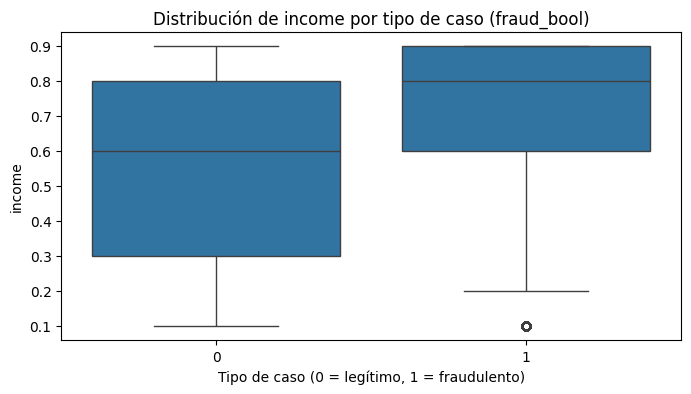

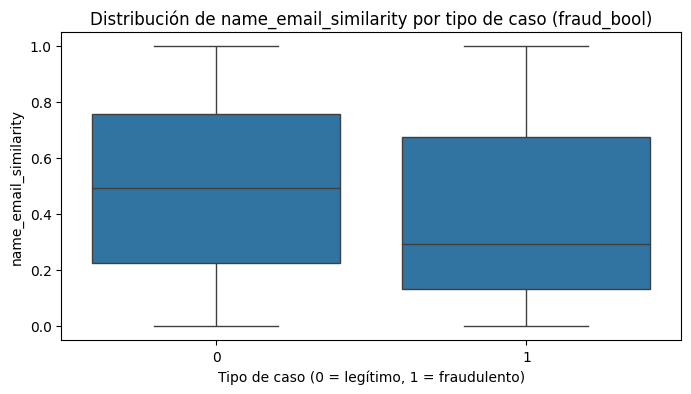

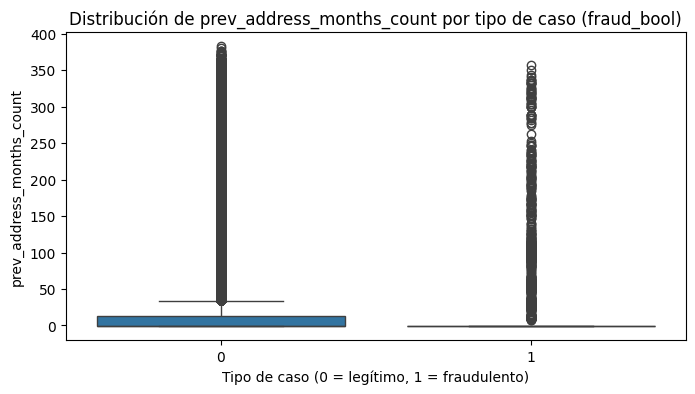

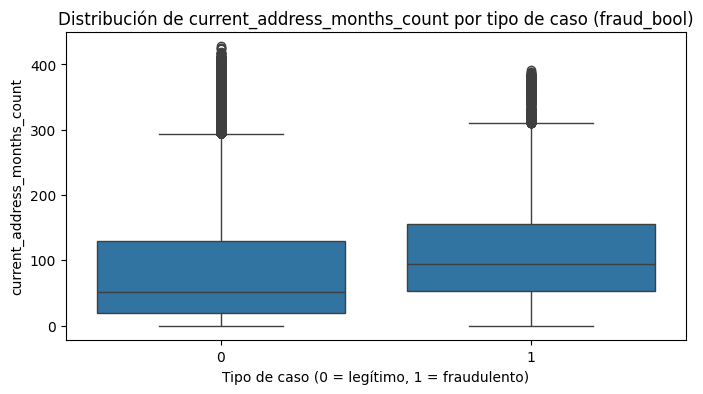

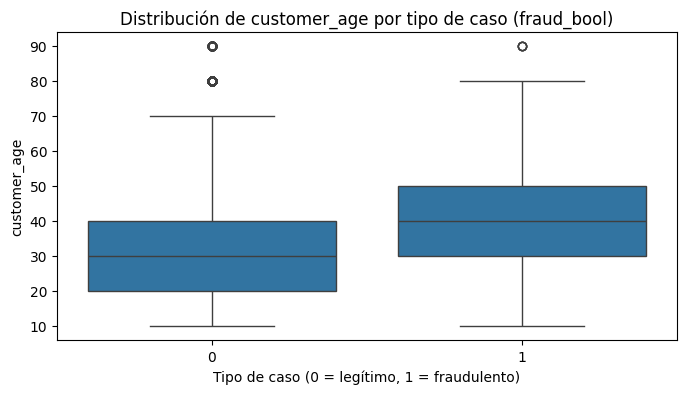

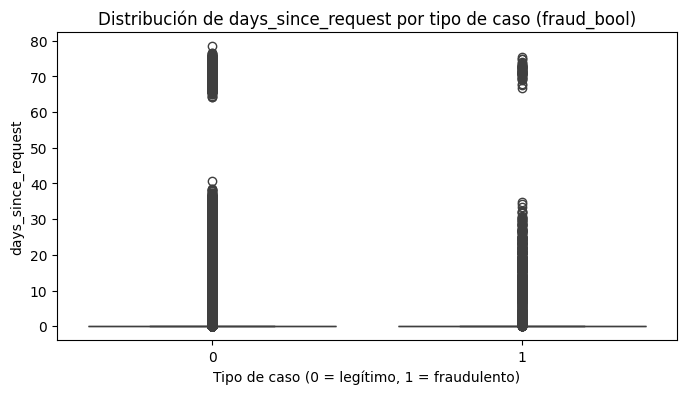

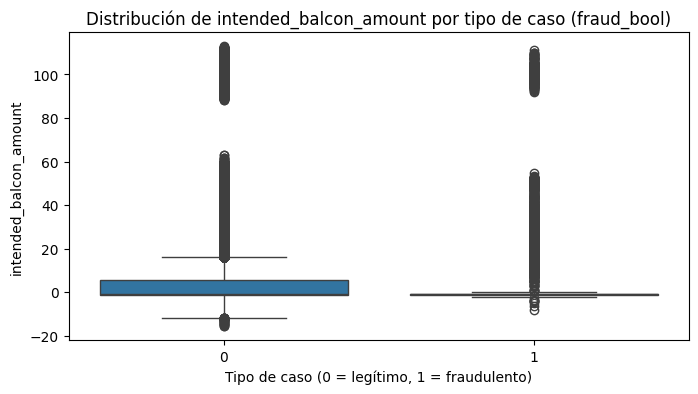

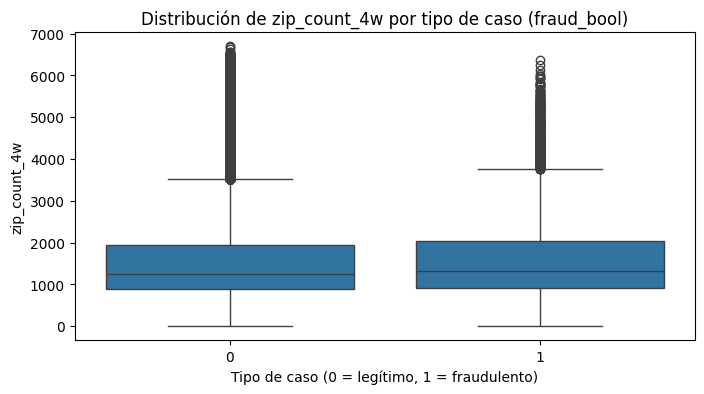

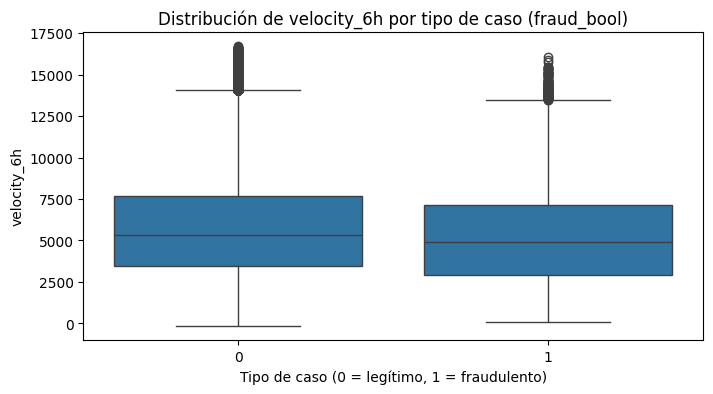

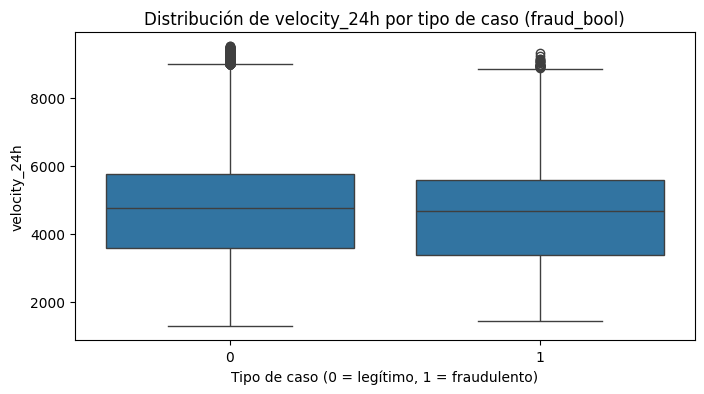

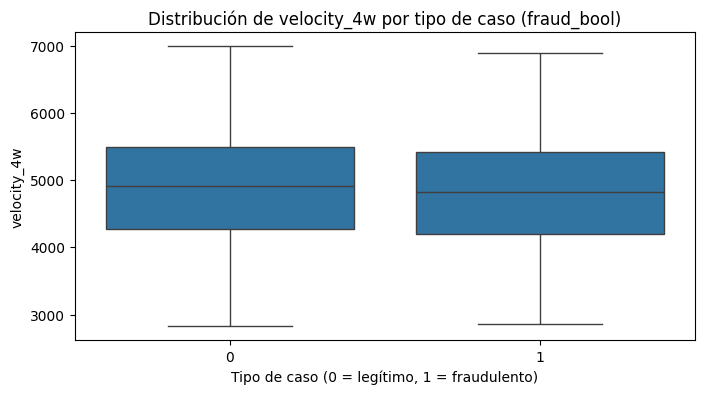

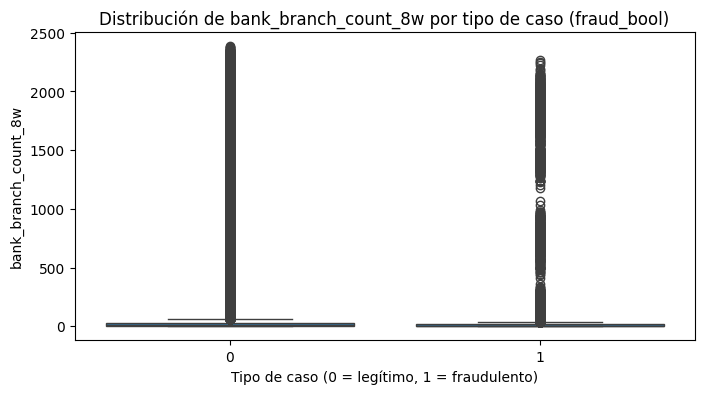

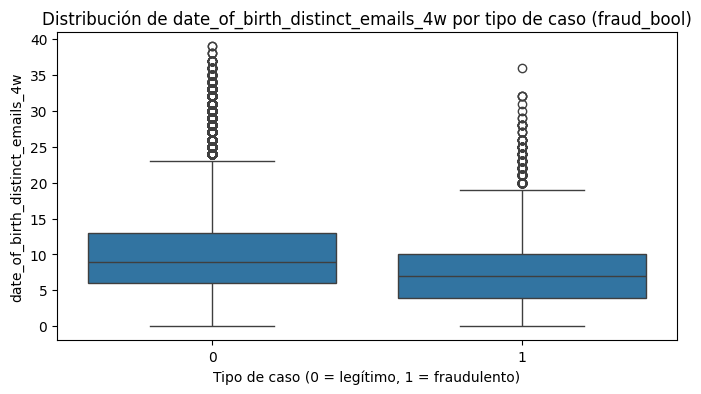

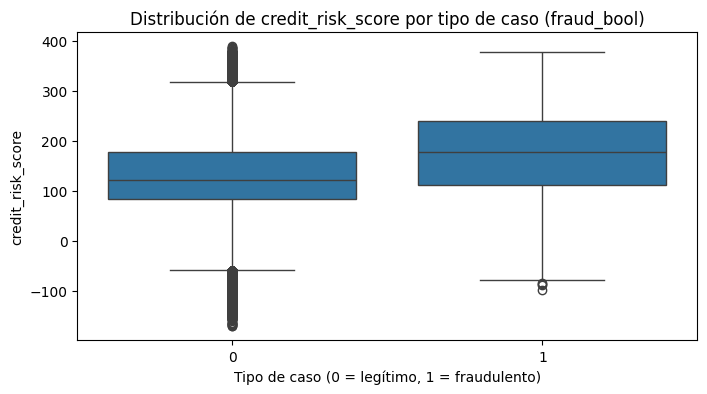

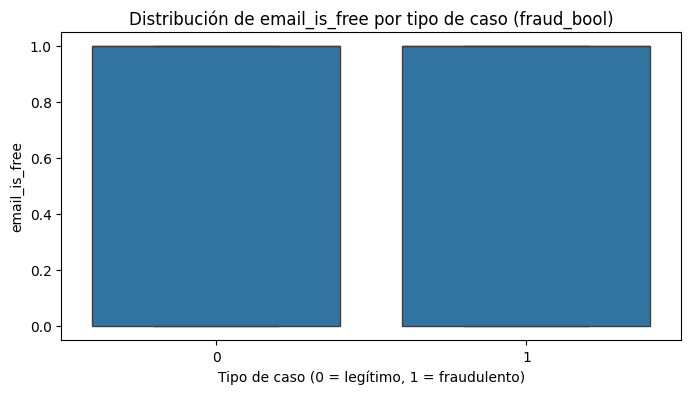

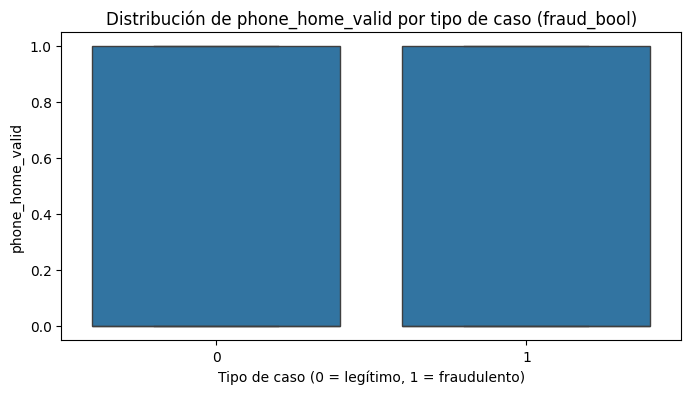

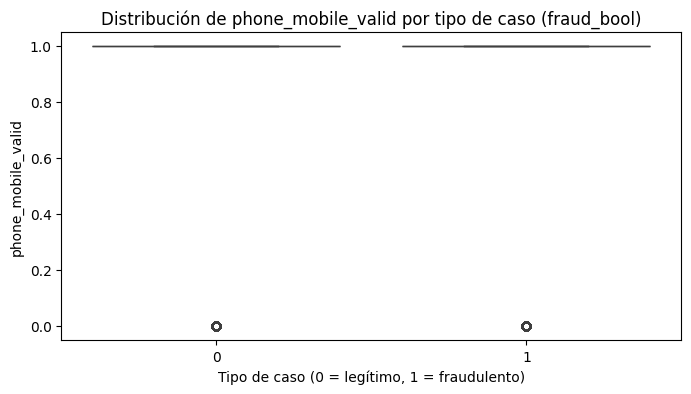

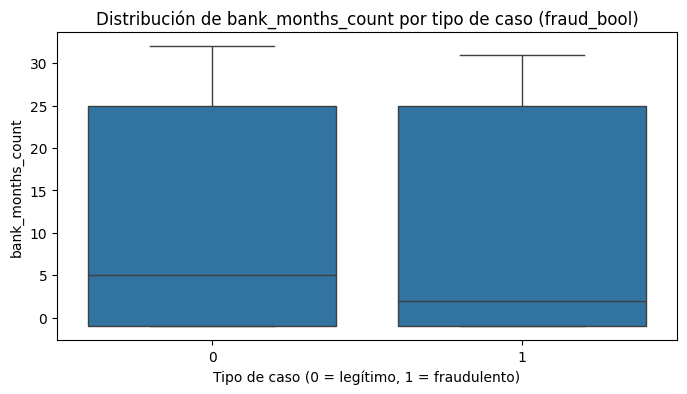

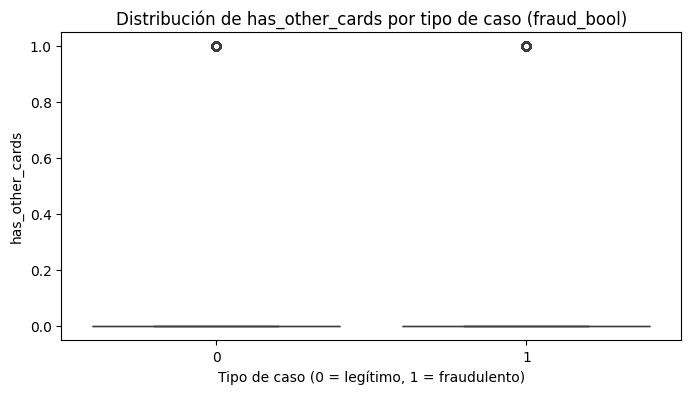

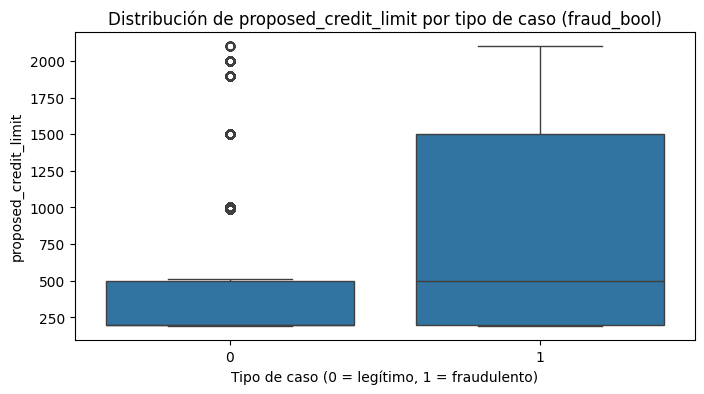

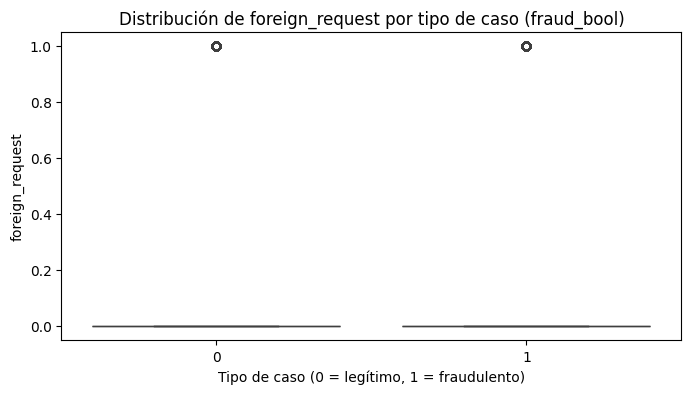

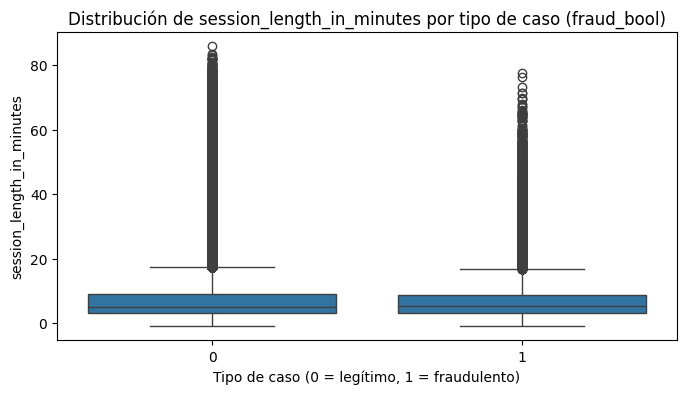

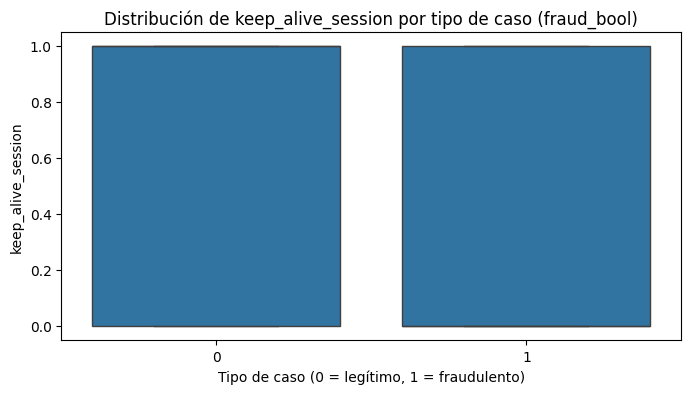

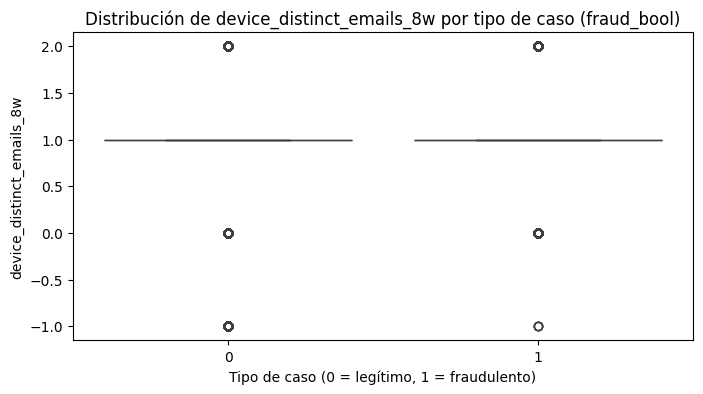

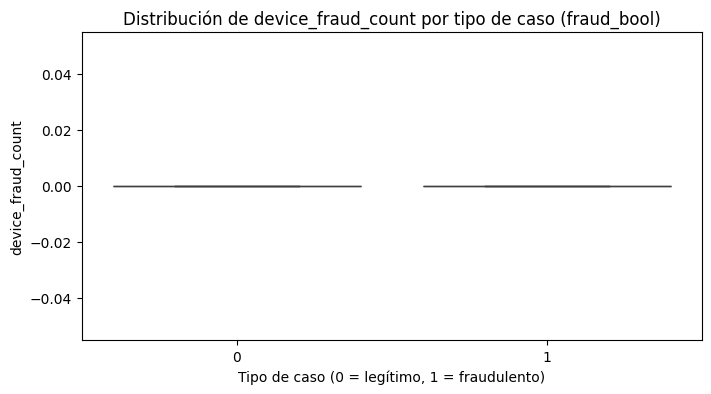

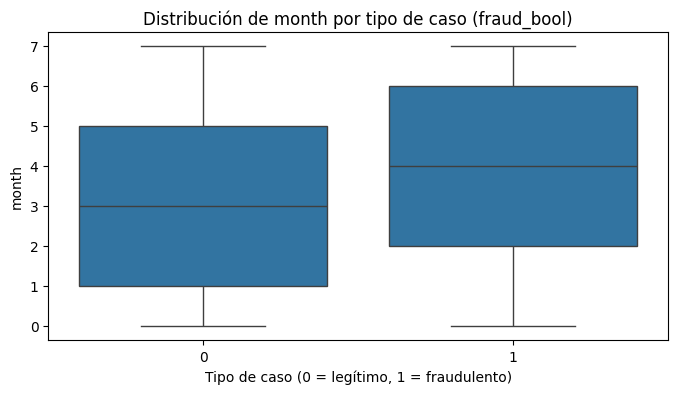

Variables numéricas que discriminan entre casos fraudulentos y legítimos: ['income', 'current_address_months_count', 'customer_age', 'credit_risk_score', 'email_is_free', 'proposed_credit_limit', 'foreign_request']


In [42]:
# Comparamos la distribución de las variables numéricas entre casos fraudulentos y legítimos usando boxplots para identificar diferencias en la distribución de estas variables entre ambos grupos
import matplotlib.pyplot as plt
import seaborn as sns
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x="fraud_bool", y=col, data=df)
    plt.title(f"Distribución de {col} por tipo de caso (fraud_bool)")
    plt.xlabel("Tipo de caso (0 = legítimo, 1 = fraudulento)")
    plt.ylabel(col)
    plt.show()


#  Pasamos a una lista las variables que que mejor discriminan entre casos fraudulentos y legítimos para usarlas en el modelo de clasificación
discriminative_vars = []
for col in numeric_cols:
    fraud_values = df[df["fraud_bool"] == 1][col]
    legit_values = df[df["fraud_bool"] == 0][col]
    if fraud_values.mean() > legit_values.mean() * 1.2:  # Arbitrario, se puede ajustar
        discriminative_vars.append(col)

print("Variables numéricas que discriminan entre casos fraudulentos y legítimos:", discriminative_vars)


# Preprocesado y Balanceo de datos

## Tratamiento de valores nulos

In [43]:
## Para los valores nulos de las variables numéricas, se pueden imputar usando la mediana o la media dependiendo de la distribución de cada variable. Para las variables categóricas, se puede usar la moda o crear una categoría adicional para los valores nulos.
def impute_missing_values(df):
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in ["float64", "int64"]:
                # Imputar con la mediana para variables numéricas
                median_value = df[col].median()
                df[col].fillna(median_value, inplace=True)
            else:
                # Imputar con la moda para variables categóricas
                mode_value = df[col].mode()[0]
                df[col].fillna(mode_value, inplace=True)
    return df

df = impute_missing_values(df)

# Confirmamos que ya no hay valores nulos
null_counts_after_imputation = df.isnull().sum()
print("Número de valores nulos después de la imputación:")
print(null_counts_after_imputation)

Número de valores nulos después de la imputación:
fraud_bool                          0
income                              0
name_email_similarity               0
prev_address_months_count           0
current_address_months_count        0
customer_age                        0
days_since_request                  0
intended_balcon_amount              0
payment_type                        0
zip_count_4w                        0
velocity_6h                         0
velocity_24h                        0
velocity_4w                         0
bank_branch_count_8w                0
date_of_birth_distinct_emails_4w    0
employment_status                   0
credit_risk_score                   0
email_is_free                       0
housing_status                      0
phone_home_valid                    0
phone_mobile_valid                  0
bank_months_count                   0
has_other_cards                     0
proposed_credit_limit               0
foreign_request                     0


## Tratamiento de valores atípicos

- El atípico se concentra en solicitudes fraudulentas | es información útil para el modelo
- El atípico aparece por igual en fraude y legítimo | **winsorización**: reemplaza los extremos por el percentil 1 y 99
- El atípico es claramente un error (ej. edad = 999) | aplica la regla de imputación


In [44]:
# Cruzamos cada variable que fue detectada con outliers con la variable objetivo fraud_bool para ver si los casos fraudulentos tienen más valores atípicos que los casos legítimos, lo que podría indicar que estas variables son importantes para la detección de fraude.
print(df['fraud_bool'].mean() * 100)

# Variables a usar winsorización
variables_winsor = []

for column in var_outliers:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    # Porcentaje de atípicos en casos fraudulentos
    porcentaje_fraud_outliers = outliers['fraud_bool'].mean() * 100
    print(f"{column}: Porcentaje de casos fraudulentos entre los atípicos: {porcentaje_fraud_outliers:.2f}%")


    # Si el porcentaje de casos fraudulentos es menor al promedio general, consideramos winsorizar esta variable
    if porcentaje_fraud_outliers < (df['fraud_bool'].mean() * 100) * 1.1 :
        variables_winsor.append(column)


1.1029
prev_address_months_count: Porcentaje de casos fraudulentos entre los atípicos: 0.37%
current_address_months_count: Porcentaje de casos fraudulentos entre los atípicos: 1.36%
customer_age: Porcentaje de casos fraudulentos entre los atípicos: 4.95%
days_since_request: Porcentaje de casos fraudulentos entre los atípicos: 1.30%
intended_balcon_amount: Porcentaje de casos fraudulentos entre los atípicos: 0.51%
zip_count_4w: Porcentaje de casos fraudulentos entre los atípicos: 1.16%
velocity_6h: Porcentaje de casos fraudulentos entre los atípicos: 0.69%
velocity_24h: Porcentaje de casos fraudulentos entre los atípicos: 0.34%
bank_branch_count_8w: Porcentaje de casos fraudulentos entre los atípicos: 0.74%
date_of_birth_distinct_emails_4w: Porcentaje de casos fraudulentos entre los atípicos: 0.61%
credit_risk_score: Porcentaje de casos fraudulentos entre los atípicos: 4.06%
phone_mobile_valid: Porcentaje de casos fraudulentos entre los atípicos: 1.49%
has_other_cards: Porcentaje de cas

In [45]:
# Aplicamos winsorización a las variables identificadas para limitar el impacto de los valores atípicos en el modelo de clasificación
variables_winsor

for col in variables_winsor:
    per01 = df[col].quantile(0.01)
    per99 = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=per01, upper=per99)

## División del dataset: entrenamiento, validación y prueba

In [46]:
# Dividimos el dataset en entrenamiento, validación y prueba para evaluar el rendimiento del modelo de clasificación de manera adecuada y evitar el sobreajuste. Se puede usar una proporción común como 70% entrenamiento, 15% validación y 15% prueba.
from sklearn.model_selection import train_test_split

X = df.drop("fraud_bool", axis=1)
y = df["fraud_bool"]

# Train, validation y test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de validación:", X_val.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)

Tamaño del conjunto de entrenamiento: (700000, 31)
Tamaño del conjunto de validación: (150000, 31)
Tamaño del conjunto de prueba: (150000, 31)


El problema es que con pocos datos de fraude, el conjunto de validación y prueba no es tan estable. Para ello se aplica K-Fold estratificado

In [47]:
# Split del 70/30 con validación cruzada estratificada para asegurar que la proporción de casos fraudulentos y legítimos se mantenga en cada conjunto, lo que es crucial dada la naturaleza desbalanceada del dataset.
from sklearn.model_selection import train_test_split, StratifiedKFold

X = df.drop("fraud_bool", axis=1)
y = df["fraud_bool"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

La *Validación cruzada estratificada* divide el entrenamiento en K=5, 5 partes iguales. Para cada ronda, 4 partes se usa para el entrenamiento y 1 para validación y se repite por 5 veces dónde se rota la validación.
Así, se tiene 5 métricas y promediadas.


In [48]:
skf = StratifiedKFold(
    n_splits=5, # Número de folds para la validación cruzada, comúnmente se usan 5 o 10 folds para obtener una buena estimación del rendimiento del modelo sin aumentar demasiado el tiempo de entrenamiento.
    shuffle=True, # Mezclamos los datos antes de cada división para asegurar que cada fold tenga una buena representación de ambos tipos de casos (fraudulentos y legítimos), lo que es especialmente importante en datasets desbalanceados como este.
    random_state=42) # Semilla para reproducibilidad

# Este skf se usará posteriormente para entrenar modelos de clasificación con validación cruzada estratificada, lo que permitirá evaluar el rendimiento del modelo de manera más robusta y evitar el sobreajuste.

## Codificacicón de variables

Identificación de columnas categorícas y numéricas

In [49]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd
import numpy as np

categorical_columns = df.select_dtypes(include=["object", "category"]).columns.tolist()
print("Variables categóricas:", categorical_columns)
numerical_columns = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
print("Variables numéricas:", numerical_columns)


Variables categóricas: ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']
Variables numéricas: ['fraud_bool', 'income', 'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'customer_age', 'days_since_request', 'intended_balcon_amount', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'credit_risk_score', 'email_is_free', 'phone_home_valid', 'phone_mobile_valid', 'bank_months_count', 'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'session_length_in_minutes', 'keep_alive_session', 'device_distinct_emails_8w', 'device_fraud_count', 'month']


Codificación de las variables categorícas - Label Encoding

In [50]:
# Hacemos copias de los conjuntos de entrenamiento, validación y prueba para aplicar transformaciones sin afectar los datos originales
X_train_enc = X_train.copy()
X_test_enc = X_test.copy()

# Guardamos los encoders dentro de un diccionario
encoders = {}

for column in categorical_columns:
    le = LabelEncoder()

    # El encoder aprende los valores posibles en el conjunto de entrenamiento
    X_train_enc[column] = le.fit_transform(X_train_enc[column].astype(str))

    # En caso de que aparezcan categorías nuevas o no vistas en el train, las transformamos a -1
    X_test_enc[column] = X_test[column].astype(str).apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1) # Si la categoría no fue vista en el entrenamiento, la codificamos como -1

    encoders[column] = le # Salvamos el encoder para usarlo posteriormente en el conjunto de prueba o en nuevos datos

    print(f"Variable '{column}' codificada. Clases: {le.classes_}")


Variable 'payment_type' codificada. Clases: ['AA' 'AB' 'AC' 'AD' 'AE']
Variable 'employment_status' codificada. Clases: ['CA' 'CB' 'CC' 'CD' 'CE' 'CF' 'CG']
Variable 'housing_status' codificada. Clases: ['BA' 'BB' 'BC' 'BD' 'BE' 'BF' 'BG']
Variable 'source' codificada. Clases: ['INTERNET' 'TELEAPP']
Variable 'device_os' codificada. Clases: ['linux' 'macintosh' 'other' 'windows' 'x11']


Estandarización de variables numéricas o StandardScaler

In [51]:
scaler = StandardScaler()

# Quitamos el fraud_bool del listado de variables numéricas para no escalar la variable objetivo
numerical_columns.remove("fraud_bool")

# Scaler aprende la media y desviación estándar del conjunto de entrenamiento para cada variable numérica solo del conjunto de entrenamiento
X_train_enc[numerical_columns] = scaler.fit_transform(X_train_enc[numerical_columns])

# Se aplica la transformación con los valores aprendidos en el conunto de entrenamiento al conjunto de prueba
X_test_enc[numerical_columns] = scaler.transform(X_test_enc[numerical_columns])

print("Preprocesamiento completado. Conjuntos de entrenamiento y prueba listos para modelado.")

Preprocesamiento completado. Conjuntos de entrenamiento y prueba listos para modelado.


## Balanceado de la base de datos

Se hace esto porque mi dataset tiene aproximadamente el 1.1% de casos fraudulento y 98.1% de casos legítimos. se busca balancear el dataset de entrenamiento para que el modelo vea que existen suficientes ejemplos de fraude y aprnda de esos patrones. Se usa la estrategía híbrida que se tiene en cuenta lo siguiente:

- SMOTENC: se crea ejemplos sintéticos de fraude para la clase minoritaria
- TomerLinks: elimina los ejemplos más cercanos de la clase fraudulenta

El objetivo es tener una proporción equilibrada

Se aplica el balanceo Híbrido al conjunto de entrenamiento

In [52]:
# Aplicación de SMOTENC para datos mixtos y categóricos para sobremuestrar la clase minoritaria (casos fraudulentos) en el conjunto de entrenamiento, lo que ayudará a mejorar el rendimiento del modelo de clasificación al equilibrar las clases.
from imblearn.over_sampling import SMOTENC
from imblearn.under_sampling import NearMiss

# Identificamos las columnas categóricas por su índice para usar en SMOTENC
categorical_indices = [X_train_enc.columns.get_loc(col) for col in categorical_columns]
print("Índices de variables categóricas para SMOTENC:", categorical_indices)

# Posiciones de columnas categóricas
print("Posiciones de columnas categóricas para SMOTENC")
for col, idx in zip(categorical_columns, categorical_indices):
    print(f"{col}: {idx}")

# Verificación de la distribución de clases antes de aplicar SMOTENC
print("Distribución de clases antes de SMOTENC:")
print(y_train.value_counts())
print(f" Legítimos: {y_train.value_counts()[0]} casos ({(y_train.value_counts()[0] / len(y_train)) * 100:.2f}%)")
print(f" Fraudulentos: {y_train.value_counts()[1]} casos ({(y_train.value_counts()[1] / len(y_train)) * 100:.2f}%)")


Índices de variables categóricas para SMOTENC: [7, 14, 17, 24, 26]
Posiciones de columnas categóricas para SMOTENC
payment_type: 7
employment_status: 14
housing_status: 17
source: 24
device_os: 26
Distribución de clases antes de SMOTENC:
fraud_bool
0    692280
1      7720
Name: count, dtype: int64
 Legítimos: 692280 casos (98.90%)
 Fraudulentos: 7720 casos (1.10%)


Usamos  NearMiss para submuestrar la clase mayoritaria. Algo muy interesante de Near Miss es que utiliza la menor distancia promedio de los K-vecinos más cercanos, es decir, selecciona los valores en base al método KNN (K-nearest neighbors) para reducir la pérdida de información. Conceptualmente, el Near Miss funciona según el principio de que los datos deben mantenerse en lugares donde las clases mayoritaria y minoritaria estén muy cerca, ya que estos lugares nos brindan información clave para distinguir las dos clases.3 Estos puntos se conocen generalmente como puntos de datos "difíciles" de aprender. El Near Miss generalmente se realiza en dos pasos

Version = 2 es la variante que mejor funciona para datasets desbalanceados.  esta versión de submuestreo Near Miss mantiene las instancias de clase mayoritaria con la distancia promedio más pequeña a sus N instancias de clase minoritaria más lejanas. A diferencia de la primera, esta versión crea una distribución más uniforme de la clase mayoritaria, lo que permite obtener mejores resultados del clasificador

Sampling_strategy = 0.1 es un punto de equilibrio pragmático: reduce el desbalanceo lo suficiente para que el modelo aprenda la clase minoritaria, sin destruir la estructura de la clase mayoritaria ni distorsionar la frontera de decisión con un undersampling excesivo. https://www.scirp.org/reference/referencespapers?referenceid=1288833

In [53]:

nearmiss = NearMiss(
    version=2,
    sampling_strategy=0.1,  # legítimos ≈ 20x fraudes → mantiene más datos
    n_neighbors=3,
    n_jobs=-1               # usa todos los núcleos disponibles
)
X_train_near, y_train_near = nearmiss.fit_resample(X_train_enc, y_train)

# Verificación
print("Distribución de clases después de NearMiss:")
print(y_train_near.value_counts())
print(f" Legítimos: {y_train_near.value_counts()[0]} casos ({(y_train_near.value_counts()[0] / len(y_train_near)) * 100:.2f}%)")
print(f" Fraudulentos: {y_train_near.value_counts()[1]} casos ({(y_train_near.value_counts()[1] / len(y_train_near)) * 100:.2f}%)")

Distribución de clases después de NearMiss:
fraud_bool
0    77200
1     7720
Name: count, dtype: int64
 Legítimos: 77200 casos (90.91%)
 Fraudulentos: 7720 casos (9.09%)


Se usa SMOTENC y no SMOTENC normal porque tenemos variables categóricas y numéricas.

El sampling_strategy es de 0.8 y significa que crea fraudes sintéticos hasta que sean el 30% de los legítimos. Fernández et al. (2018) en el libro "Learning from Imbalanced Data Sets" (Springer) recomiendan explícitamente el enfoque híbrido undersampling + oversampling con ratios intermedios (0.5–0.8) para evitar tanto la pérdida de información como el overfitting sintético. Este es exactamente tu pipeline. https://www.researchgate.net/publication/328442338_Learning_from_Imbalanced_Data_Sets

In [54]:
smotenc = SMOTENC(
    categorical_features=categorical_indices, # Índices de las columnas categóricas
    sampling_strategy= 0.8, # Sobremuestrear la clase minoritaria hasta igualar la clase mayoritaria
    random_state=42 # Semilla para reproducibilidad
)

X_train_bal, y_train_bal = smotenc.fit_resample(X_train_near, y_train_near)

# Verificación de la distribución de clases después de aplicar SMOTENC
print("Distribución de clases después de SMOTENC:")
print(y_train_bal.value_counts())
print(f" Legítimos: {y_train_bal.value_counts()[0]} casos ({(y_train_bal.value_counts()[0] / len(y_train_bal)) * 100:.2f}%)")
print(f" Fraudulentos: {y_train_bal.value_counts()[1]} casos ({(y_train_bal.value_counts()[1] / len(y_train_bal)) * 100:.2f}%)")

Distribución de clases después de SMOTENC:
fraud_bool
0    77200
1    61760
Name: count, dtype: int64
 Legítimos: 77200 casos (55.56%)
 Fraudulentos: 61760 casos (44.44%)


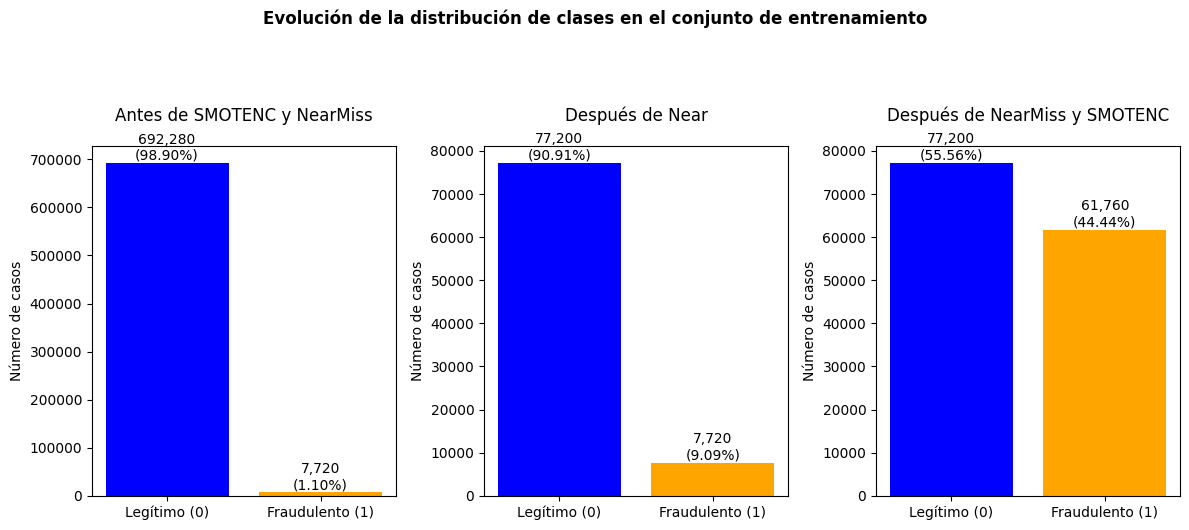

In [55]:
# Verificación final de la distribución de clases en el conjunto de entrenamiento balanceado
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

datasets = [
    (y_train, "Antes de SMOTENC y NearMiss"),
    (y_train_near, "Después de Near"),
    (y_train_bal, "Después de NearMiss y SMOTENC")
]

for ax, (y_data, title) in zip(axes, datasets):
    counts = y_data.value_counts()
    ax.bar(['Legítimo (0)', 'Fraudulento (1)'], counts, color=['blue', 'orange'])
    ax.set_title(title, y=1.05)
    ax.set_ylabel("Número de casos")

    for i, v in enumerate(counts):
        ax.text(i, v + 100, f"{v:,}\n({(v / len(y_data)) * 100:.2f}%)", ha='center', va='bottom')

fig.suptitle("Evolución de la distribución de clases en el conjunto de entrenamiento\n", y=1.05, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Modelos clásicos de Machine Learning

Se entrenan los modelos en esta fase. Son 5 modelos clásicos en orden de menor a mayor complejidad dónde cada modelo se entrena con X_train_bal y se evalúa en el X_test_enc.

Los modelos a aplicar son:

1. Regresión logística: baseline mínimo y más simple
2. Árbol de decisión: baseline interpretable
3. Random Forest: modelo de ensamble robusto
4. XGboost: es un modelo de referencia principal dentro de nuestro TFM
5. LightGBM: es una variante eficiente de XGBoost

Las métricas a usar no contemplan accuracy porque con un 1.1% de fraaude, un modelo que dice siempre legítimo, tiene 98.9% de accuracy. Es así que usaremos:

- Precisión de los que el modelo dijo fraude, cuantos eran realmente.
- Recall donde todos los fraudes reales, cuantos detectó el modelo.
- F1 - score: es el equilibrio entre precisión y recall
- ROC-AUC: que tan bien separa el modelo fraude de legítimo en general
- PR - AUC: igual pero más informativo cuando las clases están desbalanceadas

In [56]:
# Librerias a usar
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, f1_score, precision_score, recall_score, RocCurveDisplay, PrecisionRecallDisplay, precision_recall_curve
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time

Definimos los modelos a evaluar con parámetros por defecto sin optimización para obtener una línea base de referencia. Después aplicamos el tuning.

In [57]:
modelos = {
    'Regresión Logística': LogisticRegression(
        random_state=42, # iteramos máximas permutaciones posibles para asegurar la convergencia del modelo, especialmente importante en datasets con muchas variables o con alta dimensionalidad, lo que puede dificultar la convergencia del algoritmo de optimización.
        max_iter=1000,
        n_jobs=-1 # usamos todos los núcleos del procesador para acelerar el entrenamiento
    ),
    'Arbol de Decisión': DecisionTreeClassifier(
        random_state = 42
    ),
    'Random Forest': RandomForestClassifier(
        random_state=42,
        n_jobs=-1, # usamos todos los núcleos del procesador para acelerar el entrenamiento
        n_estimators=100 # número de árboles en el bosque, un valor común que suele ofrecer un buen equilibrio entre rendimiento y tiempo de entrenamiento
    ),
    'XGBoost': XGBClassifier(
        random_state=42,
        n_jobs=-1, # usamos todos los núcleos del procesador para acelerar el entrenamiento
        n_estimators=100, # número de árboles a construir, un valor común que suele ofrecer un buen equilibrio entre rendimiento y tiempo de entrenamiento
        eval_metric='logloss', # métrica de evaluación para problemas de clasificación binaria, logloss es una métrica comúnmente utilizada que mide la probabilidad asignada a la clase correcta, lo que es especialmente útil en problemas de clasificación con clases desbalanceadas como este
        verbosity=0, # desactiva la salida de información durante el entrenamiento para mantener la consola limpia, especialmente útil cuando se entrenan modelos con muchos árboles o con conjuntos de datos grandes, lo que puede generar mucha salida de información en la consola
        scale_pos_weight=10, #
    ),
    'LightGBM': LGBMClassifier(
        random_state=42,
        n_jobs=-1,
        n_estimators=100,
        verbose=-1,
        class_weight='balanced',  # equivalente a is_unbalance pero más eficiente
        num_leaves=31,             # limita la complejidad del árbol
        min_child_samples=50
    )
}

# Validación cruzada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Entrenando el modelo

Para cada modelo se aplcia la validación cruzada en X_train_bal- Se entrena el modelo con el X_train_bal y la evaluación se hace en X_test_enc

In [58]:
resultados = []
modelos_entrenados = {}

print("=" * 50)
print("Resultados de los modelos entrenados:")
print("=" * 50)

for nombre, modelo in modelos.items():
    print(f"\nEntrenando modelo: {nombre}")
    inicio = time.time()

    # ===== VALIDACIÓN CRUZADA =====
    cv_scores = cross_val_score(
        modelo, X_train_bal, y_train_bal,
        cv=skf,
        scoring='roc_auc', # métrica en cada fold
        n_jobs=-1 # usa todos los núcleos para acelerar la validación cruzada
    )

    cv_media = np.mean(cv_scores)
    cv_std = np.std(cv_scores)
    print(f"Validación cruzada (ROC AUC): {cv_media:.4f} ± {cv_std:.4f}")

    # ===== ENTRENAMIENTO FINAL =====
    modelo.fit(X_train_bal, y_train_bal)
    modelos_entrenados[nombre] = modelo


    ## Predict para etiquetas (0) legítimos y (1) fraudulentos
    y_pred = modelo.predict(X_test_enc)

    ## predict_proba para obtener las probabilidades de cada clase, lo que es necesario para calcular métricas como ROC AUC y Precision-Recall AUC, especialmente en problemas de clasificación con clases desbalanceadas como este
    y_pred_prob = modelo.predict_proba(X_test_enc)[:, 1] # Probabilidad de la clase positiva (fraudulenta)

    ## Calculamos métricas de evaluación
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    pr_auc = average_precision_score(y_test, y_pred_prob)
    tiempo= time.time() - inicio

    print(f"Evaluación en conjunto de prueba:")
    print(f" Precision: {precision:.4f} | Recall: {recall:.4f} | F1-Score: {f1:.4f} | ROC AUC: {roc_auc:.4f} | PR AUC: {pr_auc:.4f} | Tiempo total: {tiempo:.1f} segundos")
    print("\n")
    resultados.append({
        'Modelo': nombre,
        'CV ROC AUC': f"{cv_media:.4f} ± {cv_std:.4f}",
        'Precision': f"{precision:.4f}",
        'Recall': f"{recall:.4f}",
        'F1-Score': f"{f1:.4f}",
        'ROC-AUC': f"{roc_auc:.4f}",
        'PR-AUC': f"{pr_auc:.4f}",
        'Tiempo (s)': f"{tiempo:.1f}"
    })


Resultados de los modelos entrenados:

Entrenando modelo: Regresión Logística
Validación cruzada (ROC AUC): 0.9592 ± 0.0011
Evaluación en conjunto de prueba:
 Precision: 0.0249 | Recall: 0.8154 | F1-Score: 0.0484 | ROC AUC: 0.8123 | PR AUC: 0.0647 | Tiempo total: 2.0 segundos



Entrenando modelo: Arbol de Decisión
Validación cruzada (ROC AUC): 0.9588 ± 0.0012
Evaluación en conjunto de prueba:
 Precision: 0.0158 | Recall: 0.8480 | F1-Score: 0.0311 | ROC AUC: 0.6300 | PR AUC: 0.0151 | Tiempo total: 6.5 segundos



Entrenando modelo: Random Forest
Validación cruzada (ROC AUC): 0.9983 ± 0.0002
Evaluación en conjunto de prueba:
 Precision: 0.0178 | Recall: 0.8486 | F1-Score: 0.0348 | ROC AUC: 0.7760 | PR AUC: 0.0478 | Tiempo total: 6.0 segundos



Entrenando modelo: XGBoost
Validación cruzada (ROC AUC): 0.9984 ± 0.0002
Evaluación en conjunto de prueba:
 Precision: 0.0143 | Recall: 0.9284 | F1-Score: 0.0282 | ROC AUC: 0.7267 | PR AUC: 0.0322 | Tiempo total: 2.8 segundos



Entrenando modelo

# Generamos la matriz de confusión para cada modelo

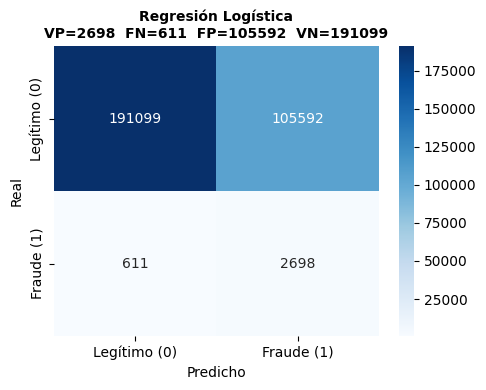

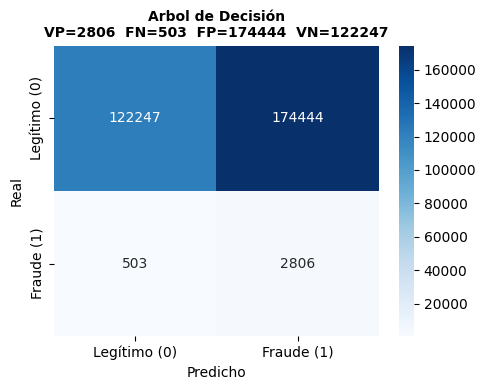

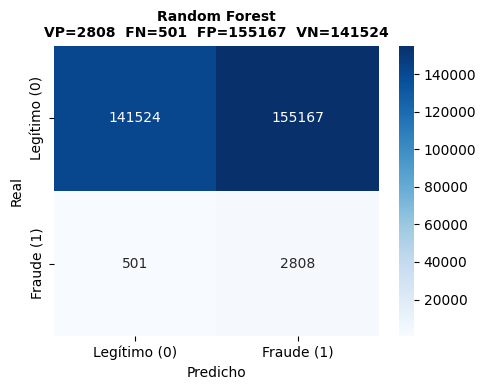

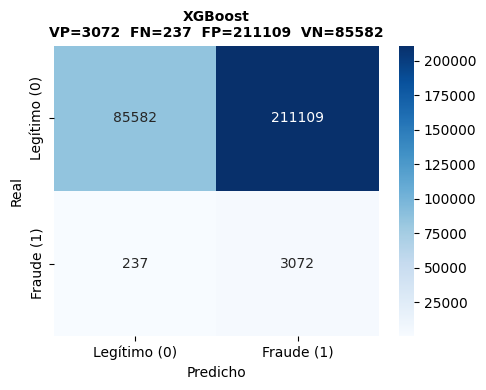

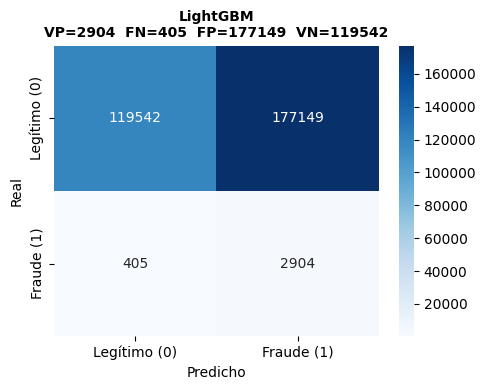

In [59]:
for nombre, modelo in modelos_entrenados.items():

    # Predicciones sobre el conjunto de prueba
    y_pred = modelo.predict(X_test_enc)

    # Calcular la matriz de confusión
    cm = confusion_matrix(y_test, y_pred)

    # Extraer los 4 valores para mostrarlos en el título
    tn, fp, fn, tp = cm.ravel()

    # Graficar
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',                              # formato entero
        cmap='Blues',
        xticklabels=['Legítimo (0)', 'Fraude (1)'],
        yticklabels=['Legítimo (0)', 'Fraude (1)']
    )
    plt.title(
        f'{nombre}\n'
        f'VP={tp}  FN={fn}  FP={fp}  VN={tn}',
        fontsize=10, fontweight='bold'
    )
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.tight_layout()
    plt.show()

## Tunning de parámetros

Los modelos tienen configuraciones internas llamadas hiperparámetros que no se aprenden de los datos sino que los definimos nosotros antes de entrenar. Por ejemplo, cuántos árboles tiene un Random Forest, o qué tan profundo puede crecer un árbol de decisión. En la primera ronda entrenamos con valores por defecto para tener una línea base. Ahora en esta segunda ronda buscamos los valores óptimos de esos hiperparámetros para mejorar el rendimiento.

¿Qué es Grid Search?
Es una búsqueda exhaustiva: prueba TODAS las combinaciones posibles
de hiperparámetros que le indicamos y se queda con la mejor. Usa validación cruzada estratificada k=5 para evaluar cada combinación,
lo que garantiza que el resultado sea estable y no dependa del azar. Se aplica a los 5 modelos clásicos para una comparación completa y justa.

In [60]:
# Cada modelo tiene su propio grid con los hiperparámetros a explorar.
# Los grids están acotados deliberadamente para mantener tiempos razonables
# en Colab sin sacrificar la calidad de la búsqueda.

from sklearn.model_selection import GridSearchCV

grids = {

    # ── Regresión Logística ──────────────────────────────────────────────────
    # C: controla la regularización. Valores pequeños (0.01) penalizan más
    # los coeficientes grandes → modelo más simple y generalizable.
    # Valores grandes (10) permiten coeficientes grandes → modelo más flexible.
    # class_weight='balanced': ajusta automáticamente los pesos de cada clase
    # según su frecuencia, compensando el desbalanceo de 1.1% de fraude.
    'Regresión Logística': {
        'modelo': LogisticRegression(random_state=42, n_jobs=-1, max_iter=1000),
        'params': {
            'C': [0.01, 0.1, 1, 10],
            'class_weight': ['balanced', None]
        }
    },

    # ── Árbol de Decisión ────────────────────────────────────────────────────
    # max_depth: profundidad máxima del árbol. Árboles muy profundos memorizan
    # los datos (sobreajuste). None significa sin límite de profundidad.
    # min_samples_split: mínimo de muestras necesarias para dividir un nodo.
    # Valores altos hacen el árbol más conservador y generalizable.
    # class_weight='balanced': igual que en regresión logística.
    'Arbol de Decisión': {
        'modelo': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [5, 10, 20, None],
            'min_samples_split': [2, 5, 10],
            'class_weight': ['balanced', None]
        }
    },

    # ── Random Forest ────────────────────────────────────────────────────────
    # n_estimators: número de árboles en el bosque. Más árboles = más estable
    # pero más lento. 100 y 200 son valores habituales en la literatura.
    # max_depth: igual que en el árbol de decisión pero aplicado a cada árbol
    # del bosque individualmente.
    'Random Forest': {
        'modelo': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [10, 20, None],
            'class_weight': ['balanced', None]
        }
    },

    # ── XGBoost ──────────────────────────────────────────────────────────────
    # n_estimators: número de rondas de boosting (árboles secuenciales).
    # max_depth: profundidad máxima de cada árbol base.
    # scale_pos_weight: compensa el desbalanceo de clases. Se calcula como
    # ratio de legítimos / fraudes. En nuestro dataset:
    #   - 1   → sin compensación (ignora el desbalanceo)
    #   - 10  → compensación moderada
    #   - 90  → compensación fuerte (≈ ratio real del dataset original)
    'XGBoost': {
        'modelo': XGBClassifier(random_state=42, n_jobs=-1,
                                eval_metric='logloss', verbosity=0,
                                n_estimators=100),
        'params': {
            'max_depth': [3, 6],
            'scale_pos_weight': [1, 10, 90]
        }
    },

    # ── LightGBM ─────────────────────────────────────────────────────────────
    # learning_rate: qué tan grandes son los pasos de aprendizaje en cada
    # iteración. Valores pequeños (0.05) aprenden más despacio pero de forma
    # más precisa. Valores grandes (0.1) convergen más rápido pero pueden
    # perder calidad.
    # num_leaves: número máximo de hojas por árbol. Controla la complejidad
    # del modelo. Más hojas = más complejo = mayor riesgo de sobreajuste.
    'LightGBM': {
        'modelo': LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1,
                                n_estimators=100),  # ← fija en 100
        'params': {
            'learning_rate': [0.05, 0.1],
            'num_leaves': [31, 50],
            'class_weight': ['balanced']   # ← quita None
        }
    }
}
# =============================================================================
# EJECUCIÓN DEL GRID SEARCH
# =============================================================================
# Para cada modelo:
#   1. GridSearchCV prueba todas las combinaciones del grid con CV k=5
#   2. Se queda con el mejor modelo según ROC-AUC en validación cruzada
#   3. Ese mejor modelo se evalúa sobre X_test_enc (conjunto de prueba real)
#   4. Guardamos las métricas para la tabla comparativa final

resultados_tuning = []
modelos_tuneados  = {}   # guardamos los mejores modelos para usarlos en SHAP/LIME

print("=" * 60)
print("TUNING DE HIPERPARÁMETROS – GRID SEARCH")
print("=" * 60)

for nombre, config in grids.items():
    print(f"\n▶ Tuneando: {nombre}")
    inicio = time.time()

    search = GridSearchCV(
        estimator=config['modelo'],   # modelo base sin optimizar
        param_grid=config['params'],  # combinaciones a probar
        scoring='roc_auc',            # métrica de selección (no usamos accuracy)
        cv=3,                       # validación cruzada estratificada k=5
        n_jobs=-1,                    # usa todos los núcleos disponibles
        verbose=0                     # silencia mensajes internos
    )

    # Entrenamos el grid sobre el conjunto balanceado (X_train_bal)
    # NUNCA sobre X_test_enc → eso contaminaría la evaluación final
    search.fit(X_train_bal, y_train_bal)

    # Recuperamos el mejor modelo ya entrenado con los mejores parámetros
    mejor = search.best_estimator_
    modelos_tuneados[nombre] = mejor

    # Evaluamos sobre el conjunto de prueba (mundo real desbalanceado)
    y_pred = mejor.predict(X_test_enc)
    y_prob = mejor.predict_proba(X_test_enc)[:, 1]

    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    roc  = roc_auc_score(y_test, y_prob)
    pr   = average_precision_score(y_test, y_prob)

    print(f"  Mejores parámetros: {search.best_params_}")
    print(f"  CV ROC-AUC:  {search.best_score_:.4f}")
    print(f"  Precision:   {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    print(f"  ROC-AUC:     {roc:.4f} | PR-AUC: {pr:.4f}")
    print(f"  Tiempo:      {time.time()-inicio:.1f}s")

    resultados_tuning.append({
        'Modelo':    nombre,
        'Precision': round(prec, 4),
        'Recall':    round(rec, 4),
        'F1-Score':  round(f1, 4),
        'ROC-AUC':   round(roc, 4),
        'PR-AUC':    round(pr, 4),
    })



TUNING DE HIPERPARÁMETROS – GRID SEARCH

▶ Tuneando: Regresión Logística
  Mejores parámetros: {'C': 0.01, 'class_weight': None}
  CV ROC-AUC:  0.9487
  Precision:   0.0249 | Recall: 0.8147 | F1: 0.0483
  ROC-AUC:     0.8127 | PR-AUC: 0.0651
  Tiempo:      2.1s

▶ Tuneando: Arbol de Decisión
  Mejores parámetros: {'class_weight': None, 'max_depth': 5, 'min_samples_split': 2}
  CV ROC-AUC:  0.9583
  Precision:   0.0207 | Recall: 0.8341 | F1: 0.0404
  ROC-AUC:     0.7512 | PR-AUC: 0.0292
  Tiempo:      6.2s

▶ Tuneando: Random Forest
  Mejores parámetros: {'class_weight': None, 'max_depth': None, 'n_estimators': 200}
  CV ROC-AUC:  0.9946
  Precision:   0.0177 | Recall: 0.8516 | F1: 0.0347
  ROC-AUC:     0.7770 | PR-AUC: 0.0507
  Tiempo:      35.3s

▶ Tuneando: XGBoost
  Mejores parámetros: {'max_depth': 6, 'scale_pos_weight': 1}
  CV ROC-AUC:  0.9965
  Precision:   0.0151 | Recall: 0.8830 | F1: 0.0296
  ROC-AUC:     0.7222 | PR-AUC: 0.0326
  Tiempo:      3.1s

▶ Tuneando: LightGBM
  Mej

In [61]:
modelos_entrenados.update(modelos_tuneados)

## Tabla Comparativa de resultados

In [62]:
# =============================================================================
# TABLA COMPARATIVA FINAL
# =============================================================================
# Ordenamos por PR-AUC que es la métrica más informativa con datos desbalanceados

df_tuning = pd.DataFrame(resultados_tuning).sort_values('PR-AUC', ascending=False)

print("\n" + "="*60)
print("TABLA COMPARATIVA – MODELOS TUNEADOS")
print("="*60)
print(df_tuning.to_string(index=False))
print("\nTabla guardada como 'resultados_tuning.csv'")

# Los modelos_tuneados quedan listos para usarse en la siguiente fase de SHAP y LIME
print("\nModelos tuneados disponibles:", list(modelos_tuneados.keys()))


TABLA COMPARATIVA – MODELOS TUNEADOS
             Modelo  Precision  Recall  F1-Score  ROC-AUC  PR-AUC
Regresión Logística     0.0249  0.8147    0.0483   0.8127  0.0651
      Random Forest     0.0177  0.8516    0.0347   0.7770  0.0507
           LightGBM     0.0157  0.8824    0.0308   0.7441  0.0415
            XGBoost     0.0151  0.8830    0.0296   0.7222  0.0326
  Arbol de Decisión     0.0207  0.8341    0.0404   0.7512  0.0292

Tabla guardada como 'resultados_tuning.csv'

Modelos tuneados disponibles: ['Regresión Logística', 'Arbol de Decisión', 'Random Forest', 'XGBoost', 'LightGBM']


# Modelos avanzados

Se entrena dos arquitecturas de Deep Learning donde la primera es un MLP, que es una red neuronal clásica baseline de DL; y la TabTransformer que es una arquitectura moderna basada en Transformers muy adecuada para datos tabulares.

Los modelos clásicos son muy buenos pero tienen limitantes para aprender relaciones complejas entre las diferentes variables. El TabTransformer tiene representaciones más ricas de las variables categóricas por medio de mecanismos de atención.

In [63]:
import sys
!{sys.executable} -m pip install torch
!pip uninstall -y torch torchvision torchaudio
!pip install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cu128

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay
)

import time
import warnings
warnings.filterwarnings("ignore")

print("Verificando disponibilidad de GPU...")
# Verificamos si se tiene GPU disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Found existing installation: torch 2.9.0+cu126
Uninstalling torch-2.9.0+cu126:
  Successfully uninstalled torch-2.9.0+cu126
Found existing installation: torchvision 0.24.0+cu126
Uninstalling torchvision-0.24.0+cu126:
  Successfully uninstalled torchvision-0.24.0+cu126
Found existing installation: torchaudio 2.9.0+cu126
Uninstalling torchaudio-2.9.0+cu126:
  Successfully uninstalled torchaudio-2.9.0+cu126
Looking in indexes: https://download.pytorch.org/whl/nightly/cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.9/657.9 MB 126.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 166.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.1/139.1 MB 247.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 35.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 532.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 120.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Preparación de los datos para PyTorch
Pytorch no usa Dataframes de pandas sino TEnsores y cada tensor es una matriz optimizada de cálculos como un array en numpy pero adecuado para redes neuronales.

In [64]:
# Pasamos los datos a arrays de Numpy para convertirlos luego a tensores de PyTorch
X_train_np = X_train_bal.values.astype(np.float32) # float32 es el tipo que PyTorch espera para los tensores de entrada
y_train_np = y_train_bal.values.astype(np.float32) # Para clasificación binaria
X_test_np = X_test_enc.values.astype(np.float32)
y_test_np = y_test.values.astype(np.float32)

# Convertimos a Tensores de PyTorch
X_train_tensor = torch.FloatTensor(X_train_np).to(device)
y_train_tensor = torch.FloatTensor(y_train_np).to(device)
X_test_tensor = torch.FloatTensor(X_test_np).to(device)
y_test_tensor = torch.FloatTensor(y_test_np).to(device)

Se crea el TensorDataset para agrupar X y Y juntos con un dataloader que separa en lotes o batches para entrenar.

In [65]:
batch_size = 512

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

n_features = X_train_tensor.shape[1]
print(f"Número de características de entrada: {n_features}")

Número de características de entrada: 31


## Modelo 1 - MLP (Red Neuronal Multicapa)
Es la red neuronal más básica.
- Capa de entrada recibe las variables del dataset
- Capas ocultas que procesan la información con tres capas
- Capa de salida que produce una probabilidad de fraude (0 a 1)

Cada capa tiene una transformación matemática con una función de activación ReLU para que el modelo aprenda relaciones no lineales.

El batchNorm tiene los valores entre las capas para poder estabilizar el entrenamiento.
El Dropout apaga neuronas de manera aleatoria durante el entrenamiento para que el modelo no memorice los datos y evitar sobreajuste


In [66]:
# Definimos la clase MLP
class MLP(nn.Module):
    def __init__(self, n_features):
        super(MLP, self).__init__()

        self.red = nn.Sequential(

            # Capa 1: n_features con entradas -> 256 neuronas
            nn.Linear(n_features, 256),
            nn.BatchNorm1d(256), # normalización
            nn.ReLU(), # función de activación
            nn.Dropout(0.3), # apaga 30% de neuronas aleatoriamente

            # Capa 2: 256 > 128 neuronas
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Capa 3: 128 -> 65 neuronas
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            # Capa de salida: 64  -> 1 neurona (probabilidad de fraude)
            nn.Linear(64, 1),
            nn.Sigmoid() # Convierte el número a una probabilidad entre 0 y 1
        )


    def forward(self, x):
        # forward define como fluyen los datos por la red
        return self.red(x).squeeze(1) # squeeze que elimina una dimensión extra

## Modelo 2: TabTrasformer

El TabTransformer es una arquitectura moderna que aplica mecanismos de atención sobre las variables categóricas.. Esta atención es una capacidad que tiene el modelo para aprender que variables son más importantes en el contexto de las demás variables. Un ejemplo sería de que employment_status es más importante para predecir fraude cuando se combina con ustomer_age bajo. El transformer aprende esas relaciones entre las diferentes variables.

La estructura es:
- Embedding de categóricas que convierte cada categoría en vectores densos
- Transformer Encoder que aplica atención entre las categorías
- Concatenación que une las categorías procesadas con las numéricas
- MLP final que produce la predicción de fraude

In [67]:
# Definimos la clase TabTransformer
class TabTransformer(nn.Module):
    def __init__(self, n_cat, n_num, emb_dim=32, n_heads=4, n_layers=2, dropout=0.1):
        # n_cat es el número de variables categóricas
        # n_num es el número de variables numéricas
        # emb_dim es la dimensión de los embeddings para las variables categóricas
        # n_heads es el número de cabezas en el mecanismo de atención
        # n_layers es el número de capas del transformer

        super(TabTransformer, self).__init__()

        # Embedding que convierte cada variable categórica en un vector de dimensión emb_dim

        self.embeddings = nn.ModuleList([
            nn.Embedding(50, emb_dim) for _ in range(n_cat)
        ])

        # Transformer encoder: aplicación de atención para capturar relaciones entre variables categóricas y numéricas
        encoder_layer = nn.TransformerEncoderLayer(
            d_model = emb_dim, # dimensión de los embeddings
            nhead = n_heads, # número de cabezas de atención
            dropout = dropout, # tasa de dropout para regularización
            batch_first = True # indica que el batch es la primera dimensión
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # MLP (Multi-Layer Perceptron) para procesar la salida del transformer y las variables numéricas
        dim_entrada = n_cat * emb_dim + n_num # dimensión de entrada al MLP: concatenación de embeddings y variables numéricas
        self.mlp = nn.Sequential(
            nn.Linear(dim_entrada, 128), # Capa 1: dim_entrada -> 128 neuronas
            nn.ReLU(), # función de activación ReLU para introducir no linealidad
            nn.Dropout(0.3), # Dropout para regularización y evitar sobreajuste
            nn.Linear(128, 64), # Capa 2: 128 -> 64 neuronas
            nn.ReLU(), # función de activación ReLU para introducir no linealidad
            nn.Dropout(0.2), # Dropout para regularización y evitar sobreajuste
            nn.Linear(64, 1), # Capa de salida: 64 -> 1 neurona (probabilidad de fraude)
            nn.Sigmoid() # Convierte el número a una probabilidad entre 0 y 1
        )


    def forward(self, x_cat, x_num):
        # Procesa cada variable categórica a través de su embedding correspondiente
        embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x_cat_emb = torch.stack(embs, dim=1) # Concatenamos los embeddings de todas las variables categóricas

        # Aplicamos la atención del transformer a los embeddings de las variables categóricas
        x_cat_transformed = self.transformer(x_cat_emb) # Salida del transformer para las variables categóricas
        x_cat_flat = x_cat_transformed.flatten(1)   # Aplanamos la salida del transformer para concatenarla con las variables numéricas

        # Contatenamos con las variables numéricas
        x_combined = torch.cat([x_cat_flat, x_num], dim=1) # Concatenamos la salida del transformer con las variables numéricas

        # Returnamos la probabilidad de fraude a través del MLP

        return self.mlp(x_combined).squeeze(1) # squeeze para eliminar una dimensión extra

Aplicamos una función de entrenamiento para el modelo MLP y el TabTransformer.

In [68]:
# Separamos las variables categóricas y numéricas para alimentar el TabTransformer
cat_idx = [X_train_bal.columns.get_loc(col) for col in categorical_columns]
num_idx = [X_train_bal.columns.get_loc(col) for col in numerical_columns]

n_cat = len(cat_idx)
n_num = len(num_idx)

print(f"Variables categóricas: {categorical_columns} (n={n_cat})")
print(f"Variables numéricas: {numerical_columns} (n={n_num})")


# Función para separar un tensor en parte categórica y parte numérica según los índices definidos
def separar_cat_num(X_tensor):
    X_cat = X_tensor[:, cat_idx].long() # Convertimos a long para los embeddings
    X_num = X_tensor[:, num_idx] # Las variables numéricas ya están en float

    # Clampeamos las variables numéricas para evitar valores extremos que puedan afectar el entrenamiento del modelo
    X_cat = X_cat.clamp(min=0) # Para variables categóricas, aseguramos que no haya valores negativos

    return X_cat, X_num

Variables categóricas: ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os'] (n=5)
Variables numéricas: ['income', 'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'customer_age', 'days_since_request', 'intended_balcon_amount', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'credit_risk_score', 'email_is_free', 'phone_home_valid', 'phone_mobile_valid', 'bank_months_count', 'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'session_length_in_minutes', 'keep_alive_session', 'device_distinct_emails_8w', 'device_fraud_count', 'month'] (n=26)


In [69]:
# Parámetros de la función de entrenamiento
## modelo: la red neuronal a entrenar (MLP o TabTransformer)
## tipo: mlp o TabTransformer para saber como pasar los datos a la función de entrenamiento, ya que el MLP solo recibe un tensor de entrada, mientras que el TabTransformer recibe dos tensores (uno para variables categóricas y otro para numéricas)
## epochs: número de épocas para entrenar la red neuronal, un valor común para empezar es 20-30 épocas, pero se puede ajustar según el rendimiento del modelo en el conjunto de validación
# lr: tasa de aprendizaje para el optimizador, un valor común para empezar es 0.001, pero se puede ajustar según la convergencia del modelo durante el entrenamiento

def model_training(modelo, tipo, epochs=30, lr=0.001):
    # BCELoss es adecuada para problemas de clasificación binaria como este, ya que mide la diferencia entre las probabilidades predichas por el modelo y las etiquetas reales, penalizando más fuertemente las predicciones incorrectas en la clase minoritaria (fraudulenta), lo que es crucial en datasets desbalanceados como este.
    criterio = nn.BCELoss() # Binary Cross-Entropy Loss, adecuada para problemas de clasificación binaria como este

    # Adam es un optimizador que combina las ventajas de AdaGrad y RMSProp, lo que lo hace eficiente para entrenar redes neuronales profundas, especialmente en problemas con muchas características como este, ya que ajusta la tasa de aprendizaje de manera adaptativa para cada parámetro, lo que puede ayudar a mejorar la convergencia del modelo.
    optimizador = optim.Adam(modelo.parameters(), lr=lr, weight_decay=1e-4) # Adam es un optimizador adecuado para el entrenamiento de redes neuronales

    # ReduceLROnPlateau: ayuda a reducir la tasa de aprendizaje (learning rate) cuando el rendimiento del modelo en el conjunto de validación se estanca, lo que puede ayudar a mejorar la convergencia del modelo y evitar que se quede atrapado en mínimos locales, especialmente en problemas con muchas características como este.
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizador, # optimizador al que se le aplicará el ajuste de la tasa de aprendizaje
        patience = 3, factor = 0.5, mode = 'min'

    )

    # Salvamos la información en listas
    historial_loss = []
    historial_auc = []

    print(f"\n Entrenando {epochs} épocas...")

    for epoch in range(epochs):
        # Imprimimos la época que se entrena
        print(f"Época {epoch + 1}/{epochs}...")

        modelo.train() # modelo en modo entrenamiento (activa dropout y batchnorm)
        loss_epoch = 0

        for X_batch, y_batch in train_loader:
            optimizador.zero_grad() # reseteamos los gradientes para esta iteración

            # Forward pass: obtenemos las predicciones del modelo
            if tipo == "MLP":
                pred = modelo(X_batch) # Para el MLP, pasamos todo el batch de entrada directamente al modelo

            elif tipo == "TabTransformer":
                # Para el TabTransformer, separamos las variables categóricas y numéricas del batch de entrada
                X_cat_b, X_num_b = separar_cat_num(X_batch) # función que separa las variables categóricas y numéricas del batch de entrada
                pred = modelo(X_cat_b, X_num_b) # Pasamos los tensores de variables categóricas y numéricas al modelo

            # Calculamos la pérdida entre las predicciones del modelo y las etiquetas reales
            loss = criterio(pred, y_batch) # Calculamos la pérdida usando la función de pérdida definida anteriormente

            loss.backward() # Backpropagation: calculamos los gradientes de la pérdida con respecto a los parámetros del modelo
            optimizador.step() # Actualizamos los parámetros del modelo usando el optimizador
            loss_epoch += loss.item() # Acumulamos la pérdida de esta época

        # Evaluamos el modelo en el conjunto de validación al final de cada época para monitorear su rendimiento y ajustar la tasa de aprendizaje si es necesario
        modelo.eval() # modelo en modo evaluación (desactiva dropout y batchnorm)
        with torch.no_grad():
            if tipo == "MLP":
                probs = modelo(X_test_tensor).cpu().numpy() # Obtenemos las probabilidades predichas por el modelo para el conjunto de prueba
            elif tipo == "TabTransformer":
                X_cat_test, X_num_test = separar_cat_num(X_test_tensor) # Separamos las variables categóricas y numéricas del conjunto de prueba
                probs = modelo(X_cat_test, X_num_test).cpu().numpy() # Obtenemos las probabilidades predichas por el modelo para el conjunto de prueba

            # Calculamos el ROC AUC para evaluar el rendimiento del modelo en el conjunto de prueba
            auc = roc_auc_score(y_test_np, probs) # Calculamos el ROC AUC para evaluar el rendimiento del modelo en el conjunto de prueba
            loss_media = loss_epoch / len(train_loader) # Calculamos la pérdida media de esta época
            historial_loss.append(loss_media) # Guardamos la pérdida media de esta época en el historial
            historial_auc.append(auc) # Guardamos el ROC AUC de esta época en el historial
            scheduler.step(loss_media) # Ajustamos la tasa de aprendizaje según el rendimiento del modelo en el conjunto de validación

            if (epoch + 1) % 5 == 0 or epoch == 0: # Imprimimos el progreso cada 5 épocas y en la primera época
                print(f"Época {epoch + 1}/{epochs} - Loss: {loss_media:.4f} - ROC AUC: {auc:.4f}")

    return historial_loss, historial_auc


Entrenando el Modelo MLP

In [70]:
print("\n" + "="*50)
print("Entrenando ML (Red Neuronal Multicapa)")
print("="*50)
mlp = MLP(n_features).to(device) # Creamos una instancia del modelo MLP y la movemos al dispositivo (GPU o CPU)
inicio = time.time()
loss_mlp, auc_mlp = model_training(mlp, tipo="MLP", epochs=30, lr=0.001) # Entrenamos el modelo MLP usando la función de entrenamiento definida anteriormente
tiempo_mlp = time.time() - inicio
print(f"Tiempo total de entrenamiento del MLP: {tiempo_mlp:.1f} segundos")



Entrenando ML (Red Neuronal Multicapa)

 Entrenando 30 épocas...
Época 1/30...
Época 1/30 - Loss: 0.1802 - ROC AUC: 0.6862
Época 2/30...
Época 3/30...
Época 4/30...
Época 5/30...
Época 5/30 - Loss: 0.1015 - ROC AUC: 0.6169
Época 6/30...
Época 7/30...
Época 8/30...
Época 9/30...
Época 10/30...
Época 10/30 - Loss: 0.0855 - ROC AUC: 0.6224
Época 11/30...
Época 12/30...
Época 13/30...
Época 14/30...
Época 15/30...
Época 15/30 - Loss: 0.0771 - ROC AUC: 0.5956
Época 16/30...
Época 17/30...
Época 18/30...
Época 19/30...
Época 20/30...
Época 20/30 - Loss: 0.0702 - ROC AUC: 0.5923
Época 21/30...
Época 22/30...
Época 23/30...
Época 24/30...
Época 25/30...
Época 25/30 - Loss: 0.0654 - ROC AUC: 0.5973
Época 26/30...
Época 27/30...
Época 28/30...
Época 29/30...
Época 30/30...
Época 30/30 - Loss: 0.0612 - ROC AUC: 0.5973
Tiempo total de entrenamiento del MLP: 24.6 segundos


Entrenando el modelo TabTransformer

In [71]:
print("\n" + "="*50)
print("Entrenando TabTransformer")
print("="*50)

tabtransformer = TabTransformer(n_cat, n_num).to(device) # Creamos una instancia del modelo TabTransformer y la movemos al dispositivo (GPU o CPU)
inicio = time.time()
loss_tab, auc_tab = model_training(tabtransformer, tipo="TabTransformer", epochs=30, lr=0.001) # Entrenamos el modelo TabTransformer usando la función de entrenamiento definida anteriormente
tiempo_tab = time.time() - inicio
print(f"Tiempo total de entrenamiento del TabTransformer: {tiempo_tab:.1f} segundos")


Entrenando TabTransformer

 Entrenando 30 épocas...
Época 1/30...
Época 1/30 - Loss: 0.2108 - ROC AUC: 0.7672
Época 2/30...
Época 3/30...
Época 4/30...
Época 5/30...
Época 5/30 - Loss: 0.1001 - ROC AUC: 0.6573
Época 6/30...
Época 7/30...
Época 8/30...
Época 9/30...
Época 10/30...
Época 10/30 - Loss: 0.0853 - ROC AUC: 0.6270
Época 11/30...
Época 12/30...
Época 13/30...
Época 14/30...
Época 15/30...
Época 15/30 - Loss: 0.0789 - ROC AUC: 0.6221
Época 16/30...
Época 17/30...
Época 18/30...
Época 19/30...
Época 20/30...
Época 20/30 - Loss: 0.0751 - ROC AUC: 0.6235
Época 21/30...
Época 22/30...
Época 23/30...
Época 24/30...
Época 25/30...
Época 25/30 - Loss: 0.0706 - ROC AUC: 0.6303
Época 26/30...
Época 27/30...
Época 28/30...
Época 29/30...
Época 30/30...
Época 30/30 - Loss: 0.0690 - ROC AUC: 0.6223
Tiempo total de entrenamiento del TabTransformer: 38.8 segundos


Evaluamos los dos modelos

In [72]:
def models_evaluation(modelo, tipo, nombre):
    modelo.eval() # modelo en modo evaluación (desactiva dropout y batchnorm)
    # Obtenemos las predicciones del modelo para el conjunto de prueba
    with torch.no_grad():
        if tipo == "MLP":
            probs = modelo(X_test_tensor).cpu().numpy() # Obtenemos las probabilidades predichas por el modelo para el conjunto de prueba
        elif tipo == "TabTransformer":
            X_cat_t, X_num_t = separar_cat_num(X_test_tensor) # Separamos las variables categóricas y numéricas del conjunto de prueba
            probs = modelo(X_cat_t, X_num_t).cpu().numpy() # Obtenemos las probabilidades predichas por el modelo para el conjunto de prueba

    preds = (probs >= 0.5).astype(int) # Convertimos las probabilidades a etiquetas binarias usando un umbral de 0.5

    metricas = {
        "Modelo": nombre,
        "Precision": round(precision_score(y_test_np, preds, zero_division=0), 4),
        "Recall": round(recall_score(y_test_np, preds, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test_np, preds, zero_division=0), 4),
        "ROC-AUC": round(roc_auc_score(y_test_np, probs), 4),
        "PR-AUC": round(average_precision_score(y_test_np, probs), 4),
    }
    return metricas, probs

# Evaluamos el modelo MLP en el conjunto de prueba y obtenemos las métricas para evaluación
metricas_mlp, probs_mlp = models_evaluation(mlp, tipo="MLP", nombre="MLP")
metricas_tab, probs_tab = models_evaluation(tabtransformer, tipo="TabTransformer", nombre="TabTransformer")

# Mostramos los resultados de las métricas de evaluación para ambos modelos
df_resultados_dl = pd.DataFrame([metricas_mlp, metricas_tab])
print("\n" + "="*50)
print("Resultados de los modelos de Deep Learning")
print("="*50)
print(df_resultados_dl.to_string(index=False))


Resultados de los modelos de Deep Learning
        Modelo  Precision  Recall  F1-Score  ROC-AUC  PR-AUC
           MLP     0.0128  0.9214    0.0253   0.5973  0.0139
TabTransformer     0.0132  0.9272    0.0259   0.6223  0.0151


# Tabla Comparativa Modelos Clásicos y Modelos DL

In [73]:
df_resultados = pd.DataFrame(resultados)
df_completo = pd.concat([
    df_resultados[['Modelo', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']],
    df_resultados_dl]
, ignore_index=True)

# Convert metric columns to numeric type for proper sorting
numeric_cols_to_convert = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']
for col in numeric_cols_to_convert:
    df_completo[col] = pd.to_numeric(df_completo[col], errors='coerce')

df_completo = df_completo.sort_values('PR-AUC', ascending=False).reset_index(drop=True)

# Presentamos la tabla comparativa final con todos los modelos (clásicos y de deep learning) ordenada por PR AUC, que es una métrica especialmente relevante en problemas de clasificación con clases desbalanceadas como este, ya que mide la capacidad del modelo para identificar correctamente los casos positivos (fraudulentos) sin ser influenciado por la gran cantidad de casos negativos (legítimos).
print("\n" + "="*50)
print("Tabla comparativa final de todos los modelos")
print("="*50)
print(df_completo.to_string(index=False))
print("\n")


Tabla comparativa final de todos los modelos
             Modelo  Precision  Recall  F1-Score  ROC-AUC  PR-AUC
Regresión Logística     0.0249  0.8154    0.0484   0.8123  0.0647
      Random Forest     0.0178  0.8486    0.0348   0.7760  0.0478
           LightGBM     0.0161  0.8776    0.0317   0.7463  0.0421
            XGBoost     0.0143  0.9284    0.0282   0.7267  0.0322
  Arbol de Decisión     0.0158  0.8480    0.0311   0.6300  0.0151
     TabTransformer     0.0132  0.9272    0.0259   0.6223  0.0151
                MLP     0.0128  0.9214    0.0253   0.5973  0.0139




# Análisis SHAP
SHapley additive exPlanations. Proviene de la teoría de juegos donde cada variable del dataset es un jugador de quipo, SHAP mide cuanto aporta cada jugador a la predicción final.

- SHAP positivo: esa variable aumentó la probabiilidad de fraude
- SHAP negativo: esa variable disminuyó la probabilidad de fraude
- SHAP cercano a 0: la variable no influye mucho.

Tipos de SHAP
- TreeSHAP: aplicado para random forest, XGBoost, LightGBM
- KernelSHAP: aplicado para todo modelo (incluyendo ML)

In [74]:
import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [75]:
feature_names = list(X_test_enc.columns)

# Muestra de 500 casos para agilizar el cálculo de SHAP
# (calcular sobre 150,000 filas sería muy lento)
muestra_shap = X_test_enc.sample(n=500, random_state=42)

# Modelos de árbol usan TreeSHAP (rápido y exacto)
# Regresión Logística usa KernelSHAP (más lento pero funciona con cualquier modelo)
modelos_arbol = {'Arbol de Decisión', 'Random Forest', 'XGBoost', 'LightGBM'}


# =============================================================================
# IDENTIFICAR LOS 3 CASOS DE ANÁLISIS LOCAL
# =============================================================================
# Se identifican una sola vez con Random Forest y se reutilizan
# para todos los modelos para que la comparación sea sobre los mismos casos.
#
#   Verdadero Positivo (VP): fraude que el modelo detectó correctamente
#   Falso Negativo (FN):     fraude que el modelo NO detectó (el más costoso)
#   Falso Positivo (FP):     legítimo que el modelo marcó como fraude (falsa alarma)

y_pred_rf = modelos_entrenados['Random Forest'].predict(X_test_enc)

idx_vp = np.where((y_pred_rf == 1) & (y_test.values == 1))[0]
idx_fn = np.where((y_pred_rf == 0) & (y_test.values == 1))[0]
idx_fp = np.where((y_pred_rf == 1) & (y_test.values == 0))[0]

caso_vp = idx_vp[0] if len(idx_vp) > 0 else None
caso_fn = idx_fn[0] if len(idx_fn) > 0 else None
caso_fp = idx_fp[0] if len(idx_fp) > 0 else None

casos = {
    'Verdadero Positivo': caso_vp,
    'Falso Negativo':     caso_fn,
    'Falso Positivo':     caso_fp
}

indices_casos = [idx for idx in [caso_vp, caso_fn, caso_fp] if idx is not None]

print("Casos de análisis local identificados:")
for nombre_caso, idx in casos.items():
    if idx is not None:
        etiqueta = 'FRAUDE' if y_test.values[idx] == 1 else 'LEGÍTIMO'
        print(f"  {nombre_caso}: índice {idx} | Real: {etiqueta}")


Casos de análisis local identificados:
  Verdadero Positivo: índice 42 | Real: FRAUDE
  Falso Negativo: índice 1757 | Real: FRAUDE
  Falso Positivo: índice 1 | Real: LEGÍTIMO


## SHAP GLOBAL MODELOS CLÁSICOS
Calcula y grafica la importancia global de variables con SHAP.
- Para modelos de árbol usa TreeSHAP (exacto y rápido).
- Para Regresión Logística usa KernelSHAP (aproximado pero universal).
- Genera dos gráficos: beeswarm (distribución completa) y barras (media).

In [76]:
def shap_global(nombre, modelo):
    print(f"\n  Calculando SHAP global: {nombre}")

    if nombre in modelos_arbol:
        explainer = shap.TreeExplainer(modelo)
        shap_vals = explainer.shap_values(muestra_shap)

        if isinstance(shap_vals, list):
            sv = shap_vals[1]
        elif shap_vals.ndim == 3:
            sv = shap_vals[:, :, 1]
        else:
            sv = shap_vals

        # Use the full muestra_shap for tree models
        features_for_plot = muestra_shap

    else: # This block is for non-tree models like Logistic Regression
        explainer = shap.LinearExplainer(modelo, X_train_bal)
        sv = explainer.shap_values(muestra_shap)

        # features_for_plot should match the number of samples in sv
        features_for_plot = muestra_shap

    # Gráfico beeswarm: cada punto es un caso, el color indica el valor de la variable
    # Rojo = valor alto de la variable / Azul = valor bajo
    # Puntos a la derecha = esa variable aumenta la probabilidad de fraude
    plt.figure(figsize=(10, 7)) # Increased vertical space for dot plot
    shap.summary_plot(sv, features_for_plot, feature_names=feature_names,
                      show=False, plot_type='dot')
    plt.title(f"SHAP Global – {nombre}", fontsize=11, fontweight='bold', y=1.02) # Adjusted title position
    plt.tight_layout()
    plt.show()

    # Gráfico de barras: importancia media absoluta por variable
    plt.figure(figsize=(10, 6))
    shap.summary_plot(sv, features_for_plot, feature_names=feature_names,
                      show=False, plot_type='bar')
    plt.title(f"SHAP Importancia Media – {nombre}", fontsize=11, fontweight='bold', y=1.02) # Adjusted title position
    plt.tight_layout()
    plt.show()

    print(f"  ✔ SHAP global guardado: {nombre}")
    return explainer, sv

## SHAP LOCAL MODELOS CLÁSICOS

In [77]:

# =============================================================================
# Genera el gráfico waterfall para los 3 casos individuales.
# Cada barra muestra cuánto empujó esa variable la predicción:
# Rojo = hacia fraude / Azul = lejos de fraude

def shap_local(nombre, modelo, explainer, sv_global):
    print(f"\n  Calculando SHAP local: {nombre}")

    # Get the actual instances for the cases to be explained
    local_instances = X_test_enc.iloc[indices_casos]

    if nombre in modelos_arbol:
        # For tree models, calculate SHAP values directly for the local instances
        shap_vals_casos = explainer.shap_values(local_instances)

        if isinstance(shap_vals_casos, list):
            sv_casos = shap_vals_casos[1]
        elif shap_vals_casos.ndim == 3:
            sv_casos = shap_vals_casos[:, :, 1]
        else:
            sv_casos = shap_vals_casos

        base_val = explainer.expected_value
        if isinstance(base_val, (list, np.ndarray)):
            base_val = base_val[1]
    else:
        # For non-tree models (LinearExplainer), recalculate SHAP values for these specific instances
        # The explainer was already initialized with a background dataset in shap_global
        shap_vals_for_local_instances = explainer.shap_values(local_instances)

        if isinstance(shap_vals_for_local_instances, list):
            sv_casos = shap_vals_for_local_instances[1]
        elif shap_vals_for_local_instances.ndim == 3:
            sv_casos = shap_vals_for_local_instances[:, :, 1]
        else:
            sv_casos = shap_vals_for_local_instances

        base_val = explainer.expected_value
        if isinstance(base_val, (list, np.ndarray)):
            base_val = base_val[1] if len(base_val) > 1 else base_val[0]

    y_prob = modelo.predict_proba(X_test_enc)[:, 1]

    k = 0 # Counter for `sv_casos` and `local_instances`
    for i, (nombre_caso, idx_original) in enumerate(casos.items()):
        if idx_original is None:
            continue

        if k >= len(sv_casos):
            print(f"  Warning: Not enough SHAP values calculated for all valid cases. Skipping {nombre_caso}.")
            continue

        etiqueta = 'FRAUDE' if y_test.values[idx_original] == 1 else 'LEGÍTIMO'

        explicacion = shap.Explanation(
            values=sv_casos[k],
            base_values=base_val,
            data=local_instances.iloc[k].values,
            feature_names=feature_names
        )

        plt.figure(figsize=(10, 5))
        shap.waterfall_plot(explicacion, show=False)
        plt.title(
            f"SHAP Local – {nombre} | {nombre_caso}\n"
            f"Prob. fraude: {y_prob[idx_original]:.3f} | Real: {etiqueta}",
            fontsize=10, fontweight='bold'
        )
        plt.tight_layout()
        plt.show()
        k += 1

    print(f"  ✔ SHAP local guardado: {nombre}")

## LIME LOCAL MODELOS CLÁSICOS

In [78]:
# Genera el gráfico de barras LIME para los 3 casos.
# LIME crea 300 versiones modificadas del caso y ajusta una regresión
# lineal simple para aproximar qué variables influyen en esa predicción.
# Rojo = contribuye a predecir fraude / Azul = aleja de fraude

# El explicador LIME se crea una sola vez fuera del loop
# porque es el mismo para todos los modelos
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_bal.values,
    feature_names=feature_names,
    class_names=['Legítimo', 'Fraude'],
    mode='classification',
    discretize_continuous=True,
    random_state=42
)

def lime_local(nombre, modelo):
    print(f"\n  Calculando LIME local: {nombre}")

    def predecir(X):
        return modelo.predict_proba(pd.DataFrame(X, columns=feature_names))

    for nombre_caso, idx in casos.items():
        if idx is None:
            continue

        exp = explainer_lime.explain_instance(
            data_row=X_test_enc.iloc[idx].values,
            predict_fn=predecir,
            num_features=10,
            num_samples=300
        )

        lime_pesos = exp.as_list(label=1)
        variables  = [x[0] for x in lime_pesos]
        pesos      = [x[1] for x in lime_pesos]
        colores    = ['tomato' if p > 0 else 'steelblue' for p in pesos]

        plt.figure(figsize=(10, 5))
        plt.barh(variables[::-1], pesos[::-1], color=colores[::-1])
        plt.axvline(x=0, color='black', linewidth=0.8)
        plt.xlabel("Contribución a la predicción de fraude")
        plt.title(
            f"LIME Local – {nombre} | {nombre_caso}\n"
            f"(Rojo = empuja hacia fraude | Azul = aleja de fraude)",
            fontsize=10, fontweight='bold'
        )
        plt.tight_layout()
        plt.show()

## SHAP Y LIME MODELOS CLÁSICOS


ANÁLISIS XAI – TODOS LOS MODELOS

MODELO: REGRESIÓN LOGÍSTICA

  Calculando SHAP global: Regresión Logística


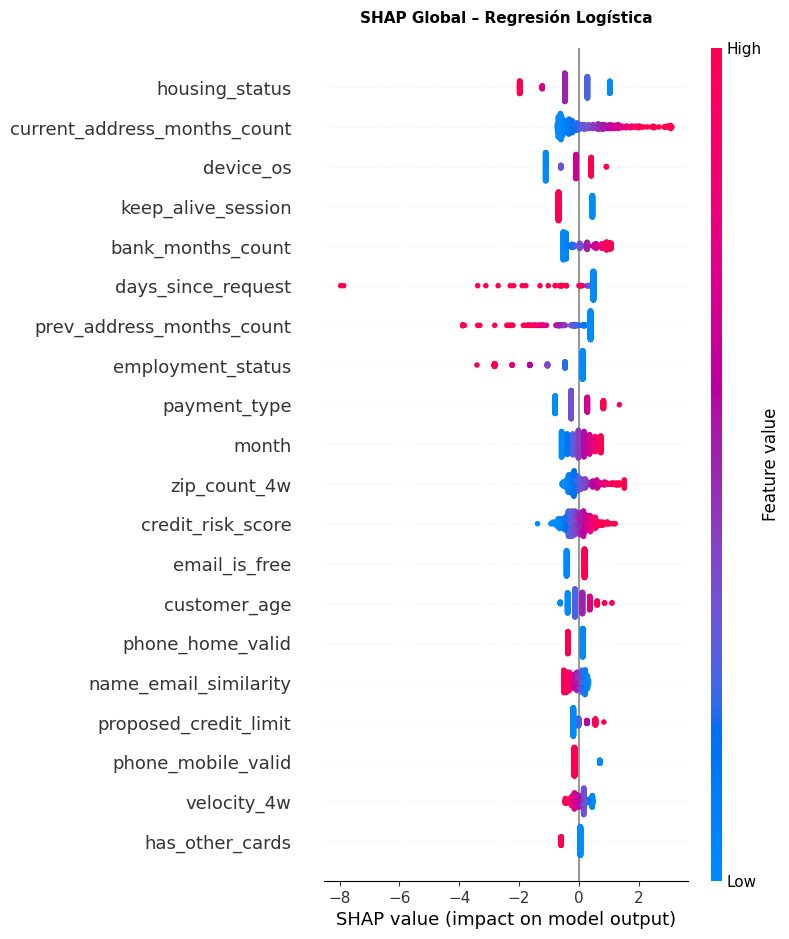

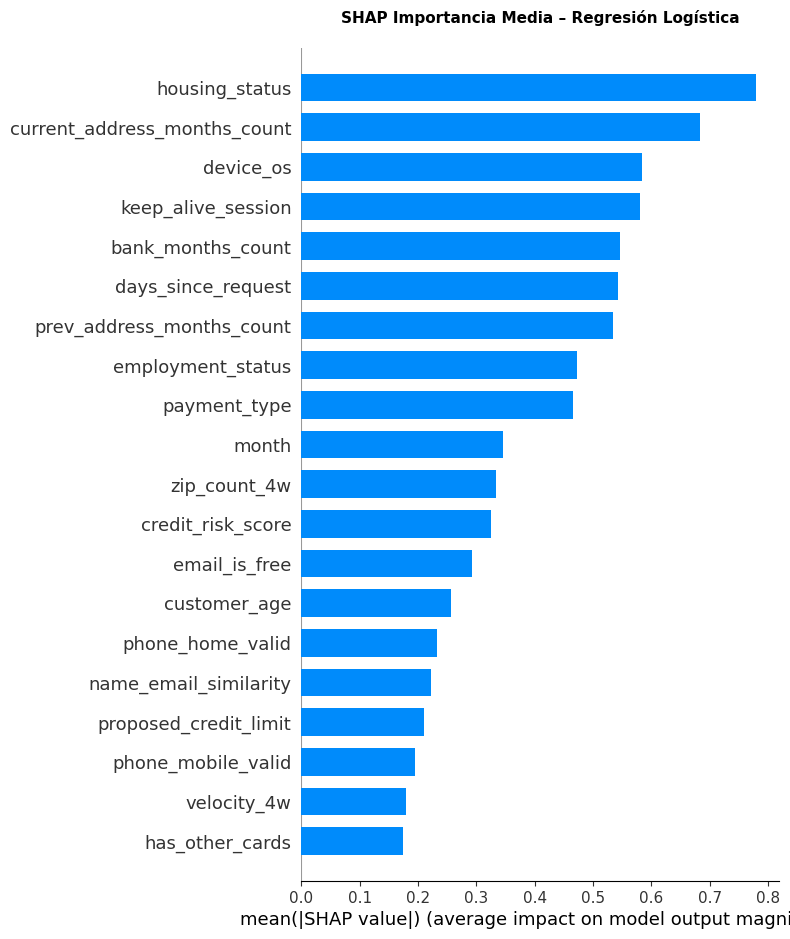

  ✔ SHAP global guardado: Regresión Logística

  Calculando SHAP local: Regresión Logística


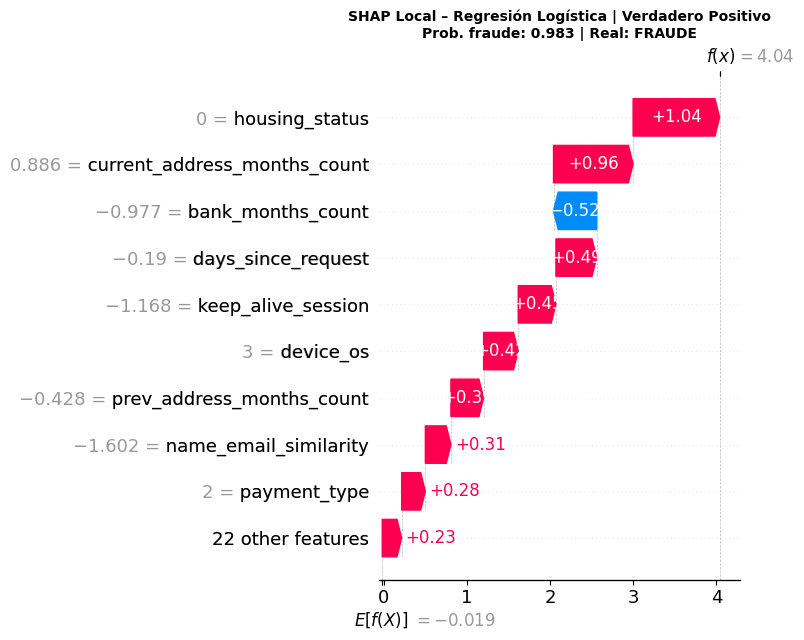

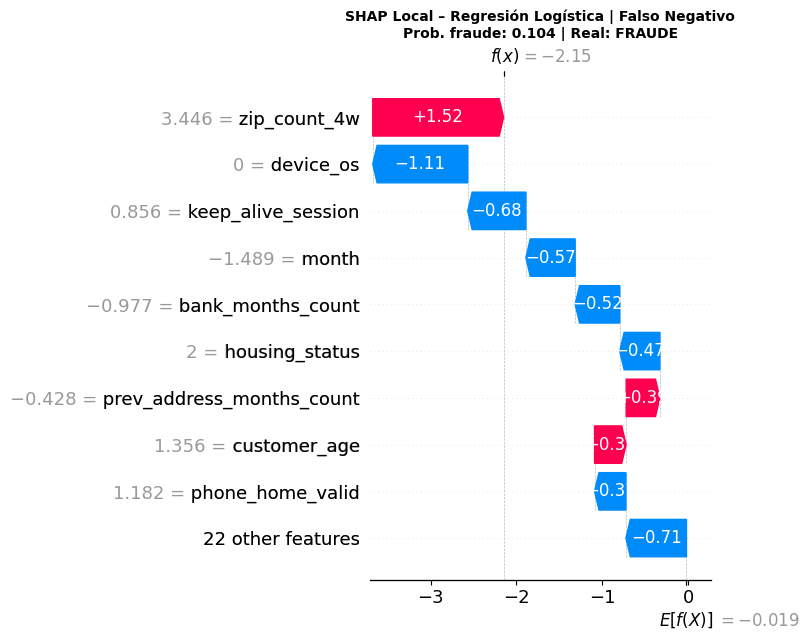

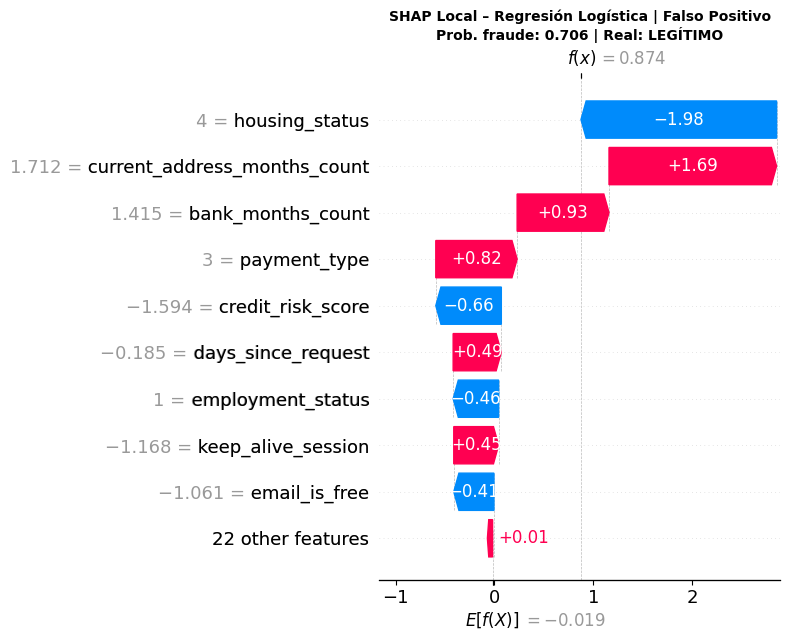

  ✔ SHAP local guardado: Regresión Logística

  Calculando LIME local: Regresión Logística


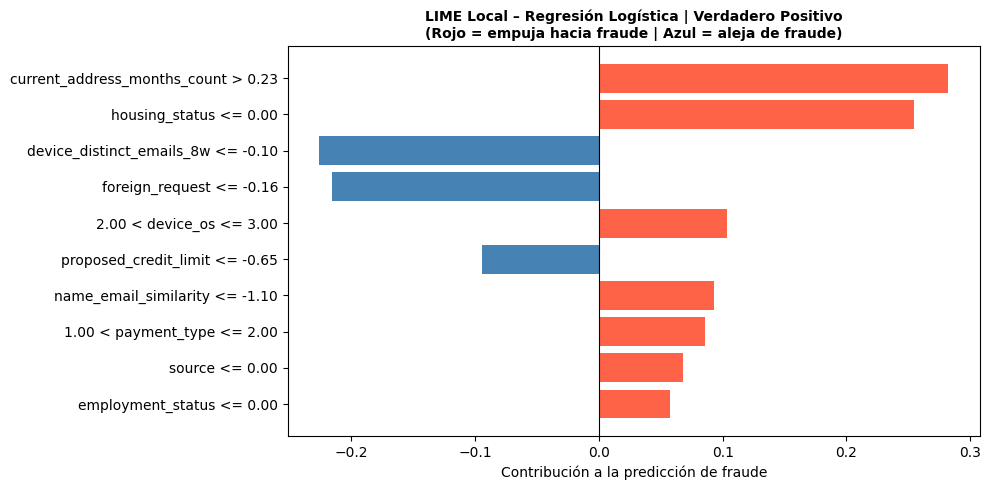

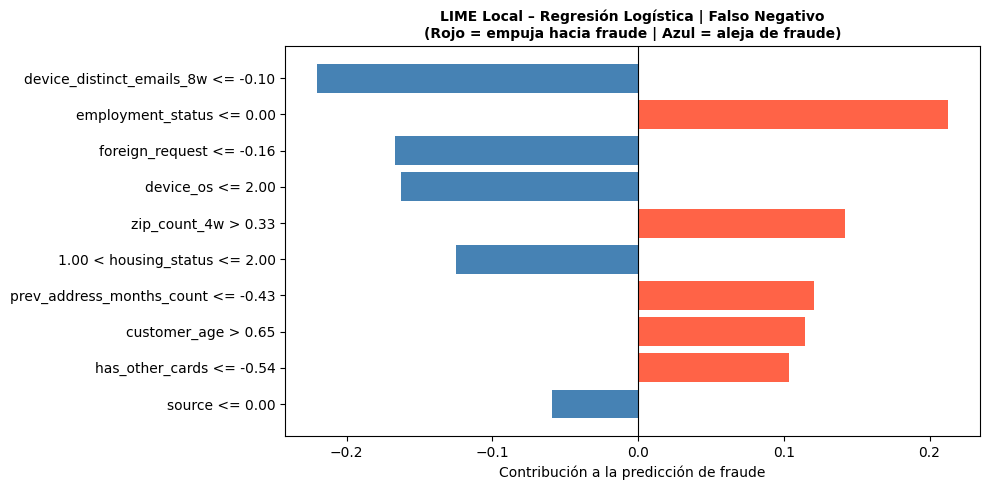

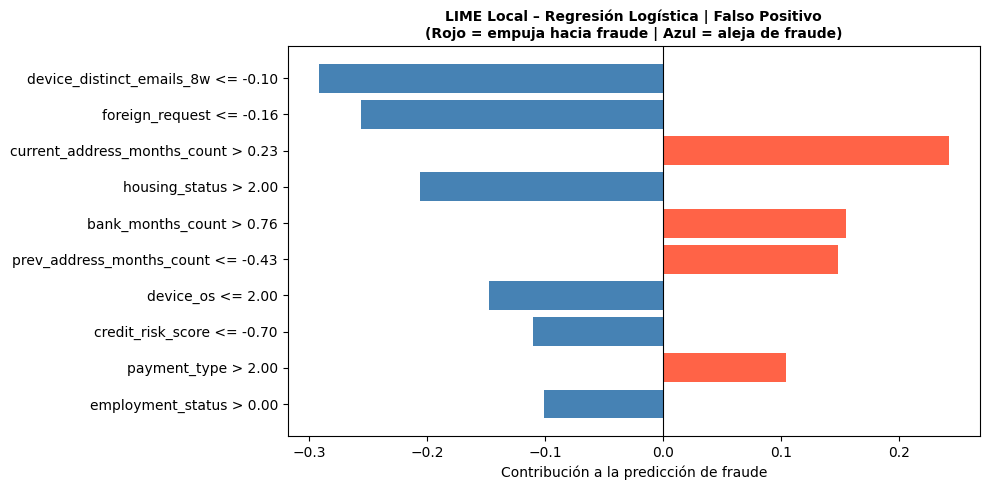


MODELO: ARBOL DE DECISIÓN

  Calculando SHAP global: Arbol de Decisión


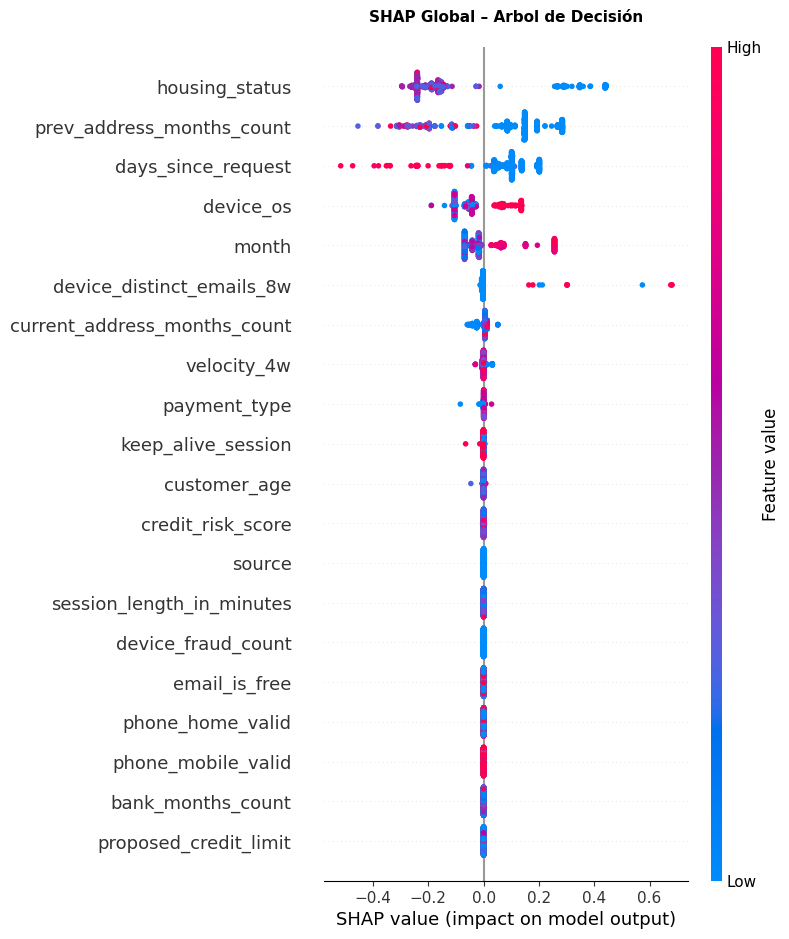

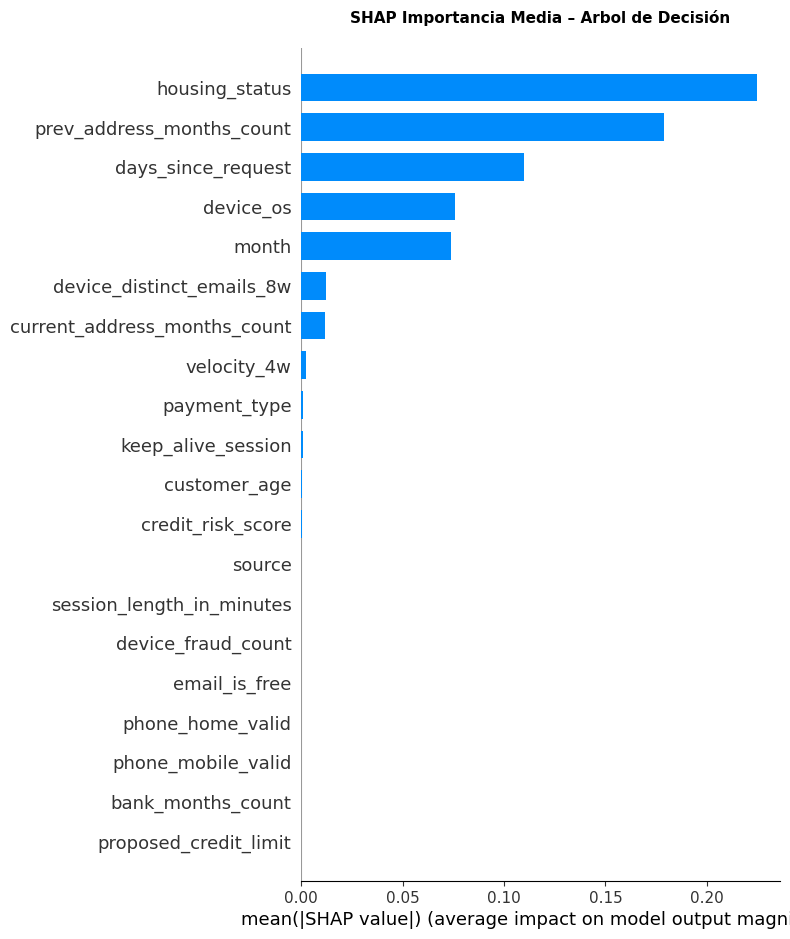

  ✔ SHAP global guardado: Arbol de Decisión

  Calculando SHAP local: Arbol de Decisión


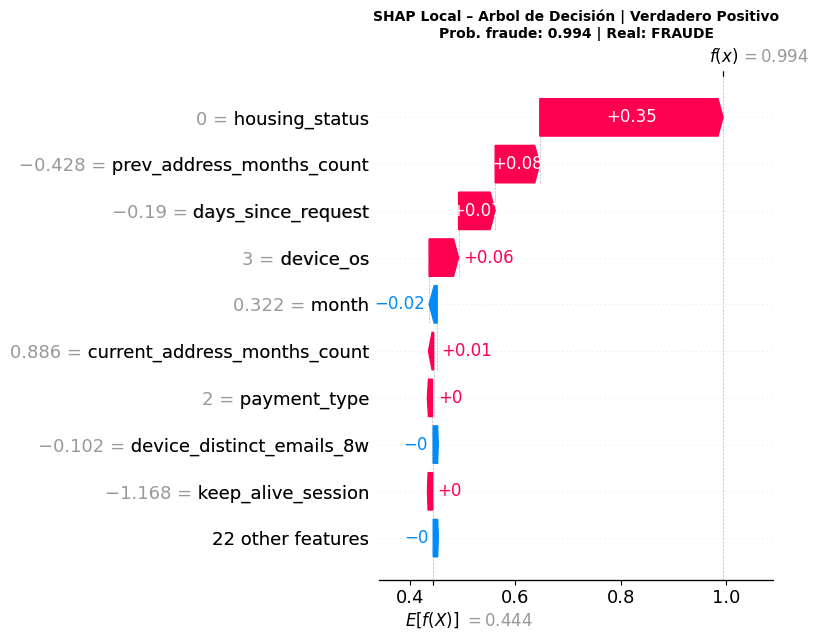

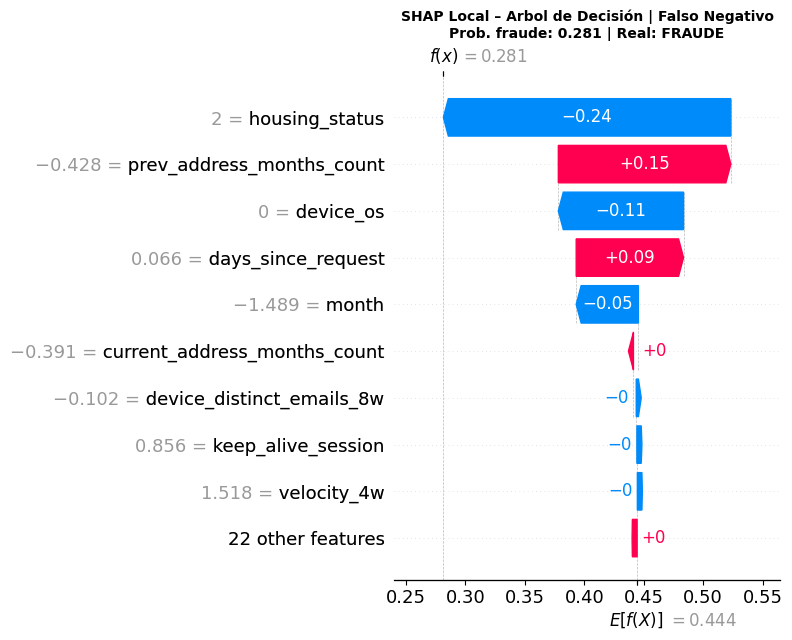

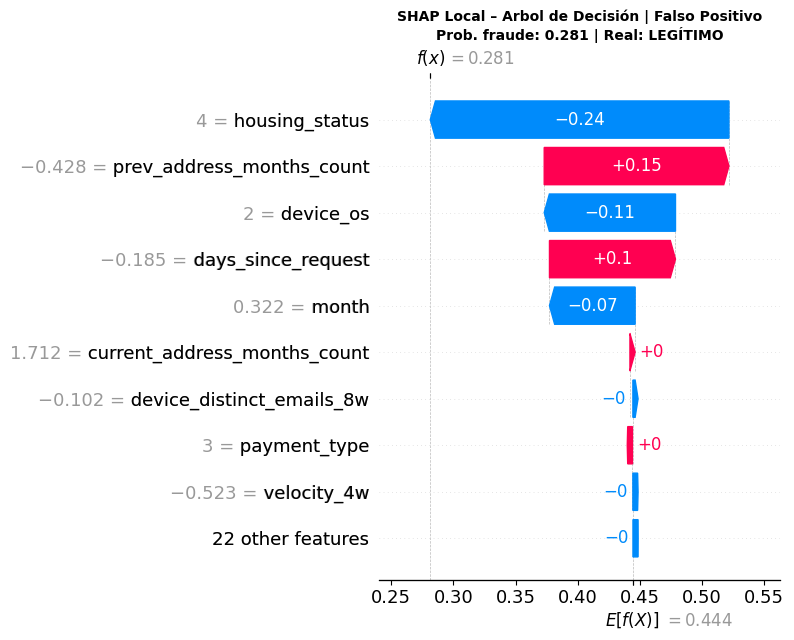

  ✔ SHAP local guardado: Arbol de Decisión

  Calculando LIME local: Arbol de Decisión


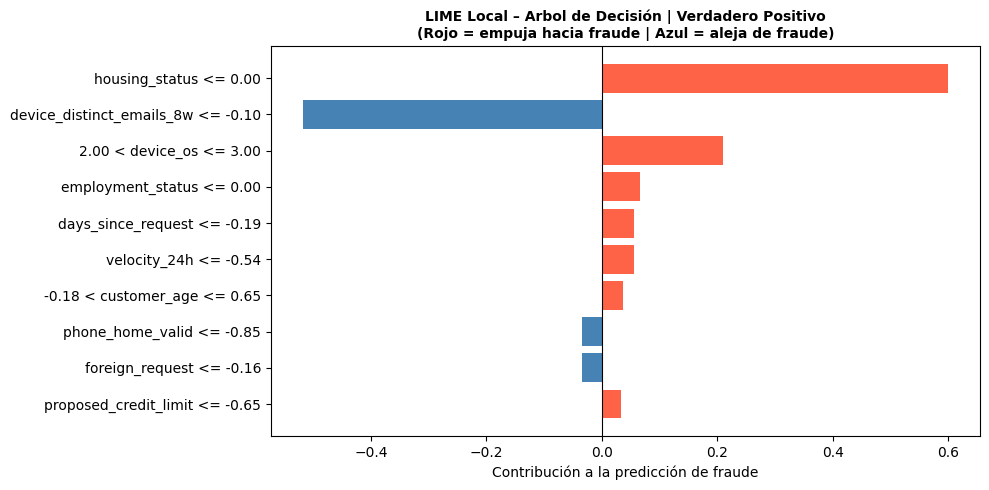

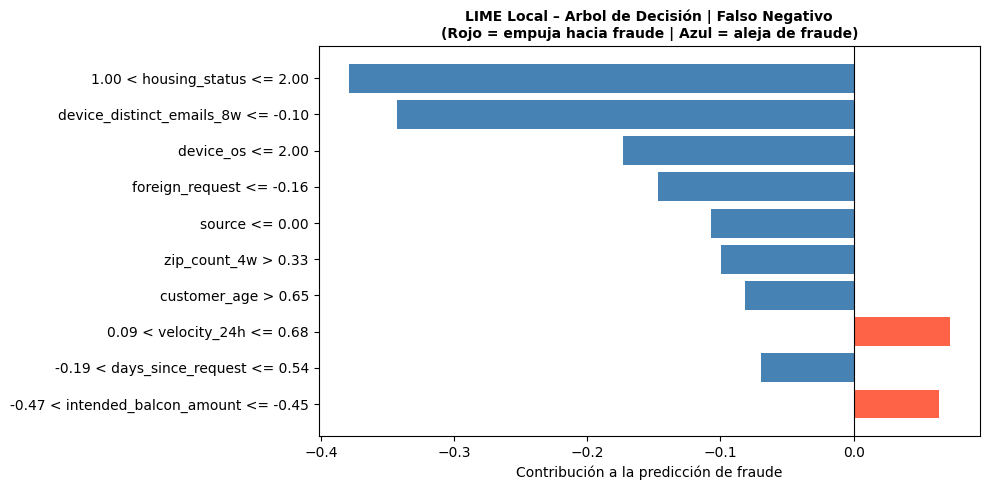

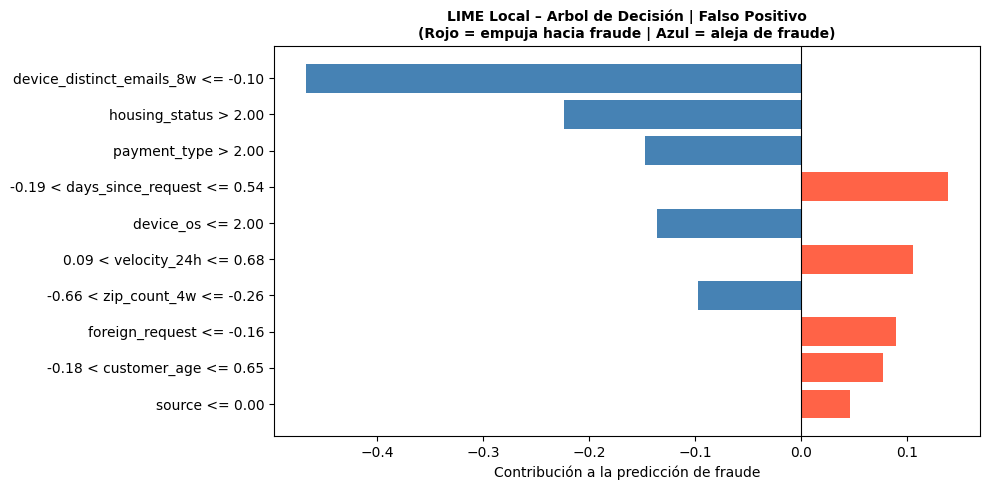


MODELO: RANDOM FOREST

  Calculando SHAP global: Random Forest


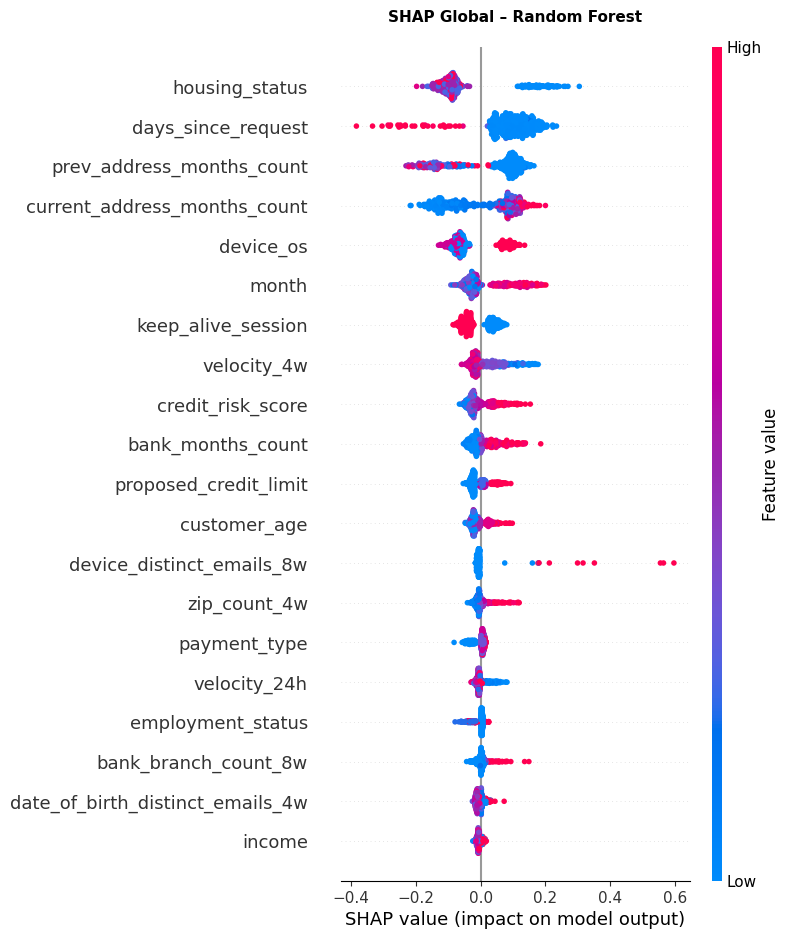

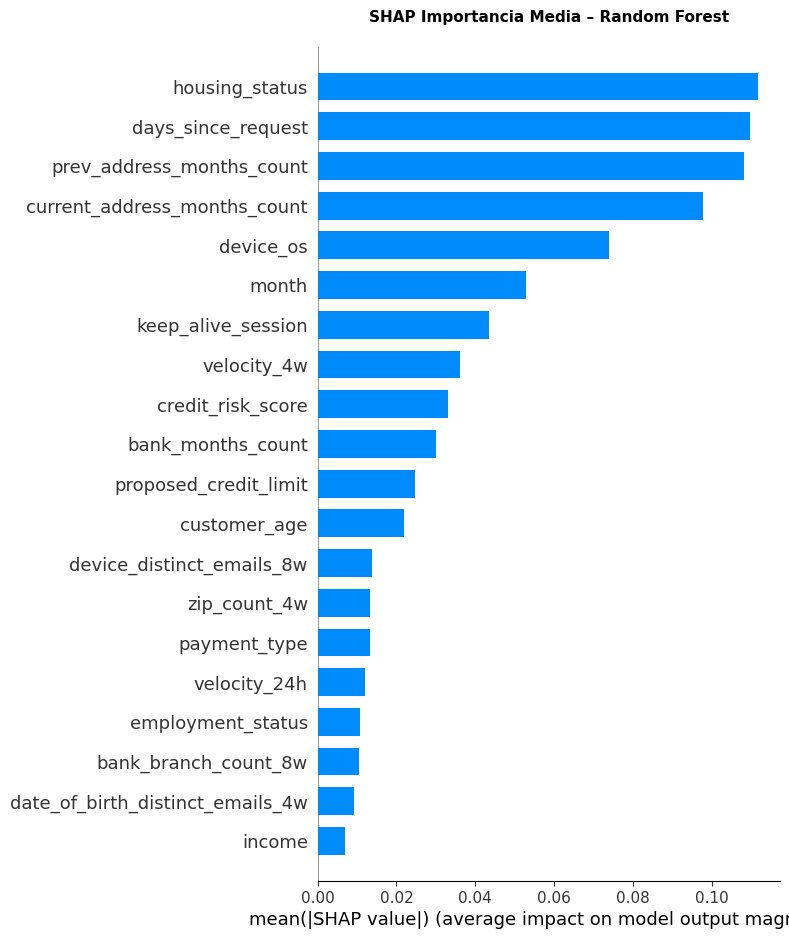

  ✔ SHAP global guardado: Random Forest

  Calculando SHAP local: Random Forest


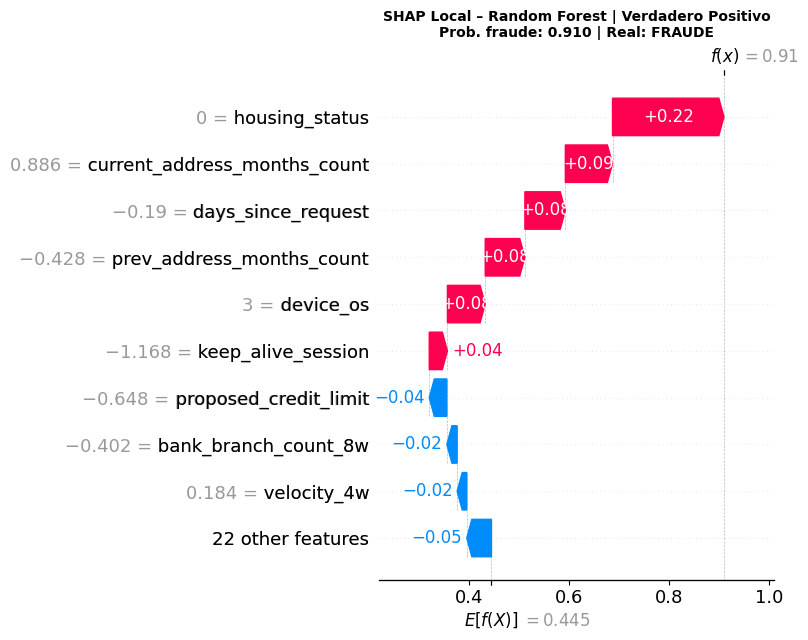

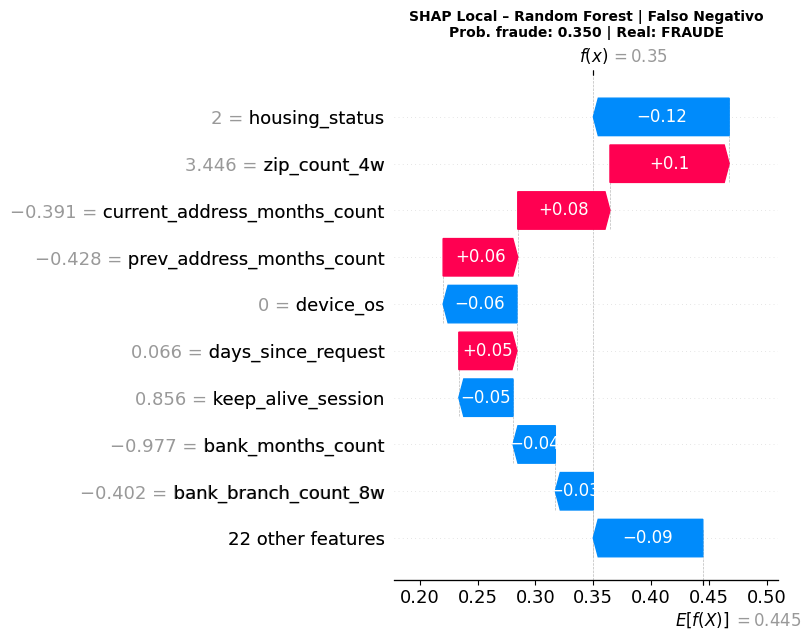

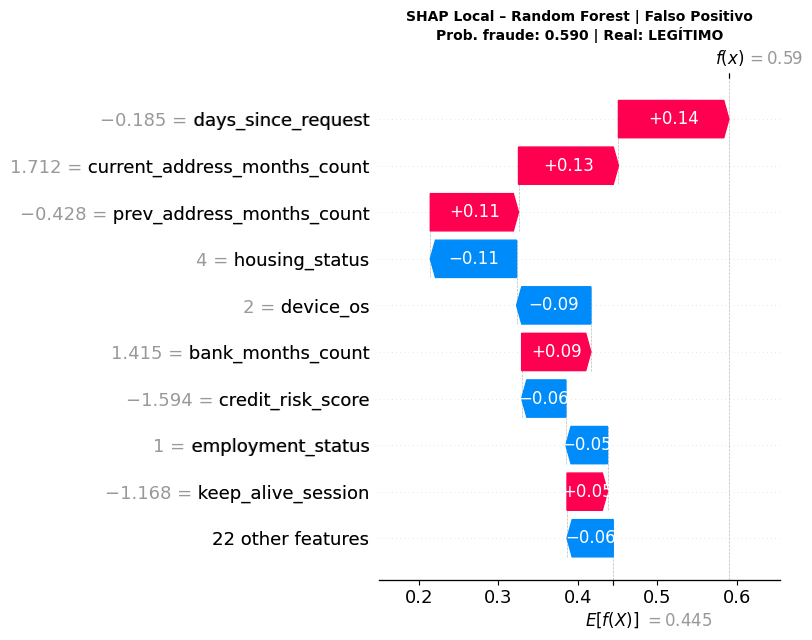

  ✔ SHAP local guardado: Random Forest

  Calculando LIME local: Random Forest


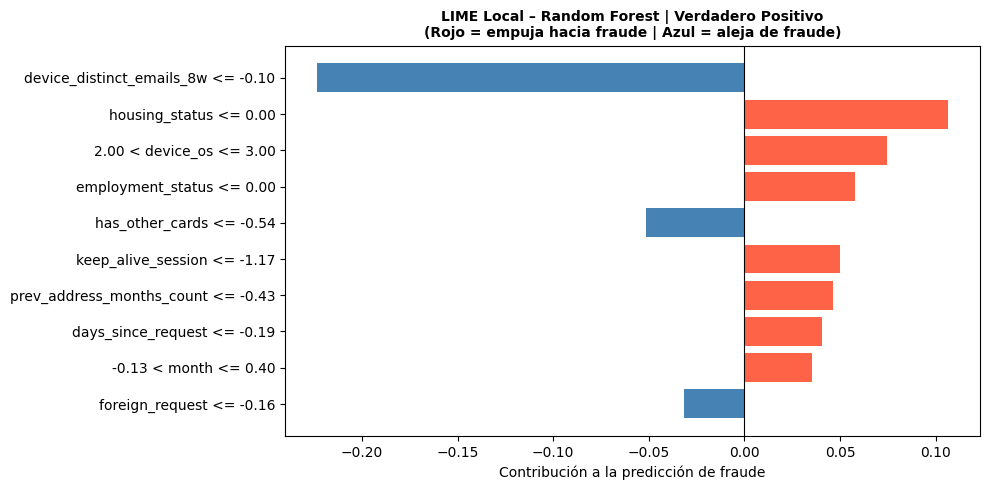

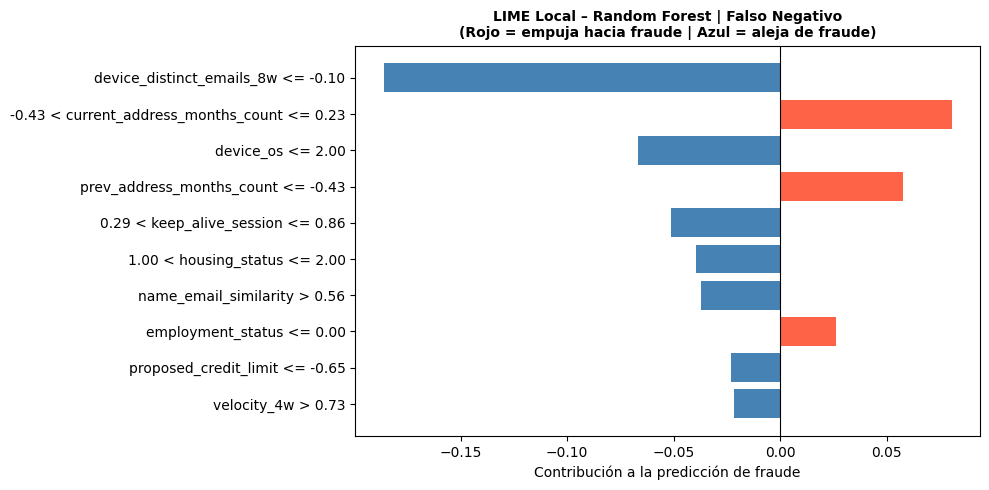

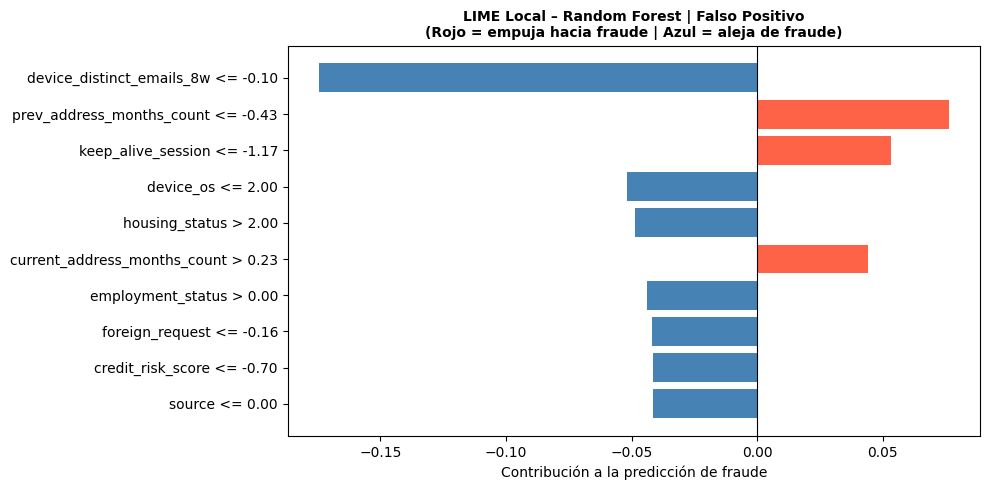


MODELO: XGBOOST

  Calculando SHAP global: XGBoost


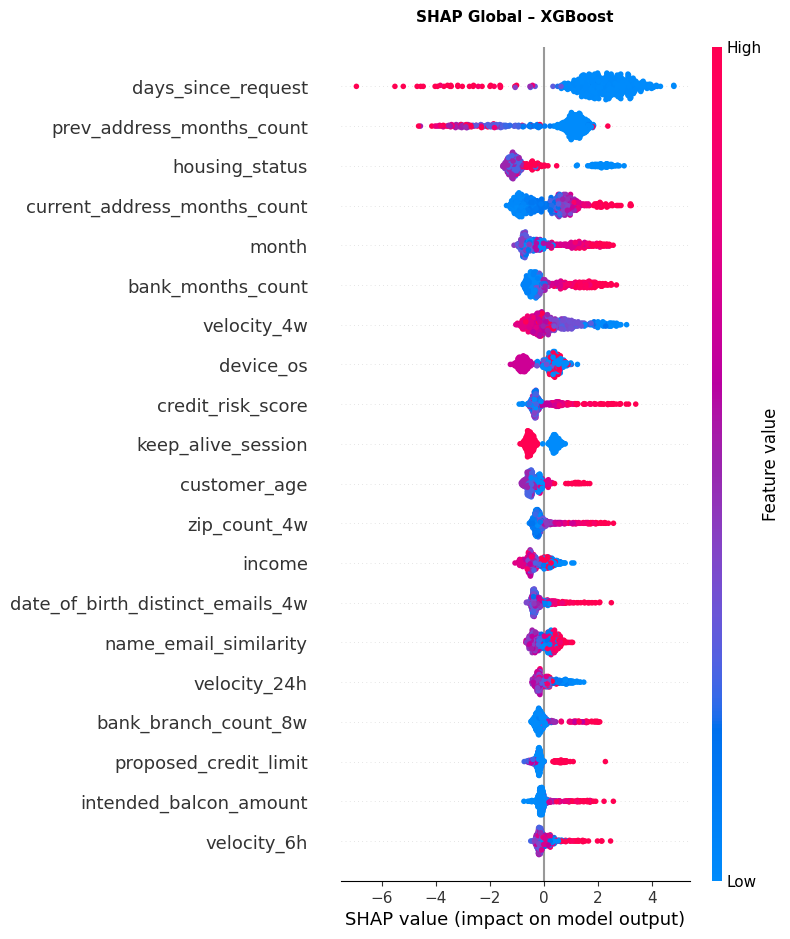

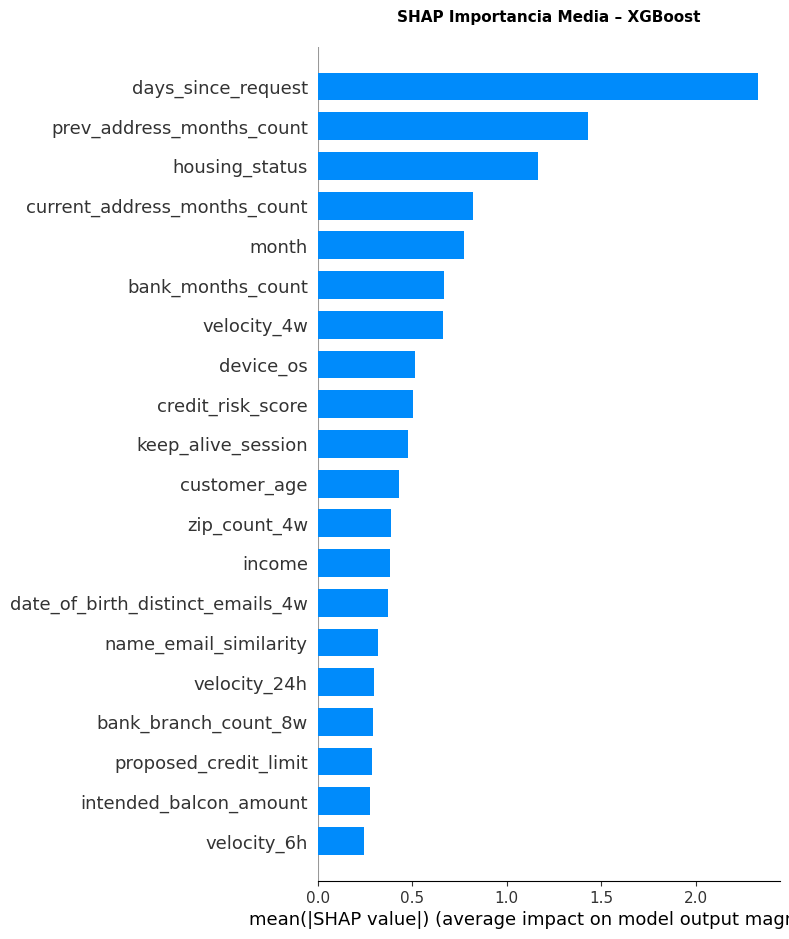

  ✔ SHAP global guardado: XGBoost

  Calculando SHAP local: XGBoost


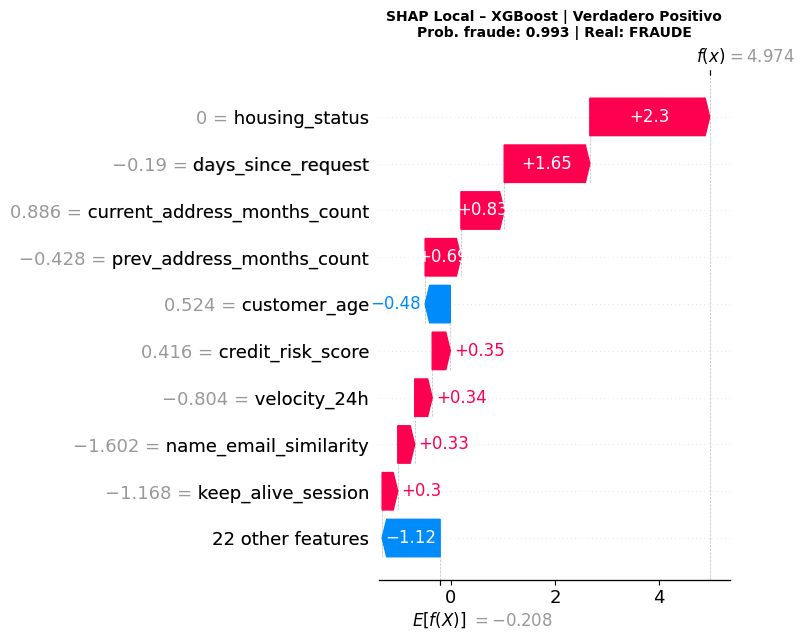

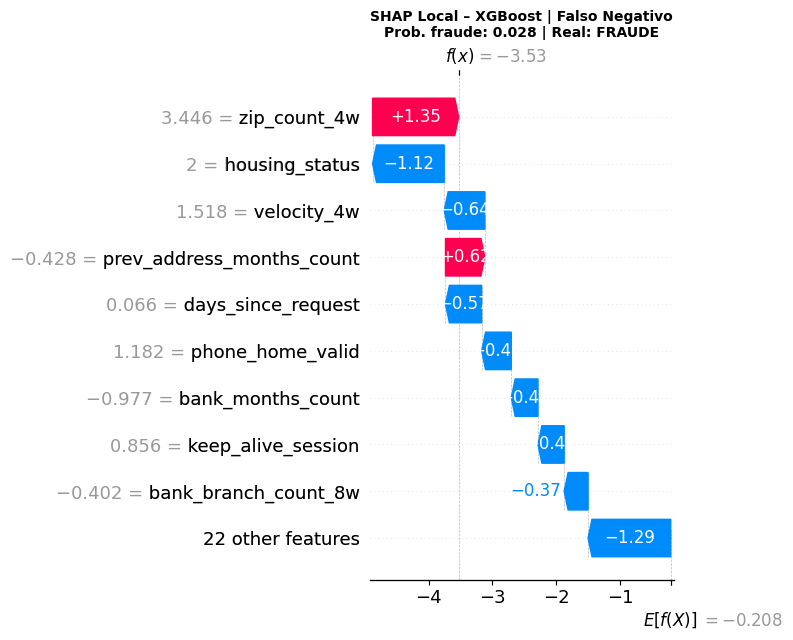

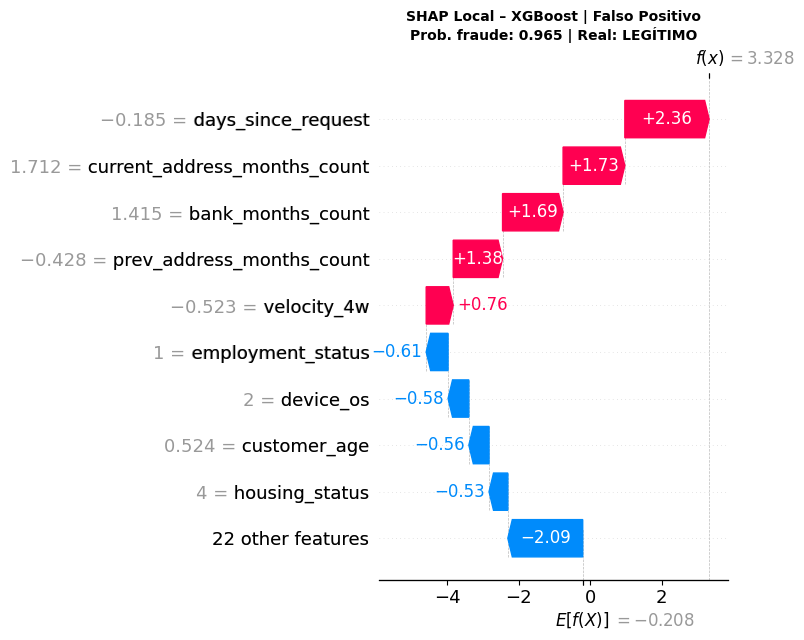

  ✔ SHAP local guardado: XGBoost

  Calculando LIME local: XGBoost


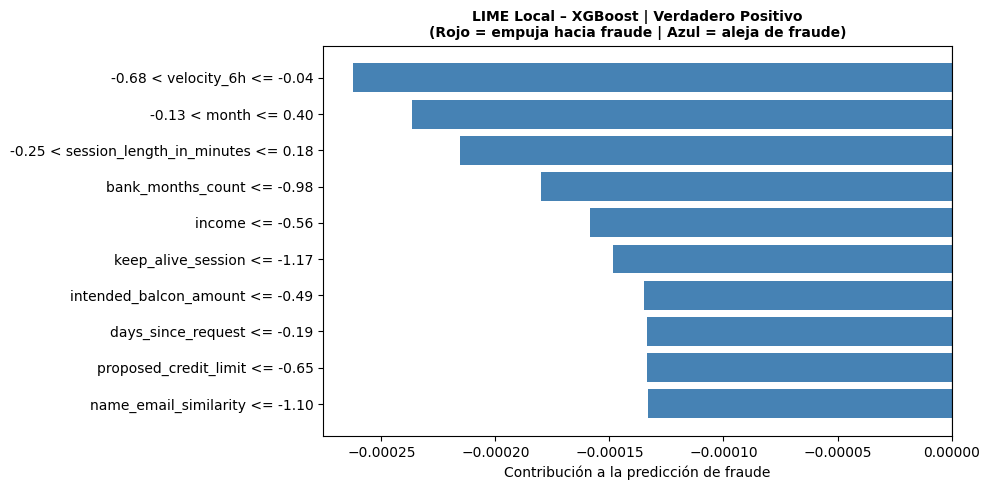

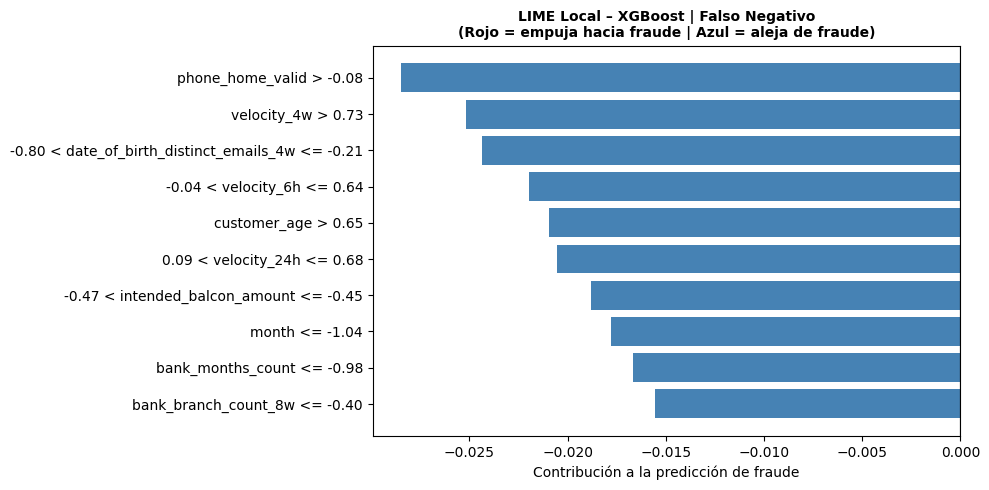

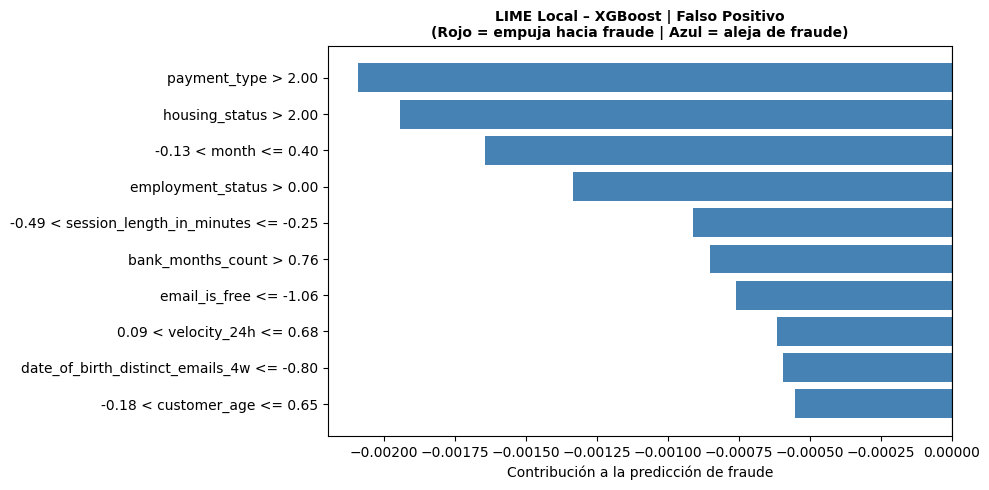


MODELO: LIGHTGBM

  Calculando SHAP global: LightGBM


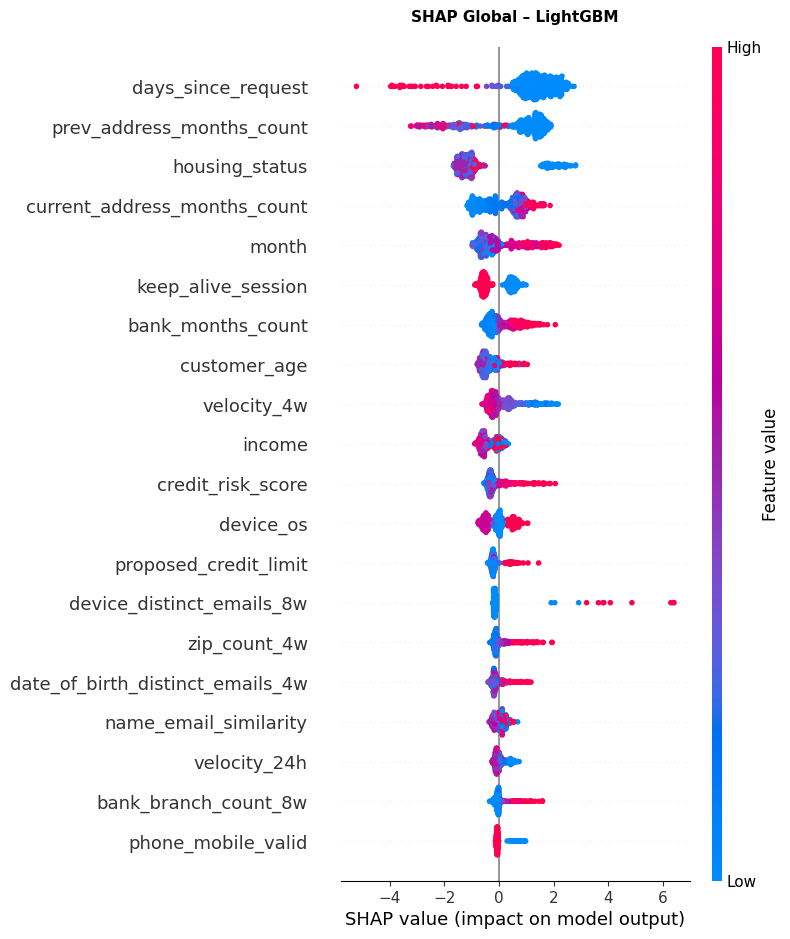

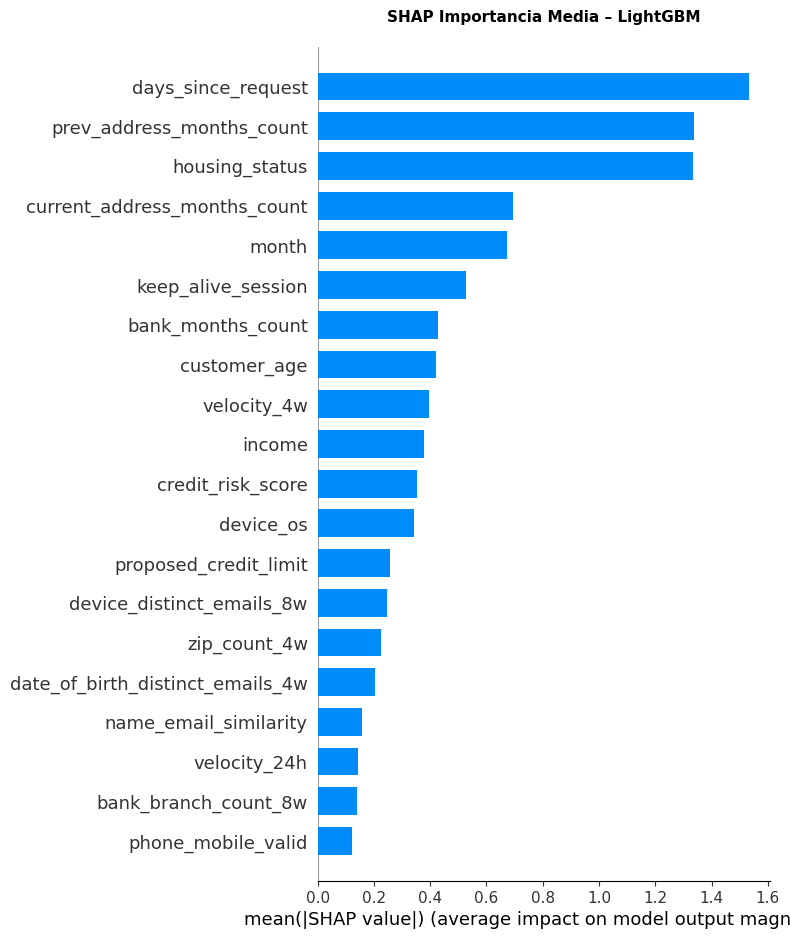

  ✔ SHAP global guardado: LightGBM

  Calculando SHAP local: LightGBM


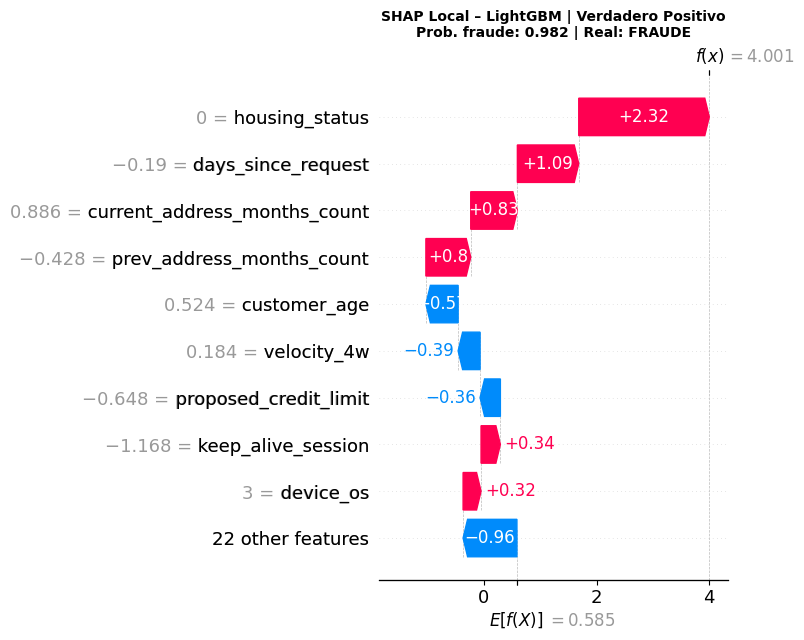

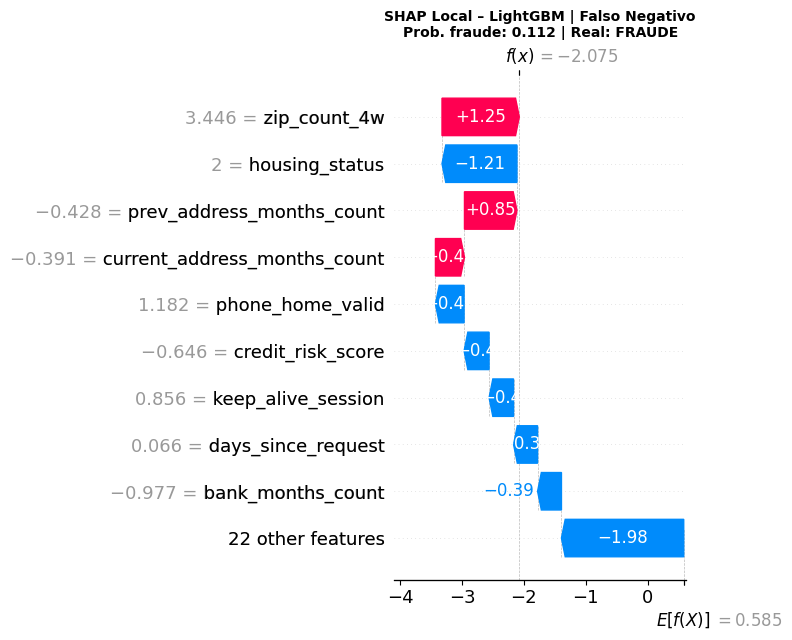

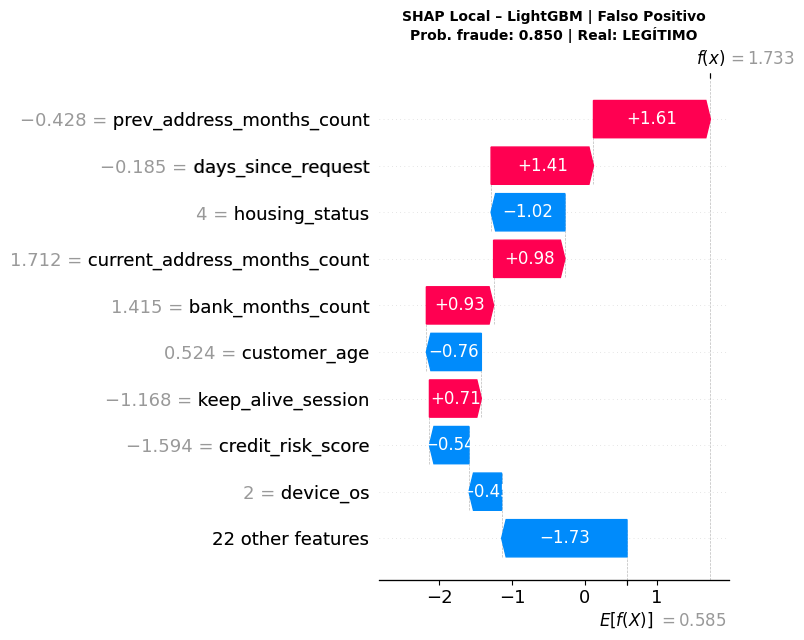

  ✔ SHAP local guardado: LightGBM

  Calculando LIME local: LightGBM


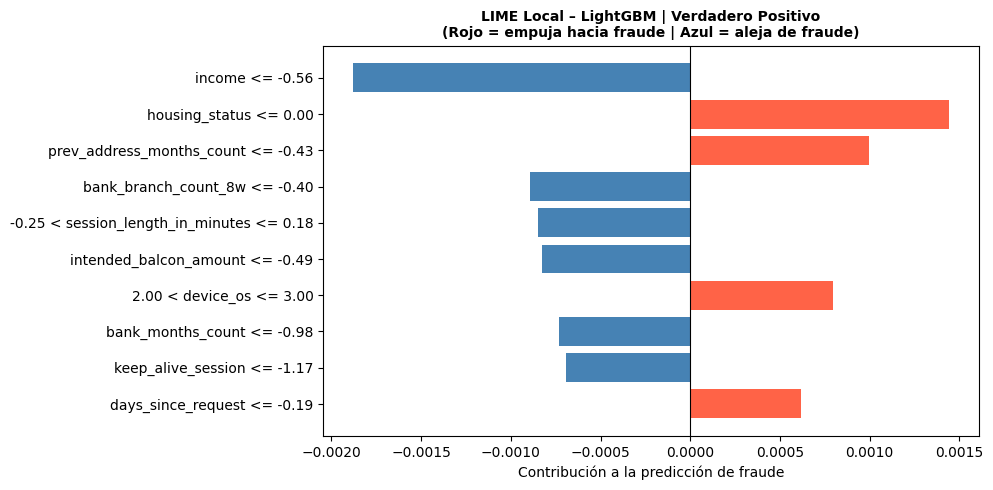

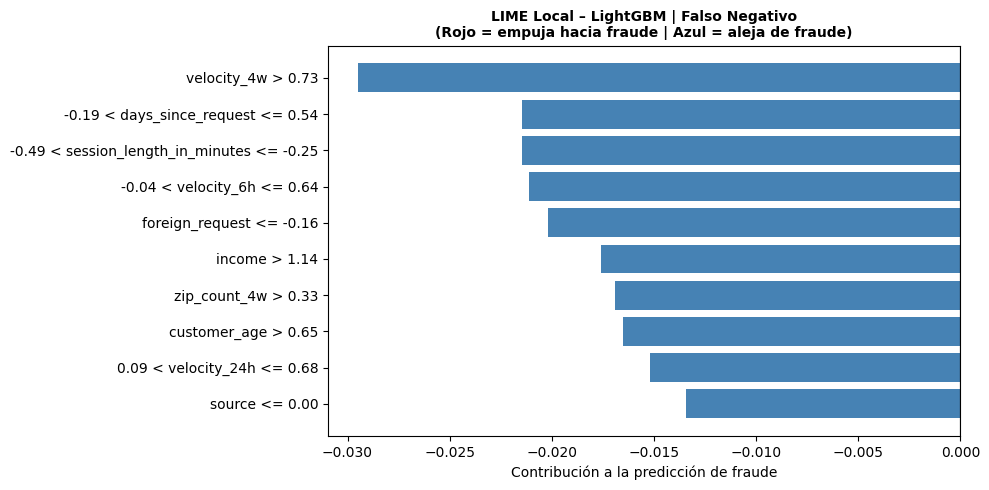

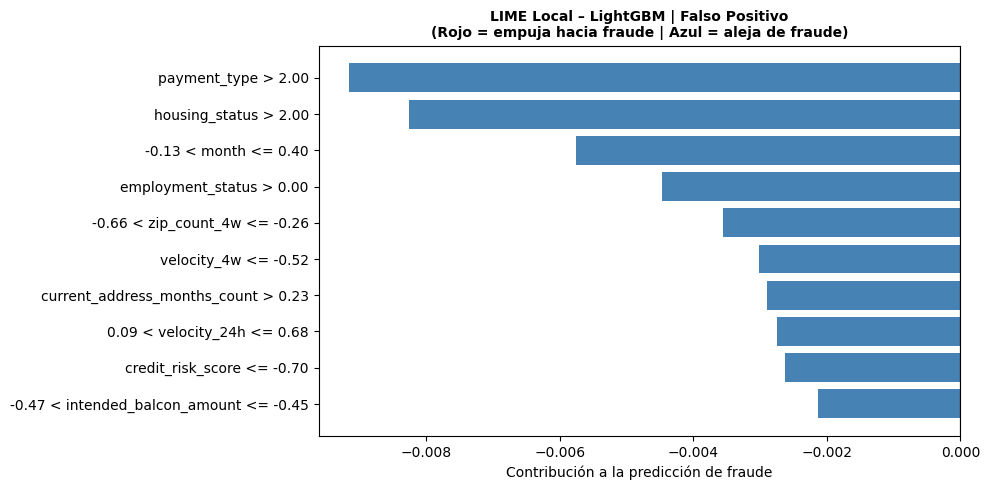


Análisis XAI completado para todos los modelos.


In [79]:
resumen_importancias = {}

print("\n" + "=" * 60)
print("ANÁLISIS XAI – TODOS LOS MODELOS")
print("=" * 60)

for nombre, modelo in modelos_entrenados.items():
    print(f"\n{'='*60}")
    print(f"MODELO: {nombre.upper()}")
    print(f"{'='*60}")

    explainer, sv = shap_global(nombre, modelo)
    resumen_importancias[nombre] = sv

    shap_local(nombre, modelo, explainer, sv)
    lime_local(nombre, modelo)

print("\nAnálisis XAI completado para todos los modelos.")

## SHAP y LIME MODELOS Deep Learning (MLP y TabTransformer)

Los modelos DL no están en `modelos_entrenados` porque son objetos PyTorch que requieren un tratamiento distinto: no exponen `predict_proba` directamente y el TabTransformer recibe dos tensores separados (categóricas + numéricas).

Para incluirlos en el análisis XAI con las mismas funciones reutilizables, creamos dos **wrappers** que envuelven cada modelo y exponen un `predict_proba` compatible con SHAP y LIME.

Usamos **KernelSHAP** (en lugar de TreeSHAP, que no aplica a redes neuronales) con un fondo reducido para mantener el tiempo de cálculo razonable.

In [80]:
# =============================================================================
# WRAPPERS para que MLP y TabTransformer expongan predict_proba
# como un modelo de scikit-learn
# =============================================================================

class MLPWrapper:
    """Envuelve el MLP de PyTorch para que SHAP/LIME lo puedan usar."""
    def __init__(self, modelo, device):
        self.modelo = modelo
        self.device = device

    def predict_proba(self, X):
        self.modelo.eval()
        if isinstance(X, pd.DataFrame):
            X = X.values
        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
        with torch.no_grad():
            probs = self.modelo(X_tensor).cpu().numpy()
        # SHAP/LIME esperan [P(clase 0), P(clase 1)]
        probs = probs.reshape(-1, 1)
        return np.hstack([1 - probs, probs])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


class TabTransformerWrapper:
    """Envuelve el TabTransformer separando categóricas y numéricas internamente."""
    def __init__(self, modelo, cat_idx, num_idx, device):
        self.modelo = modelo
        self.cat_idx = cat_idx
        self.num_idx = num_idx
        self.device = device

    def predict_proba(self, X):
        self.modelo.eval()
        if isinstance(X, pd.DataFrame):
            X = X.values
        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
        X_cat = X_tensor[:, self.cat_idx].long().clamp(min=0)
        X_num = X_tensor[:, self.num_idx]
        with torch.no_grad():
            probs = self.modelo(X_cat, X_num).cpu().numpy()
        probs = probs.reshape(-1, 1)
        return np.hstack([1 - probs, probs])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


# Creamos los wrappers
mlp_wrapped = MLPWrapper(mlp, device)
tab_wrapped = TabTransformerWrapper(tabtransformer, cat_idx, num_idx, device)

# Verificación rápida: deben devolver shape (N, 2)
print("Test MLPWrapper:", mlp_wrapped.predict_proba(X_test_enc.iloc[:5]).shape)
print("Test TabTransformerWrapper:", tab_wrapped.predict_proba(X_test_enc.iloc[:5]).shape)

Test MLPWrapper: (5, 2)
Test TabTransformerWrapper: (5, 2)


In [81]:
# =============================================================================
# FUNCIÓN: SHAP global para modelos de Deep Learning (KernelSHAP)
# =============================================================================
# KernelSHAP es lento, así que reducimos:
#  - background a 50 muestras (en lugar de todo X_train_bal)
#  - muestra a explicar a 100 casos (en lugar de 500)

def shap_global_dl(nombre, wrapper):
    print(f"\n  Calculando SHAP global (KernelSHAP): {nombre}")
    print(f"  Esto puede tardar varios minutos...")

    # Fondo reducido para acelerar KernelSHAP
    background = shap.sample(X_train_bal, 50, random_state=42)
    muestra_shap_dl = X_test_enc.sample(n=100, random_state=42)

    # Función que SHAP llamará: debe devolver solo P(clase 1) para clasificación binaria
    def predict_fn(X):
        return wrapper.predict_proba(X)[:, 1]

    explainer = shap.KernelExplainer(predict_fn, background)
    sv = explainer.shap_values(muestra_shap_dl, nsamples=100)

    # Beeswarm
    plt.figure(figsize=(10, 7))
    shap.summary_plot(sv, muestra_shap_dl, feature_names=feature_names,
                      show=False, plot_type='dot')
    plt.title(f"SHAP Global – {nombre}", fontsize=11, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # Barras
    plt.figure(figsize=(10, 6))
    shap.summary_plot(sv, muestra_shap_dl, feature_names=feature_names,
                      show=False, plot_type='bar')
    plt.title(f"SHAP Importancia Media – {nombre}", fontsize=11, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"  ✔ SHAP global guardado: {nombre}")
    return explainer, sv, muestra_shap_dl


# =============================================================================
# FUNCIÓN: SHAP local para los 3 casos VP/FN/FP en modelos DL
# =============================================================================

def shap_local_dl(nombre, wrapper, explainer):
    print(f"\n  Calculando SHAP local: {nombre}")
    local_instances = X_test_enc.iloc[indices_casos]

    sv_casos = explainer.shap_values(local_instances, nsamples=100)
    base_val = explainer.expected_value
    if isinstance(base_val, (list, np.ndarray)):
        base_val = base_val[0] if not np.isscalar(base_val) else base_val

    y_prob = wrapper.predict_proba(X_test_enc)[:, 1]

    k = 0
    for nombre_caso, idx_original in casos.items():
        if idx_original is None:
            continue
        if k >= len(sv_casos):
            continue

        etiqueta = 'FRAUDE' if y_test.values[idx_original] == 1 else 'LEGÍTIMO'
        prob_modelo = y_prob[idx_original]

        explanation = shap.Explanation(
            values=sv_casos[k],
            base_values=base_val,
            data=local_instances.iloc[k].values,
            feature_names=feature_names
        )

        plt.figure(figsize=(10, 6))
        shap.plots.waterfall(explanation, show=False, max_display=10)
        plt.title(f"SHAP Local – {nombre} | {nombre_caso}\n"
                  f"Real: {etiqueta} | Prob. fraude: {prob_modelo:.3f}",
                  fontsize=10, fontweight='bold')
        plt.tight_layout()
        plt.show()
        k += 1

    print(f"  ✔ SHAP local guardado: {nombre}")


# =============================================================================
# FUNCIÓN: LIME local para modelos DL (igual que para clásicos)
# =============================================================================

def lime_local_dl(nombre, wrapper):
    print(f"\n  Calculando LIME local: {nombre}")

    def predecir(X):
        return wrapper.predict_proba(X)

    for nombre_caso, idx in casos.items():
        if idx is None:
            continue

        exp = explainer_lime.explain_instance(
            data_row=X_test_enc.iloc[idx].values,
            predict_fn=predecir,
            num_features=10,
            num_samples=300
        )

        lime_pesos = exp.as_list(label=1)
        variables  = [x[0] for x in lime_pesos]
        pesos      = [x[1] for x in lime_pesos]
        colores    = ['tomato' if p > 0 else 'steelblue' for p in pesos]

        plt.figure(figsize=(10, 5))
        plt.barh(variables[::-1], pesos[::-1], color=colores[::-1])
        plt.axvline(x=0, color='black', linewidth=0.8)
        plt.xlabel("Contribución a la predicción de fraude")
        plt.title(f"LIME Local – {nombre} | {nombre_caso}\n"
                  f"(Rojo = empuja hacia fraude | Azul = aleja de fraude)",
                  fontsize=10, fontweight='bold')
        plt.tight_layout()
        plt.show()

    print(f"  ✔ LIME local guardado: {nombre}")


ANÁLISIS XAI – MODELOS DE DEEP LEARNING

MODELO: MLP

  Calculando SHAP global (KernelSHAP): MLP
  Esto puede tardar varios minutos...


  0%|          | 0/100 [00:00<?, ?it/s]

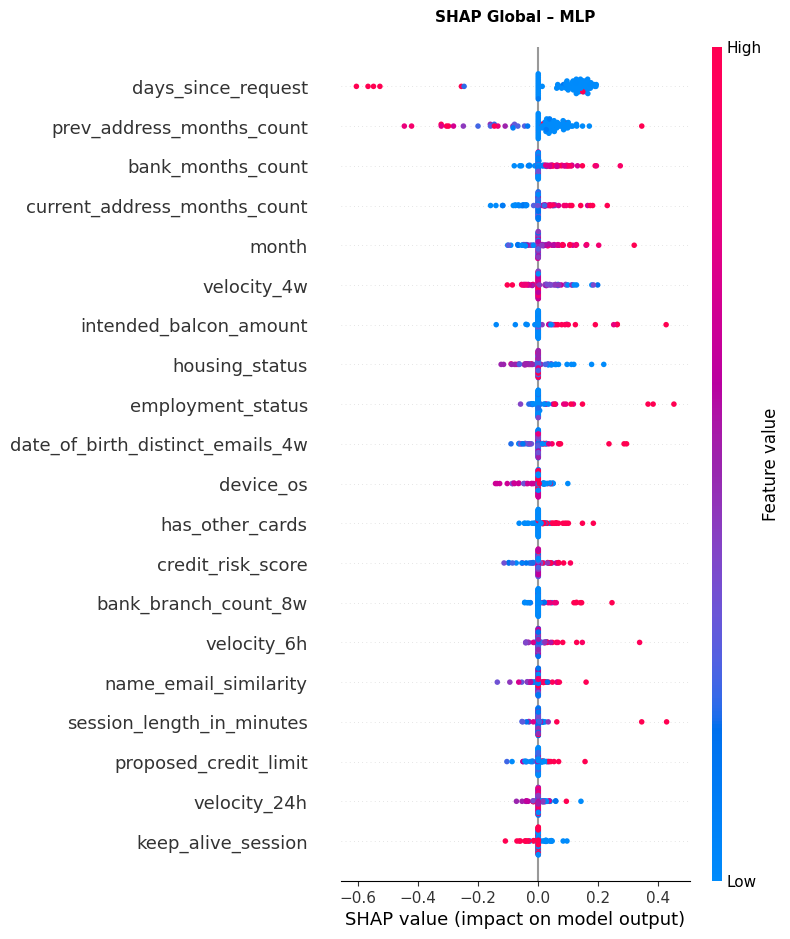

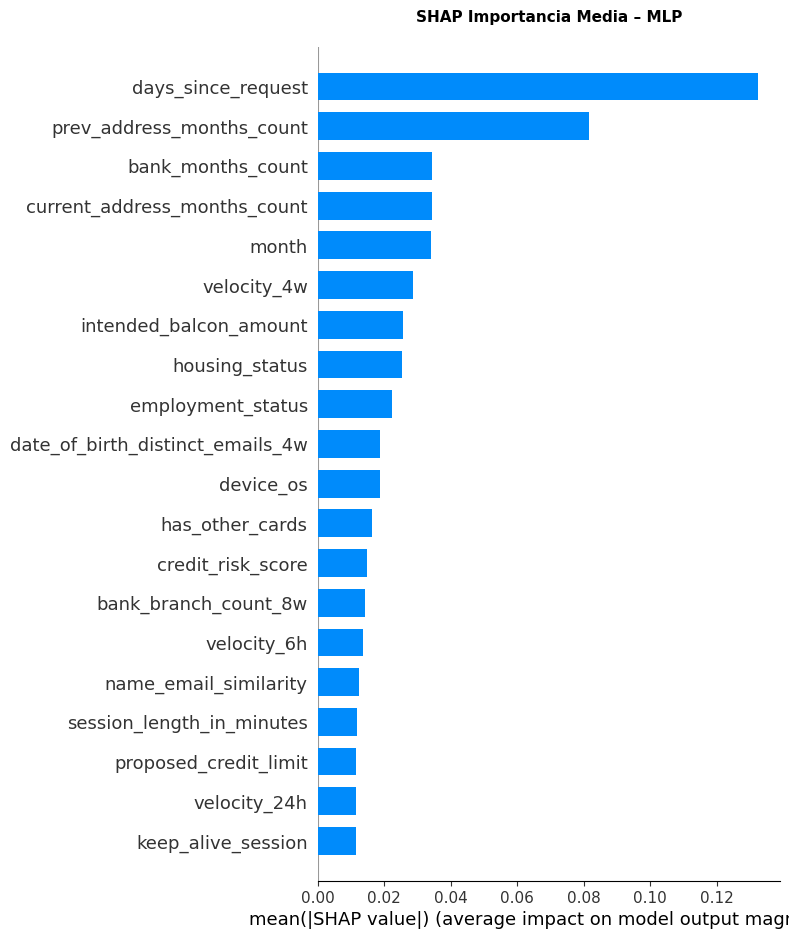

  ✔ SHAP global guardado: MLP

  Calculando SHAP local: MLP


  0%|          | 0/3 [00:00<?, ?it/s]

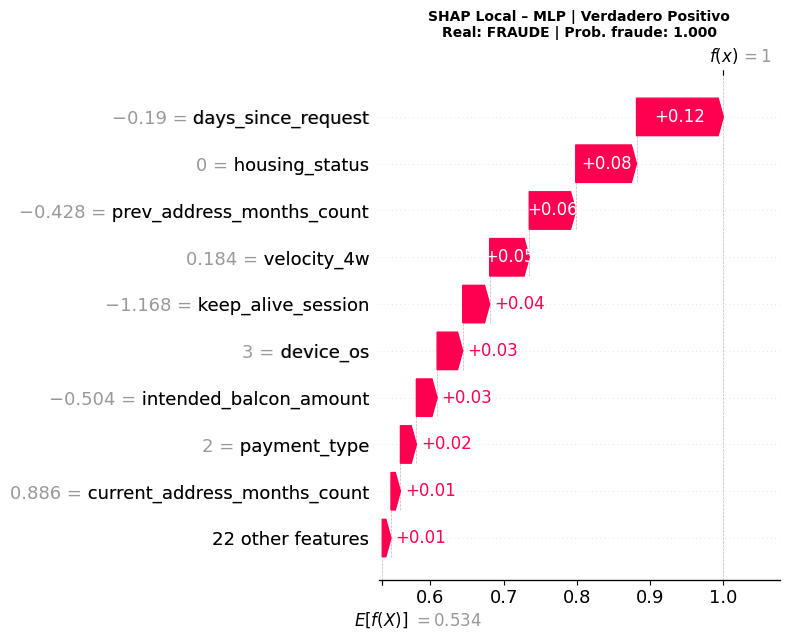

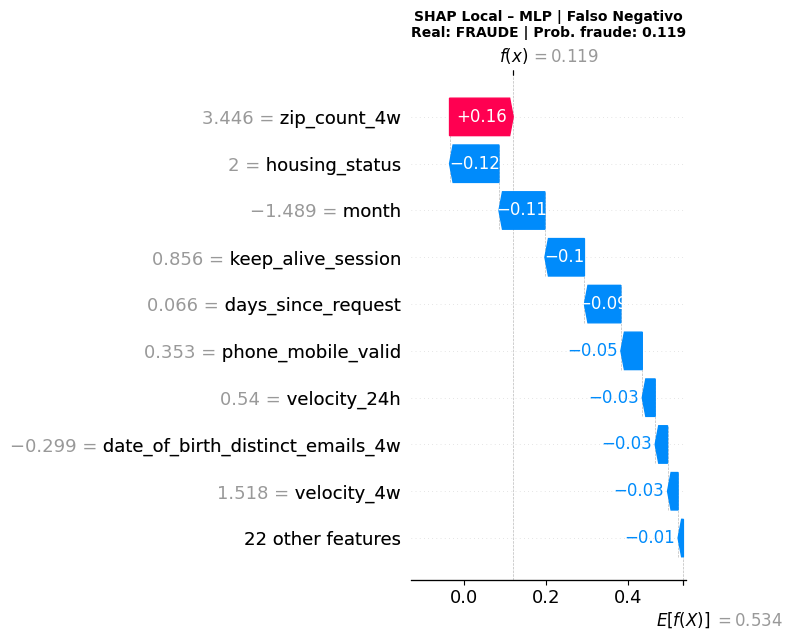

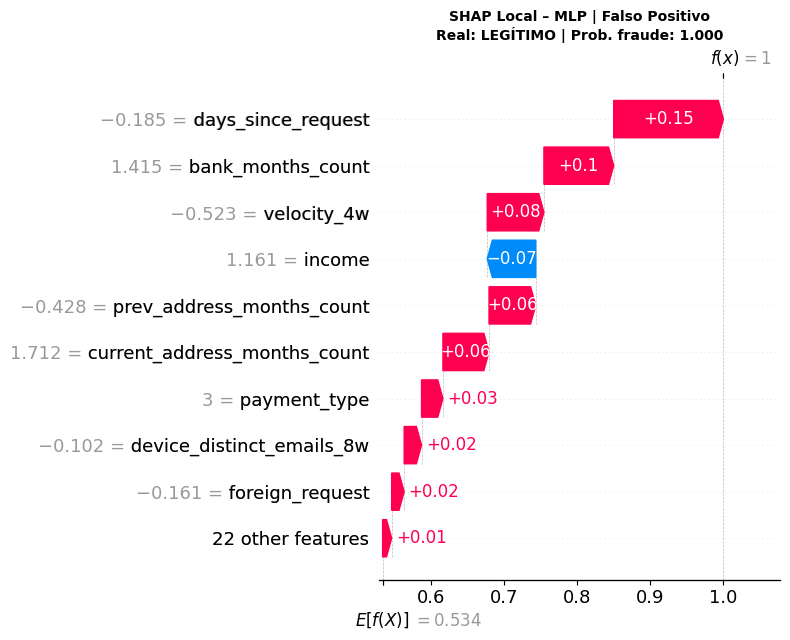

  ✔ SHAP local guardado: MLP

  Calculando LIME local: MLP


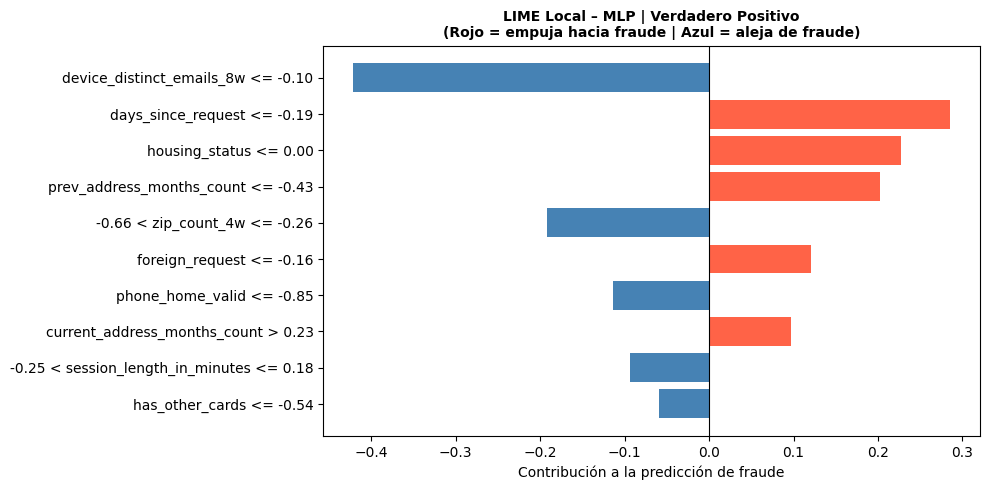

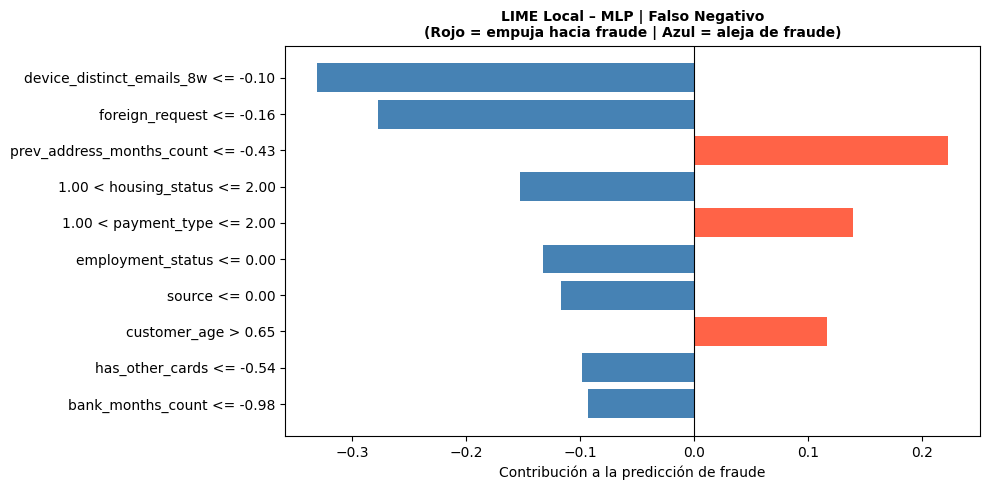

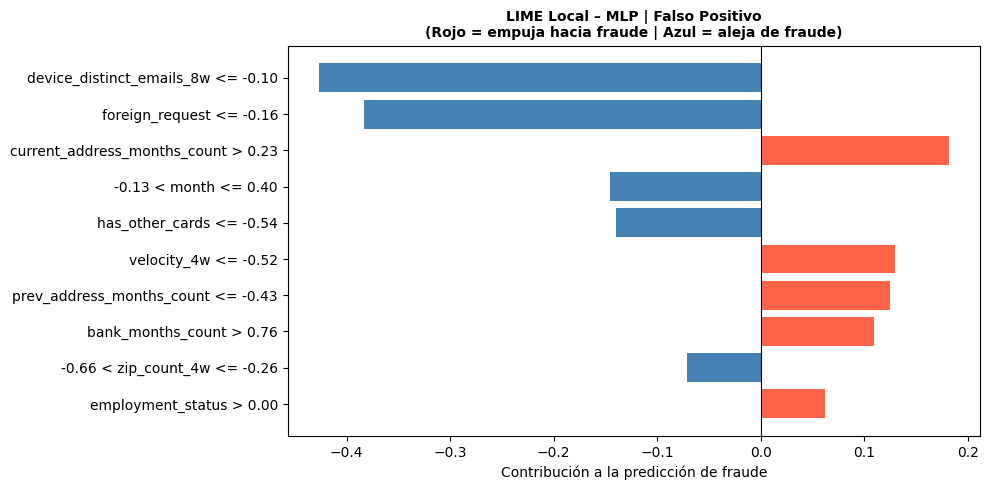

  ✔ LIME local guardado: MLP

MODELO: TABTRANSFORMER

  Calculando SHAP global (KernelSHAP): TabTransformer
  Esto puede tardar varios minutos...


  0%|          | 0/100 [00:00<?, ?it/s]

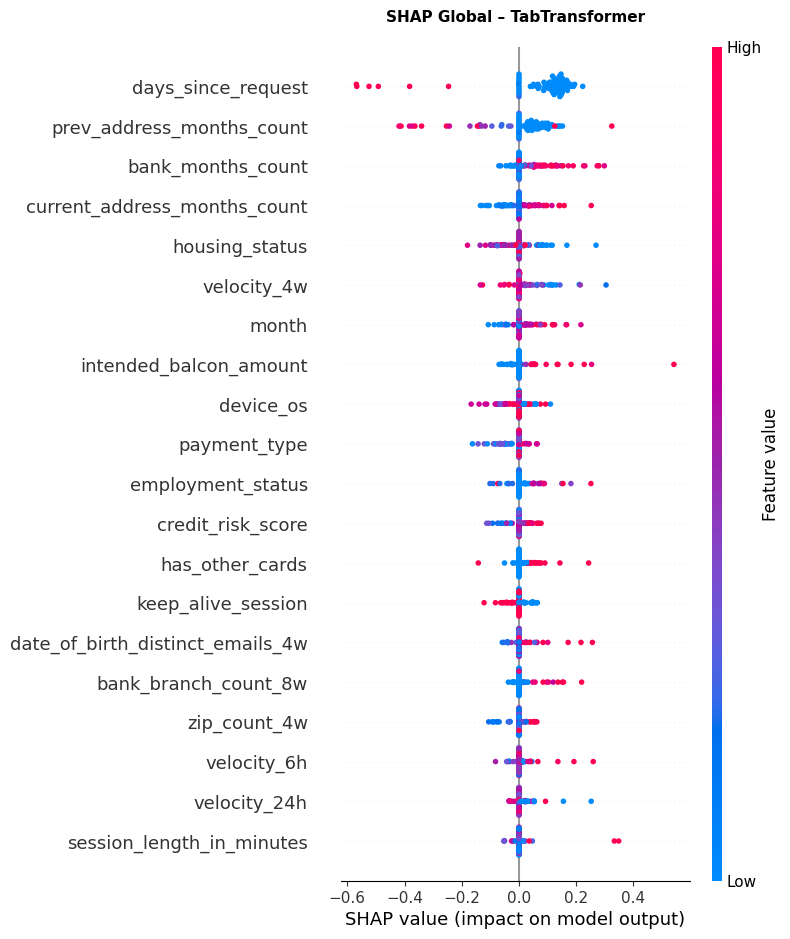

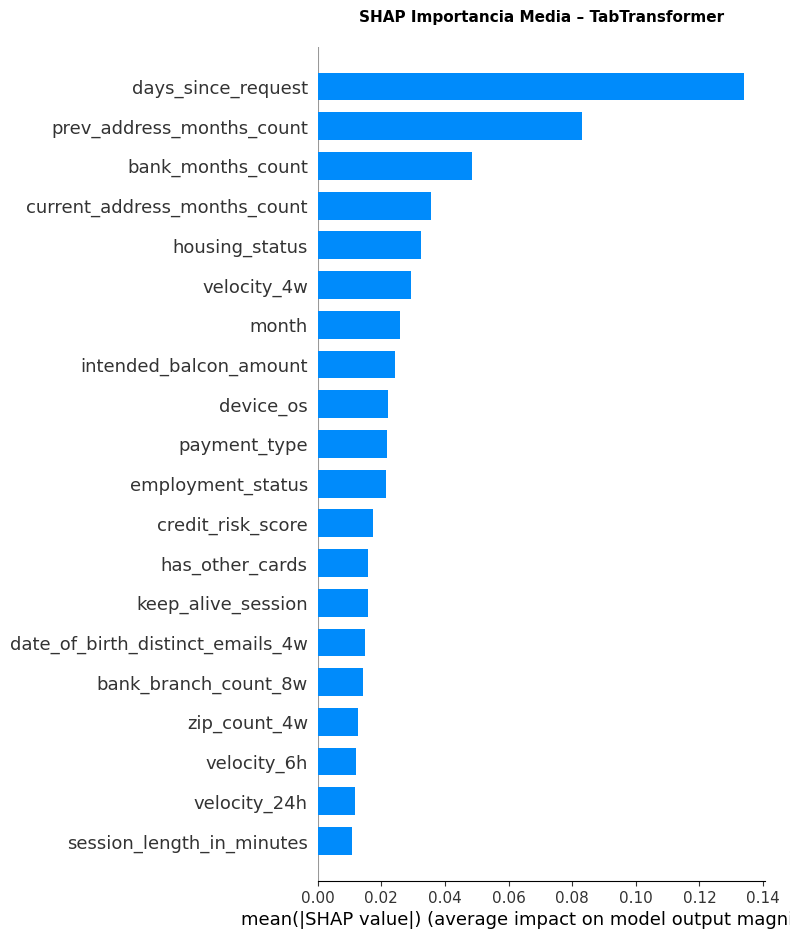

  ✔ SHAP global guardado: TabTransformer

  Calculando SHAP local: TabTransformer


  0%|          | 0/3 [00:00<?, ?it/s]

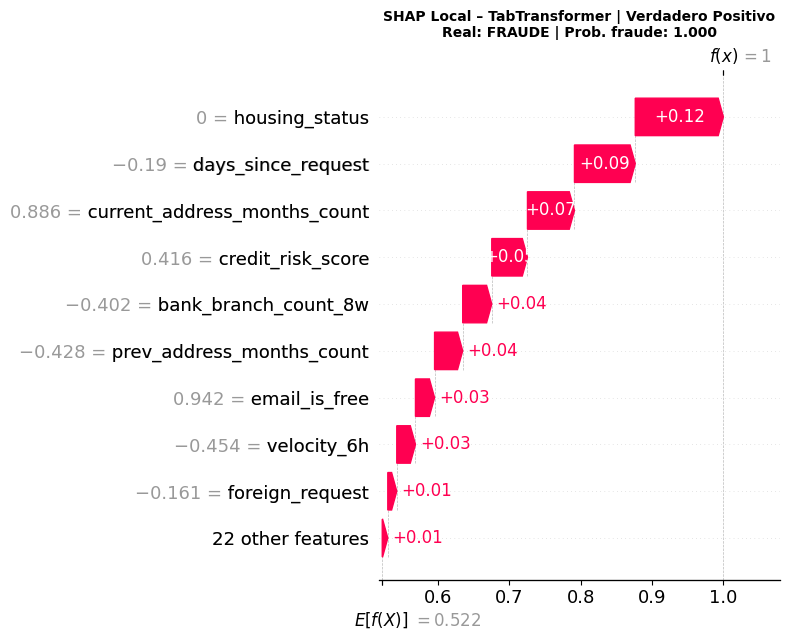

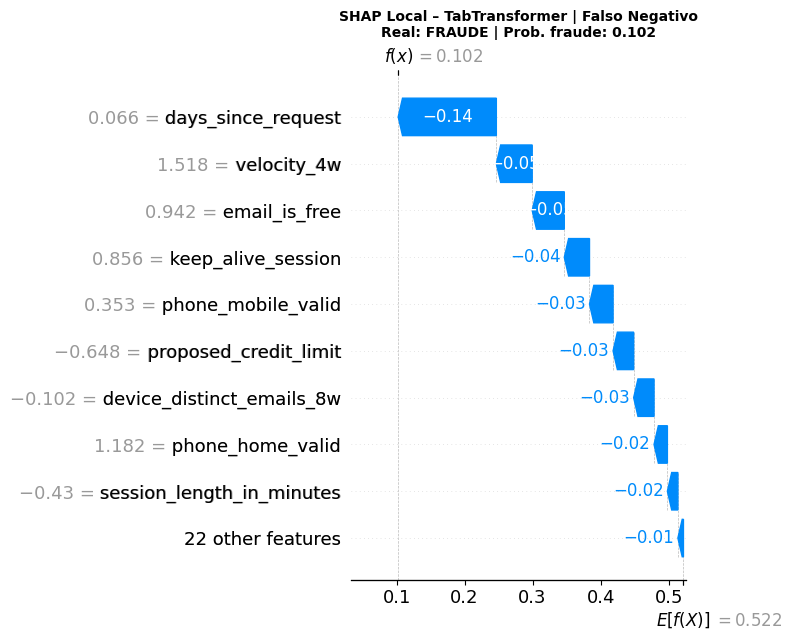

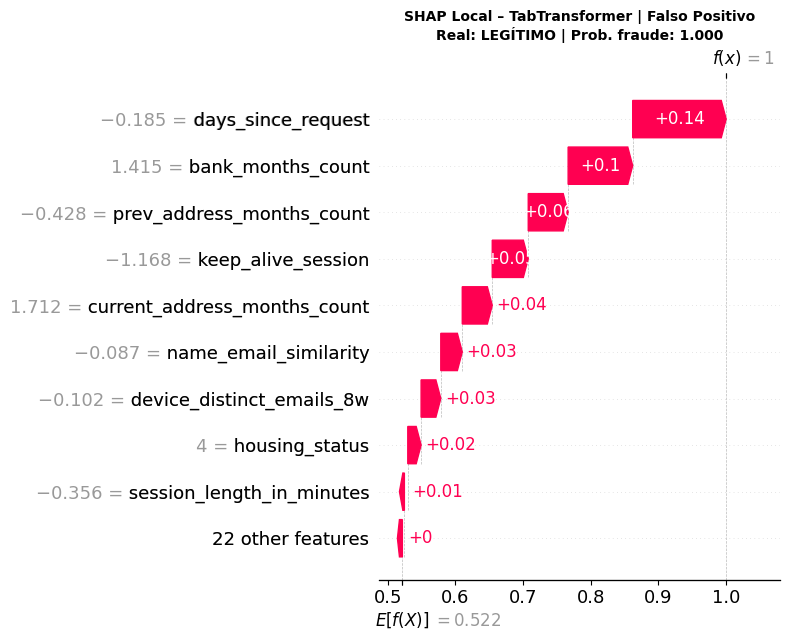

  ✔ SHAP local guardado: TabTransformer

  Calculando LIME local: TabTransformer


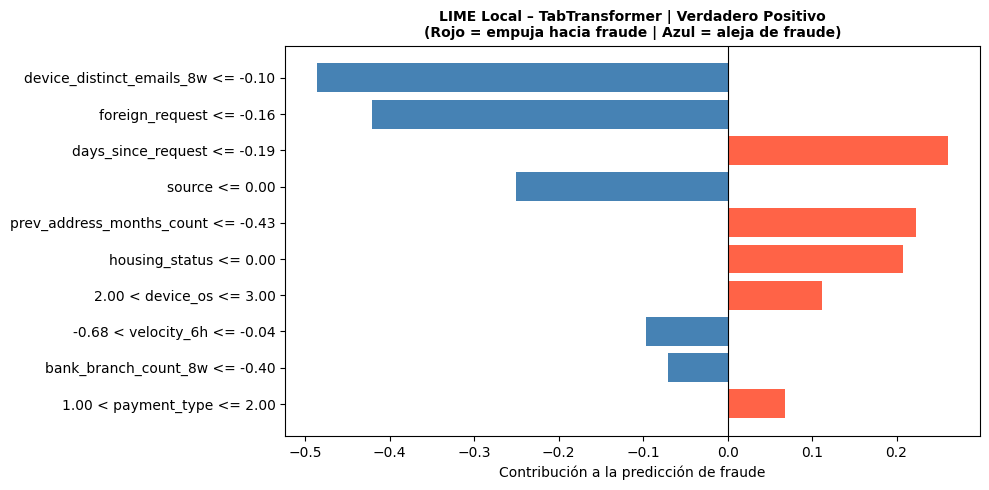

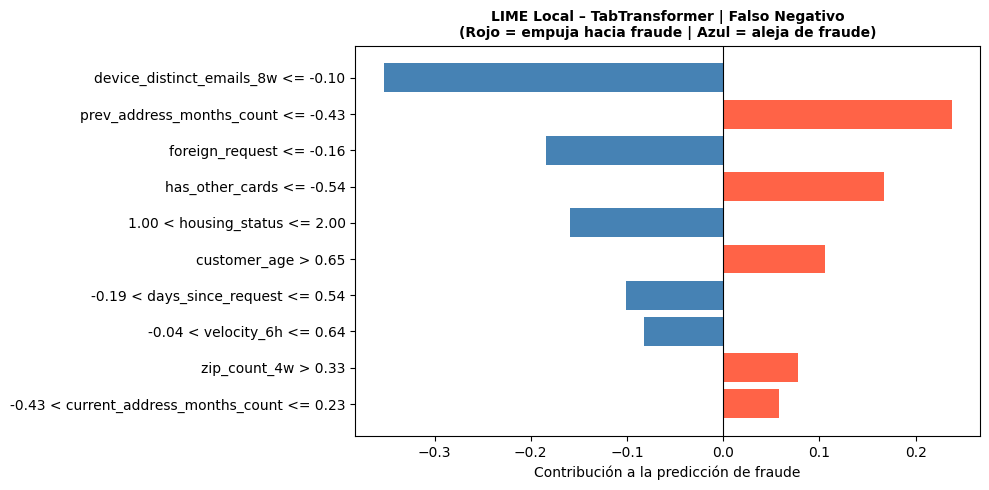

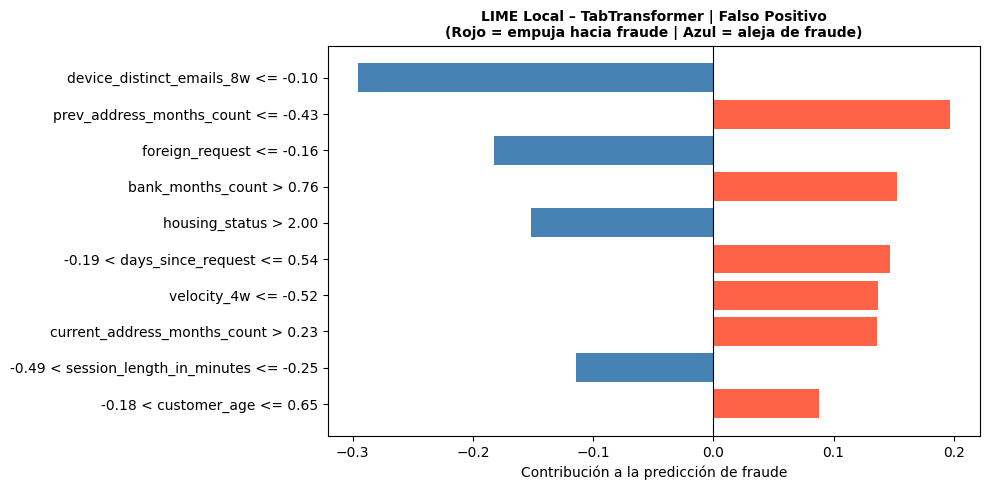

  ✔ LIME local guardado: TabTransformer

Análisis XAI completado para los modelos de Deep Learning.


In [82]:
# =============================================================================
# Loop XAI para modelos de Deep Learning
# =============================================================================

modelos_dl = {
    'MLP':            mlp_wrapped,
    'TabTransformer': tab_wrapped
}

print("\n" + "=" * 60)
print("ANÁLISIS XAI – MODELOS DE DEEP LEARNING")
print("=" * 60)

for nombre, wrapper in modelos_dl.items():
    print(f"\n{'='*60}")
    print(f"MODELO: {nombre.upper()}")
    print(f"{'='*60}")

    explainer, sv, muestra_dl = shap_global_dl(nombre, wrapper)
    resumen_importancias[nombre] = sv

    shap_local_dl(nombre, wrapper, explainer)
    lime_local_dl(nombre, wrapper)

print("\nAnálisis XAI completado para los modelos de Deep Learning.")

## Tablas comparativas SHAP GLOBAL, LOCAL Y LIME LOCAL

In [83]:
# -----------------------------------------------------------------------------
# TABLA 1 — SHAP GLOBAL: Top 10 variables por modelo
# -----------------------------------------------------------------------------
def normalizar_sv(sv):
    if isinstance(sv, list):
        return sv[1]
    elif isinstance(sv, np.ndarray) and sv.ndim == 3:
        return sv[:, :, 1]
    return sv

tabla_global = {}
for nombre, sv in resumen_importancias.items():
    sv_proc = normalizar_sv(sv)
    imp = np.abs(sv_proc).mean(axis=0)
    top10 = pd.Series(imp, index=feature_names).sort_values(ascending=False).head(10)
    tabla_global[nombre] = [f"{var} ({val:.4f})" for var, val in top10.items()]

df_global = pd.DataFrame(tabla_global, index=[f"Top {i+1}" for i in range(10)])
print("=" * 70)
print("TABLA 1 — SHAP GLOBAL: Top 10 variables por modelo")
print("=" * 70)
print(df_global.to_string())


TABLA 1 — SHAP GLOBAL: Top 10 variables por modelo
                          Regresión Logística                      Arbol de Decisión                          Random Forest                                XGBoost                               LightGBM                                        MLP                         TabTransformer
Top 1                 housing_status (0.7801)                housing_status (0.2248)                housing_status (0.1117)            days_since_request (2.3278)            days_since_request (1.5319)                days_since_request (0.1325)            days_since_request (0.1338)
Top 2   current_address_months_count (0.6841)     prev_address_months_count (0.1791)            days_since_request (0.1097)     prev_address_months_count (1.4288)     prev_address_months_count (1.3369)         prev_address_months_count (0.0818)     prev_address_months_count (0.0830)
Top 3                      device_os (0.5849)            days_since_request (0.1096)     prev_add

In [84]:
# -----------------------------------------------------------------------------
# TABLA 2 — SHAP LOCAL: Top 3 variables por caso (VP/FN/FP) por modelo
# -----------------------------------------------------------------------------
# Recalcula SHAP local solo para los 3 casos VP, FN, FP

modelos_arbol = {'Arbol de Decisión', 'Random Forest', 'XGBoost', 'LightGBM'}
local_instances = X_test_enc.iloc[indices_casos]

tabla_local_shap = {}

# Clásicos
for nombre, modelo in modelos_entrenados.items():
    if nombre in modelos_arbol:
        explainer = shap.TreeExplainer(modelo)
        sv_local = explainer.shap_values(local_instances)
    else:
        explainer = shap.LinearExplainer(modelo, X_train_bal)
        sv_local = explainer.shap_values(local_instances)
    sv_local = normalizar_sv(sv_local)

    for k, (nombre_caso, idx) in enumerate(casos.items()):
        if idx is None:
            continue
        contrib = pd.Series(sv_local[k], index=feature_names)
        top3 = contrib.abs().sort_values(ascending=False).head(3).index.tolist()
        top3_str = [f"{var} ({contrib[var]:+.3f})" for var in top3]
        tabla_local_shap.setdefault(nombre_caso, {})[nombre] = " | ".join(top3_str)

# Modelos DL — usar el explainer del wrapper
for nombre, wrapper in modelos_dl.items():
    background = shap.sample(X_train_bal, 30, random_state=42)
    def predict_fn(X, w=wrapper):
        return w.predict_proba(X)[:, 1]
    explainer = shap.KernelExplainer(predict_fn, background)
    sv_local = explainer.shap_values(local_instances, nsamples=80, silent=True)
    sv_local = normalizar_sv(sv_local)

    for k, (nombre_caso, idx) in enumerate(casos.items()):
        if idx is None:
            continue
        contrib = pd.Series(sv_local[k], index=feature_names)
        top3 = contrib.abs().sort_values(ascending=False).head(3).index.tolist()
        top3_str = [f"{var} ({contrib[var]:+.3f})" for var in top3]
        tabla_local_shap.setdefault(nombre_caso, {})[nombre] = " | ".join(top3_str)

print("\n" + "=" * 70)
print("TABLA 2 — SHAP LOCAL: Top 3 variables por caso y modelo")
print("=" * 70)
df_local_shap = pd.DataFrame(tabla_local_shap)
print(df_local_shap.to_string())


TABLA 2 — SHAP LOCAL: Top 3 variables por caso y modelo
                                                                                                Verdadero Positivo                                                                           Falso Negativo                                                                                            Falso Positivo
Regresión Logística   housing_status (+1.041) | current_address_months_count (+0.957) | bank_months_count (-0.519)                 zip_count_4w (+1.524) | device_os (-1.107) | keep_alive_session (-0.677)              housing_status (-1.977) | current_address_months_count (+1.694) | bank_months_count (+0.929)
Arbol de Decisión       housing_status (+0.347) | prev_address_months_count (+0.085) | days_since_request (+0.069)        housing_status (-0.242) | prev_address_months_count (+0.145) | device_os (-0.105)                         housing_status (-0.240) | prev_address_months_count (+0.149) | device_os (-0.106)
Random Forest

In [85]:
# -----------------------------------------------------------------------------
# TABLA 3 — LIME LOCAL: Top 3 variables por caso (VP/FN/FP) por modelo
# -----------------------------------------------------------------------------
tabla_local_lime = {}

# Función auxiliar que extrae top 3 con LIME para cualquier modelo
def extraer_top3_lime(predecir_fn, idx):
    exp = explainer_lime.explain_instance(
        data_row=X_test_enc.iloc[idx].values,
        predict_fn=predecir_fn,
        num_features=10,
        num_samples=300
    )
    pesos = exp.as_list(label=1)
    pesos_ordenados = sorted(pesos, key=lambda x: abs(x[1]), reverse=True)[:3]
    return " | ".join([f"{var} ({val:+.3f})" for var, val in pesos_ordenados])

# Clásicos
for nombre, modelo in modelos_entrenados.items():
    def predecir(X, m=modelo):
        return m.predict_proba(pd.DataFrame(X, columns=feature_names))

    for nombre_caso, idx in casos.items():
        if idx is None:
            continue
        tabla_local_lime.setdefault(nombre_caso, {})[nombre] = extraer_top3_lime(predecir, idx)

# Modelos DL
for nombre, wrapper in modelos_dl.items():
    def predecir(X, w=wrapper):
        return w.predict_proba(X)

    for nombre_caso, idx in casos.items():
        if idx is None:
            continue
        tabla_local_lime.setdefault(nombre_caso, {})[nombre] = extraer_top3_lime(predecir, idx)

print("\n" + "=" * 70)
print("TABLA 3 — LIME LOCAL: Top 3 variables por caso y modelo")
print("=" * 70)
df_local_lime = pd.DataFrame(tabla_local_lime)
print(df_local_lime.to_string())


TABLA 3 — LIME LOCAL: Top 3 variables por caso y modelo
                                                                                                                               Verdadero Positivo                                                                                                                         Falso Negativo                                                                                                                    Falso Positivo
Regresión Logística            foreign_request <= -0.16 (-0.286) | current_address_months_count > 0.23 (+0.241) | housing_status <= 0.00 (+0.221)                   foreign_request <= -0.16 (-0.488) | device_distinct_emails_8w <= -0.10 (-0.219) | employment_status <= 0.00 (+0.208)    current_address_months_count > 0.23 (+0.266) | device_distinct_emails_8w <= -0.10 (-0.264) | foreign_request <= -0.16 (-0.235)
Arbol de Decisión               housing_status <= 0.00 (+0.558) | device_distinct_emails_8w <= -0.10 (-0.491) | 2.00 < de

## SHAP Dependence — Variación del impacto según el valor

El **dependence plot** muestra cómo cambia el valor SHAP de una variable (eje Y) según el valor real que toma esa variable (eje X). Permite ver:

- **Umbrales**: a partir de qué valor la variable empuja hacia fraude
- **No-linealidades**: si la relación es lineal o tiene saltos
- **Diferencias entre categorías** (en variables como housing_status)

Se analizan **6 variables** clave (3 demográficas + 3 más importantes globalmente) para los 7 modelos.

Variables a analizar: ['customer_age', 'employment_status', 'housing_status', 'current_address_months_count', 'prev_address_months_count']


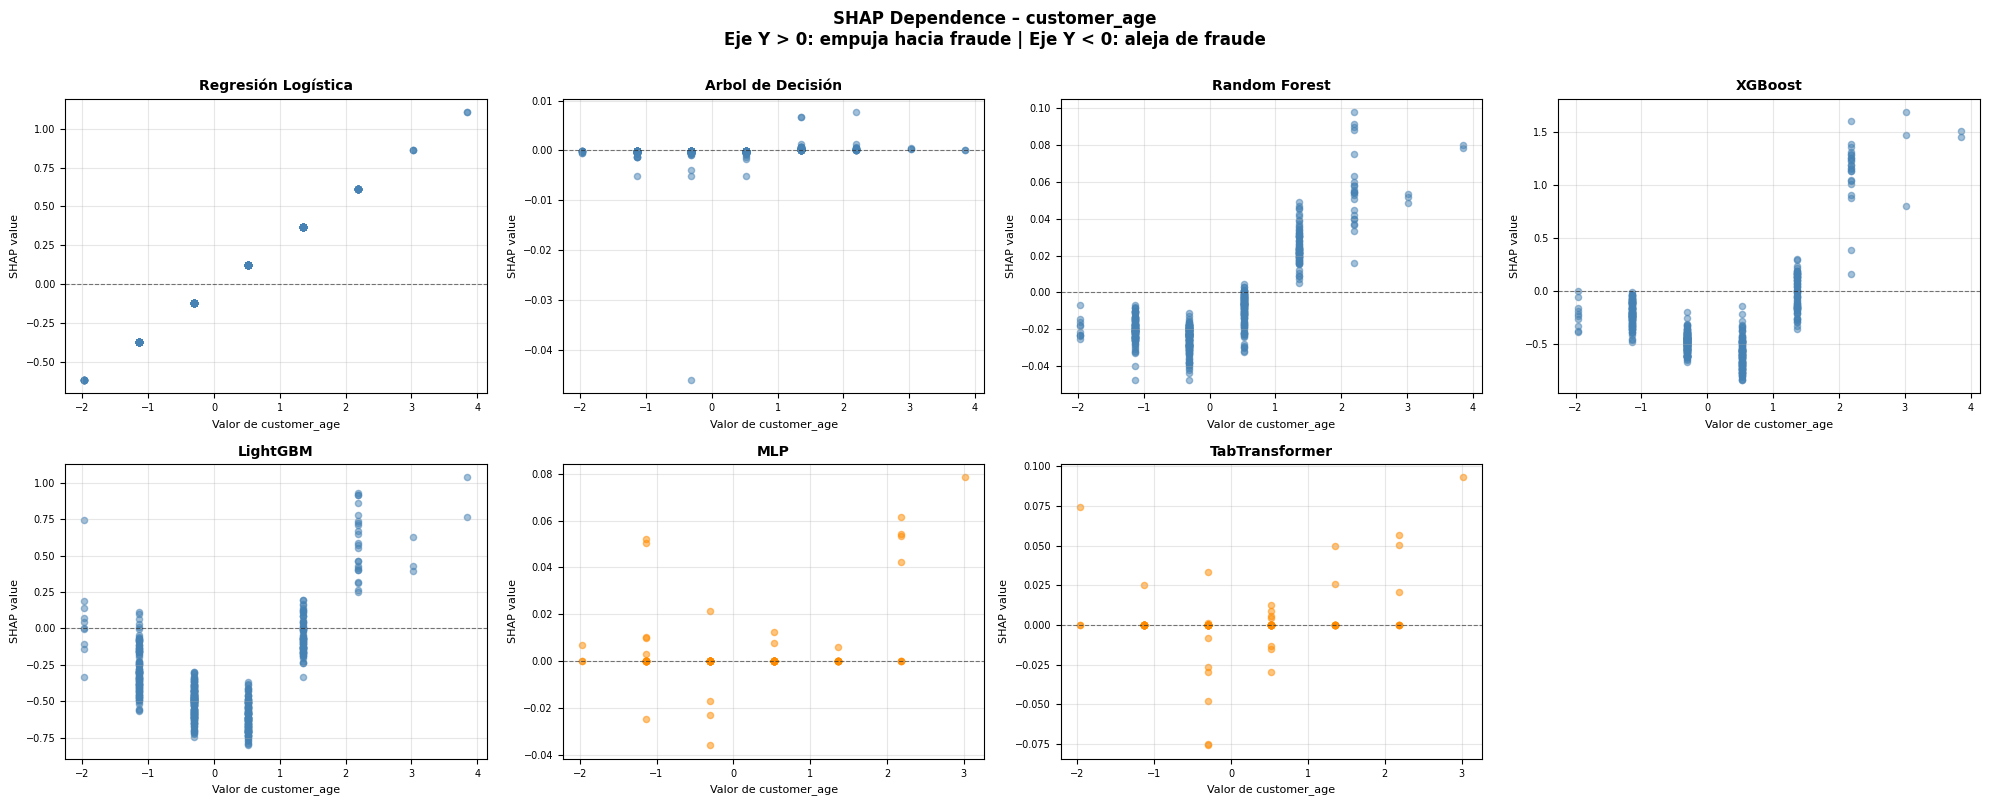

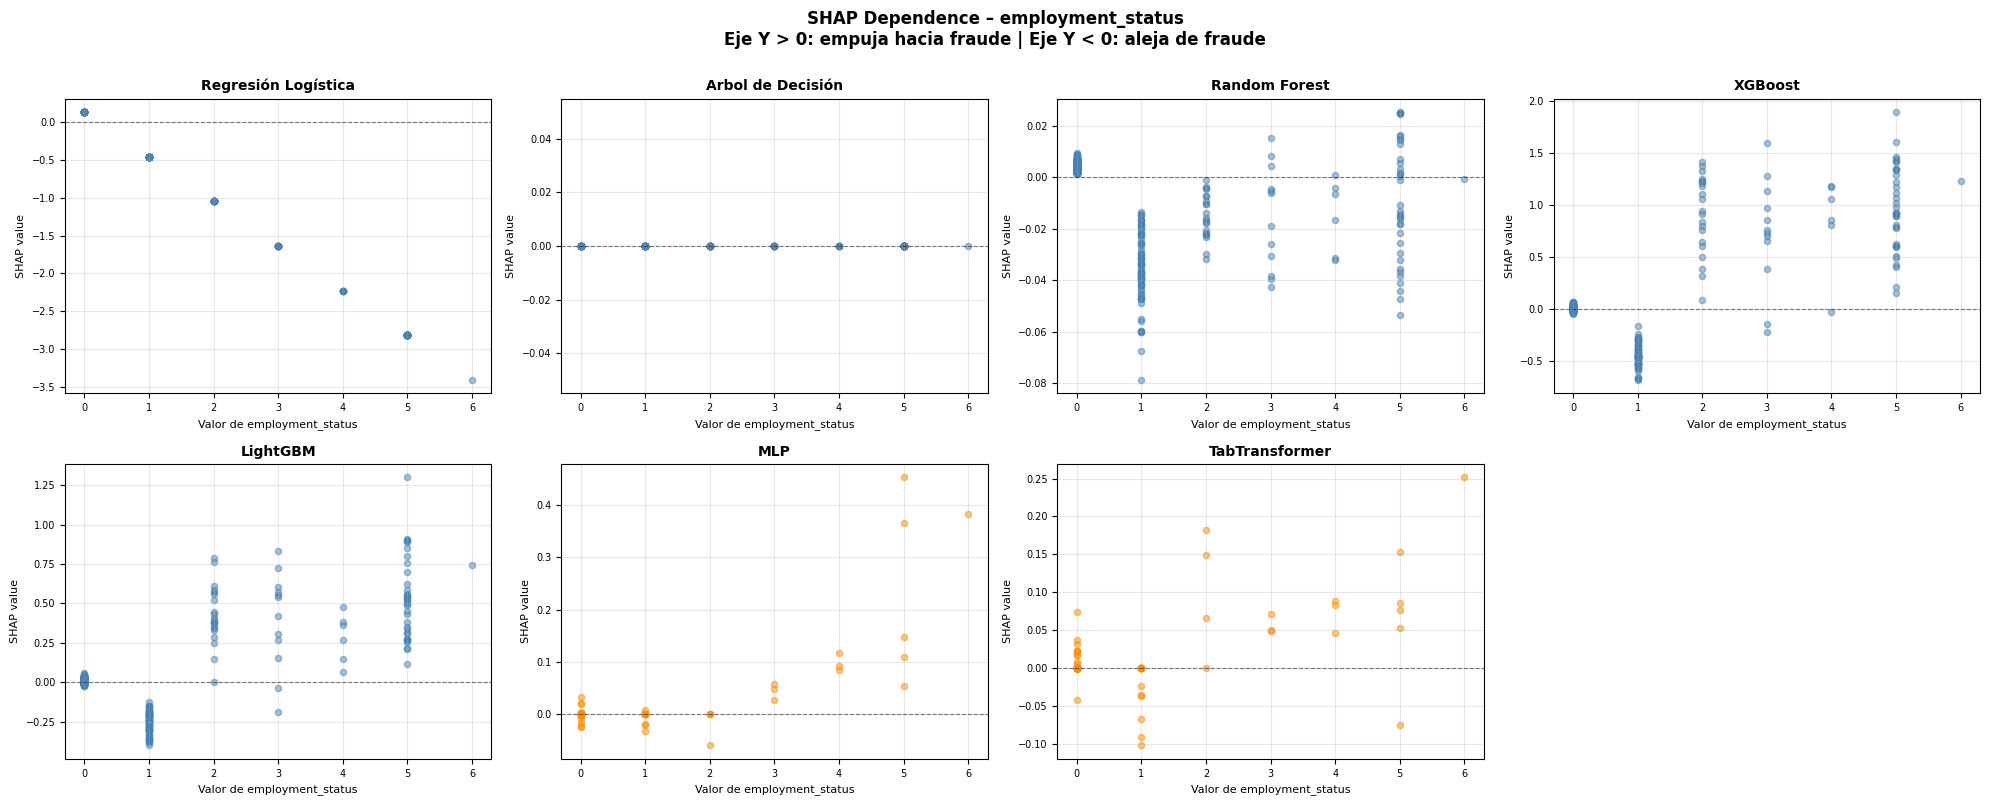

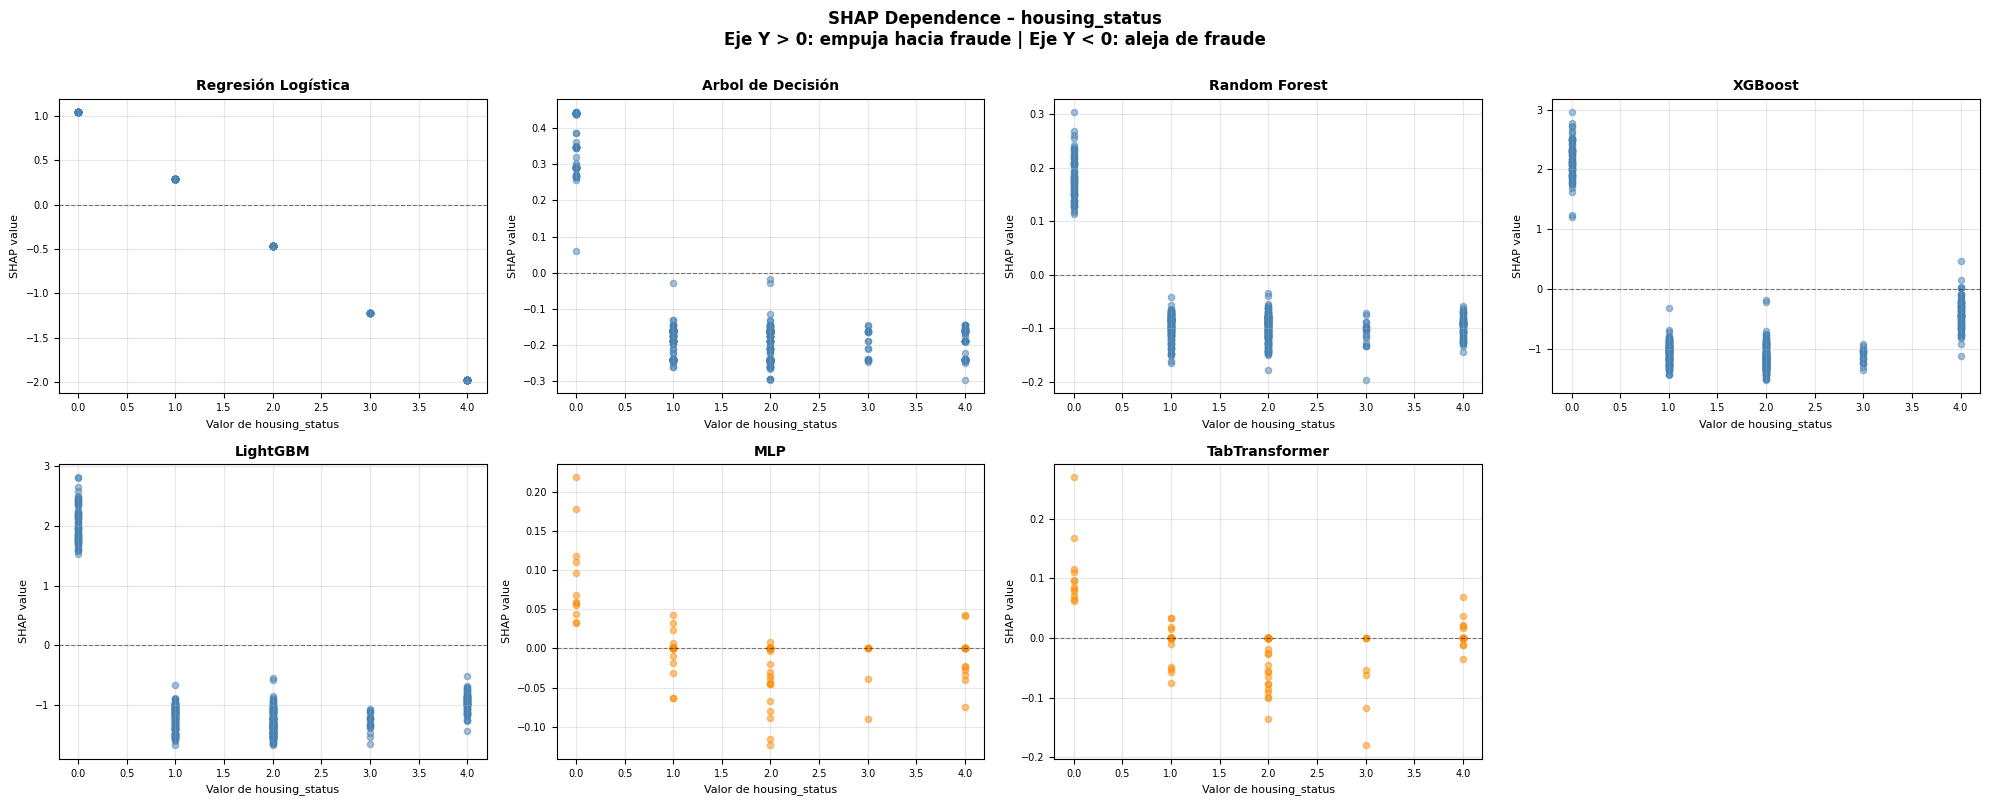

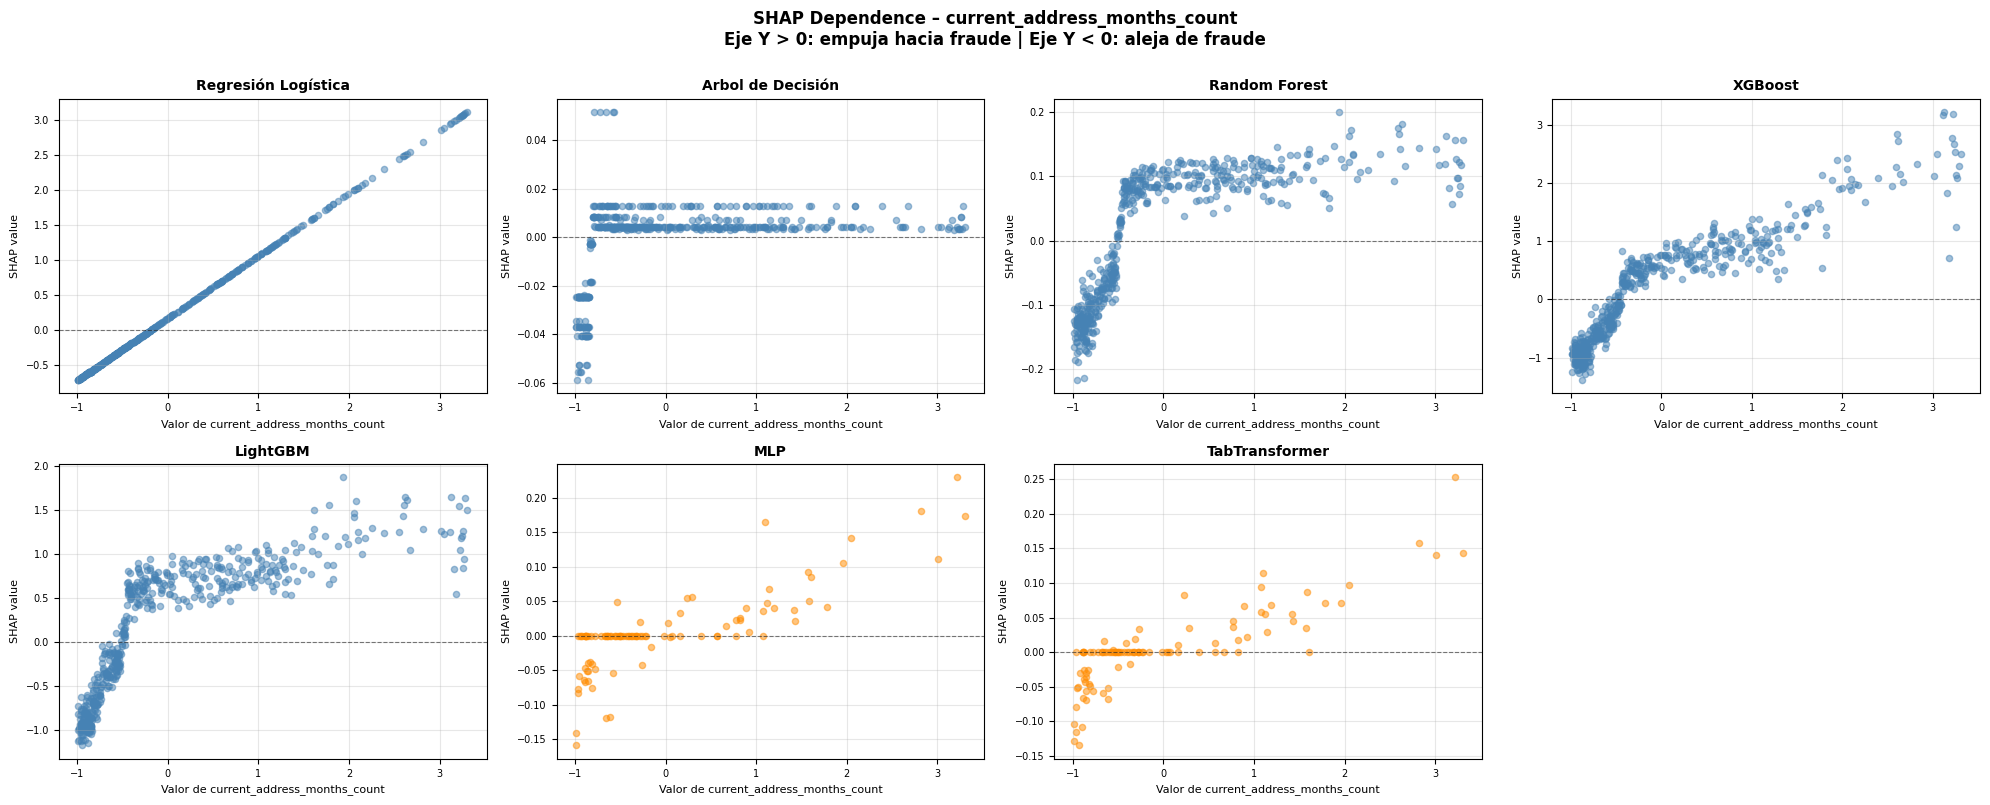

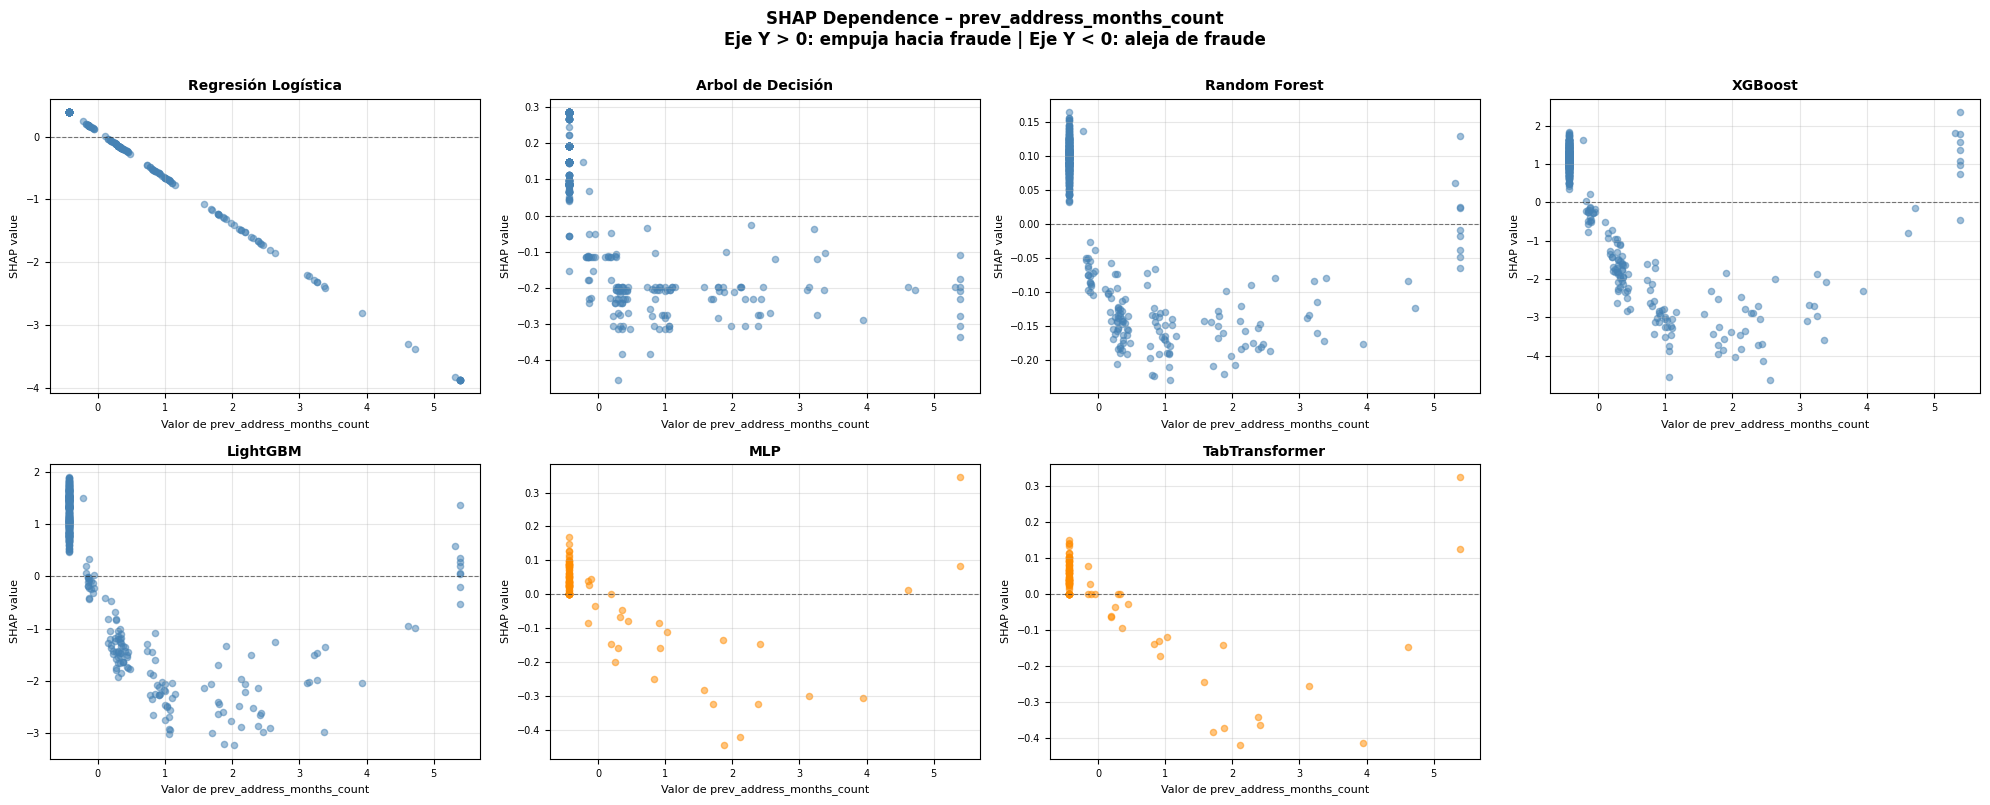


TABLA RESUMEN — SHAP medio por rango de valor
(Positivo = empuja a fraude | Negativo = aleja de fraude)


Variable: customer_age
----------------------------------------------------------------------
                    Valor bajo (≤-0.31) Valor medio Valor alto (>0.52)
Regresión Logística             -0.2430     +0.1210            +0.4517
Arbol de Decisión               -0.0004     -0.0003            +0.0005
Random Forest                   -0.0228     -0.0094            +0.0338
XGBoost                         -0.3603     -0.5914            +0.3034
LightGBM                        -0.3962     -0.6039            +0.1191
MLP                             +0.0010     +0.0008            +0.0156
TabTransformer                  -0.0024     -0.0010            +0.0156

Variable: employment_status
----------------------------------------------------------------------
                    Valor bajo (≤0.00) Valor medio Valor alto (>0.00)
Regresión Logística            +0.1297        +nan           

In [89]:
# =============================================================================
# SHAP DEPENDENCE PLOTS — variación del impacto según el valor
# =============================================================================


# Selección de variables a analizar
# -----------------------------------------------------------------------------
# Variables demográficas (las usadas en sesgo)
vars_demograficas = ['customer_age', 'employment_status', 'housing_status']

# Top 3 globales: las que aparecen más veces en el top 5 de cada modelo
contador_top = {}
for nombre, sv in resumen_importancias.items():
    sv_proc = normalizar_sv(sv)
    imp = np.abs(sv_proc).mean(axis=0)
    top5 = pd.Series(imp, index=feature_names).sort_values(ascending=False).head(5).index
    for v in top5:
        contador_top[v] = contador_top.get(v, 0) + 1

top3_globales = sorted(contador_top.items(), key=lambda x: x[1], reverse=True)[:3]
top3_globales = [v for v, _ in top3_globales]

# Quitar duplicados conservando orden
vars_analizar = vars_demograficas + [v for v in top3_globales if v not in vars_demograficas]
vars_analizar = vars_analizar[:6]
print(f"Variables a analizar: {vars_analizar}")



# Recolectar valores SHAP y valores reales para cada modelo
# -----------------------------------------------------------------------------
# Para clásicos: usamos resumen_importancias (ya calculado) + muestra_shap
# Para DL: usamos resumen_importancias (ya calculado) + muestra de 100 casos

# Reconstruir las muestras X usadas en cada análisis SHAP global
muestras_shap_por_modelo = {}
for nombre in resumen_importancias.keys():
    if nombre in ['MLP', 'TabTransformer']:
        # En el loop DL usaste 100 casos
        muestras_shap_por_modelo[nombre] = X_test_enc.sample(n=100, random_state=42)
    else:
        # En el loop clásico usaste muestra_shap (500 casos)
        muestras_shap_por_modelo[nombre] = muestra_shap



# Gráfico de dispersión: eje X = valor de la variable, eje Y = SHAP value
# -----------------------------------------------------------------------------
import matplotlib.pyplot as plt

for var in vars_analizar:
    if var not in feature_names:
        print(f"  ⚠ Variable {var} no encontrada, se omite")
        continue

    idx_var = feature_names.index(var)
    n_modelos = len(resumen_importancias)
    n_cols = 4
    n_rows = int(np.ceil(n_modelos / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for i, (nombre, sv) in enumerate(resumen_importancias.items()):
        ax = axes[i]
        sv_proc = normalizar_sv(sv)
        X_muestra = muestras_shap_por_modelo[nombre]

        valores_var = X_muestra.iloc[:, idx_var].values
        shap_var = sv_proc[:, idx_var]

        color = 'darkorange' if nombre in ['MLP', 'TabTransformer'] else 'steelblue'
        ax.scatter(valores_var, shap_var, alpha=0.5, s=20, color=color)
        ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
        ax.set_title(nombre, fontsize=10, fontweight='bold')
        ax.set_xlabel(f"Valor de {var}", fontsize=8)
        ax.set_ylabel("SHAP value", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.3)

    # Apagar ejes sobrantes
    for j in range(n_modelos, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f"SHAP Dependence – {var}\n"
                 "Eje Y > 0: empuja hacia fraude | Eje Y < 0: aleja de fraude",
                 fontsize=12, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()



# TABLA RESUMEN: impacto medio de la variable en distintos rangos
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("TABLA RESUMEN — SHAP medio por rango de valor")
print("=" * 70)
print("(Positivo = empuja a fraude | Negativo = aleja de fraude)\n")

for var in vars_analizar:
    if var not in feature_names:
        continue
    idx_var = feature_names.index(var)

    fila_tabla = {}
    for nombre, sv in resumen_importancias.items():
        sv_proc = normalizar_sv(sv)
        X_muestra = muestras_shap_por_modelo[nombre]
        valores_var = X_muestra.iloc[:, idx_var].values
        shap_var = sv_proc[:, idx_var]

        # Dividir en 3 rangos: bajo (≤ p33), medio (p33-p66), alto (> p66)
        p33 = np.percentile(valores_var, 33)
        p66 = np.percentile(valores_var, 66)

        bajo  = shap_var[valores_var <= p33].mean() if (valores_var <= p33).any() else np.nan
        medio = shap_var[(valores_var > p33) & (valores_var <= p66)].mean() if ((valores_var > p33) & (valores_var <= p66)).any() else np.nan
        alto  = shap_var[valores_var > p66].mean() if (valores_var > p66).any() else np.nan

        fila_tabla[nombre] = {
            f'Valor bajo (≤{p33:.2f})': f"{bajo:+.4f}",
            f'Valor medio': f"{medio:+.4f}",
            f'Valor alto (>{p66:.2f})': f"{alto:+.4f}"
        }

    df_var = pd.DataFrame(fila_tabla).T
    print(f"\nVariable: {var}")
    print("-" * 70)
    print(df_var.to_string())

# Análsisis del Sesgo Algorítmico

¿Qué es el sesgo algorítmico?

Un modelo puede tener buen rendimiento GLOBAL pero ser INJUSTO con ciertos grupos de personas. Por ejemplo:
- Detectar fraude bien en personas jóvenes pero fallar con personas mayores
- Generar más falsas alarmas para personas desempleadas que para empleadas

Esto se llama sesgo algorítmico: el modelo trata diferente a distintos grupos demográficos sin que haya una razón técnica válida para ello.

En el sector bancario esto tiene implicaciones legales y éticas graves: un banco podría estar discriminando clientes sin saberlo, solo porque
su modelo aprendió patrones sesgados de los datos históricos.

¿Qué grupos demográficos analizamos?
- customer_age       → agrupado en rangos: Joven / Adulto / Mayor
- employment_status  → tipo de empleo del solicitante
- housing_status     → situación de vivienda del solicitante

¿Qué métricas de equidad calculamos por grupo?
- Recall (Tasa de Detección)   → ¿detecta el fraude igual en todos los grupos?
- Tasa de Falsos Positivos     → ¿genera falsas alarmas igual en todos los grupos?
- Paridad Demográfica          → ¿predice fraude con la misma frecuencia en todos?
- Igualdad de Oportunidades    → ¿el Recall es igual entre grupos? (métrica formal

## Función Global

In [91]:
indices_test = X_test_enc.index # índices del test en el df original

df_analisis = pd.DataFrame(index=indices_test) # dataframe para el análisis

# Variables demográficas originales (sin escalar ni codificar)
df_analisis['customer_age'] = df.loc[indices_test, 'customer_age']
df_analisis['employment_status'] = df.loc[indices_test, 'employment_status']
df_analisis['housing_status'] = df.loc[indices_test, 'housing_status']
df_analisis['fraud_reported'] = y_test.values # variable objetivo original

# predicciones de cada modelo clásico
for nombre, modelo in modelos_entrenados.items():
  df_analisis[f'prediccion_{nombre}'] = modelo.predict(X_test_enc)

# predicciónes de cada modelo avanzado
for nombre, modelo in modelos_dl.items():
  df_analisis[f'prediccion_{nombre}'] = modelo.predict(X_test_enc)


print("Dataframe con análisis creado:")
print(df_analisis.head())
print(f"Total filas: {len(df_analisis):,}")

Dataframe con análisis creado:
        customer_age employment_status housing_status  fraud_reported  \
871498            20                CA             BB               0   
637378            40                CB             BE               0   
660426            20                CA             BE               0   
146887            30                CA             BB               0   
747635            10                CA             BE               0   

        prediccion_Regresión Logística  prediccion_Arbol de Decisión  \
871498                               0                             0   
637378                               1                             0   
660426                               0                             0   
146887                               0                             0   
747635                               0                             0   

        prediccion_Random Forest  prediccion_XGBoost  prediccion_LightGBM  \
871498              

In [92]:
print(df_analisis.columns.tolist())

['customer_age', 'employment_status', 'housing_status', 'fraud_reported', 'prediccion_Regresión Logística', 'prediccion_Arbol de Decisión', 'prediccion_Random Forest', 'prediccion_XGBoost', 'prediccion_LightGBM', 'prediccion_MLP', 'prediccion_TabTransformer']


In [93]:
 # Grupos de edad
def clasificar_edad(edad):
  if edad < 30:
    return 'Joven (<30)'
  elif edad < 60:
    return 'Adulto (30-59)'
  else:
    return 'Mayor (60+)'

df_analisis['grupo_edad'] = df_analisis['customer_age'].apply(clasificar_edad)

print("\nDistribución de grupos de edad:")
print(df_analisis['grupo_edad'].value_counts())
print()
print("% de fraude por grupo de edad:")
print(df_analisis.groupby('grupo_edad')['fraud_reported'].mean().round(4)*100)


Distribución de grupos de edad:
grupo_edad
Adulto (30-59)    207232
Joven (<30)        80035
Mayor (60+)        12733
Name: count, dtype: int64

% de fraude por grupo de edad:
grupo_edad
Adulto (30-59)    1.22
Joven (<30)       0.45
Mayor (60+)       3.35
Name: fraud_reported, dtype: float64


In [94]:
# Función para calcular métricas de equidad por grupo
# La función tiene como parámetros df_grupo que es el dataframe filtrado para un grupo demográfico,
# col_pred es el nombre de la columna de predicciones del modelo
# y devuelve las métricas de equidad para ese grupo analizado
def calcular_metricas_grupo(df_grupo, col_pred):
  y_real = df_grupo['fraud_reported']
  y_pred = df_grupo[col_pred]

  # Si el grupo no tiene casos de fraude, no se puede calcular algunas métricas
  if y_real.sum() == 0:
    return {
        'N total': len(df_grupo),
        'N fraudes_reales': 0,
        '% fraude real': 0.0,
        'Recall': np.nan,
        'Precision': np.nan,
        'F1-Score': np.nan,
        'Tasa FP': np.nan,
        'Tasa FN': np.nan,
        'Paridad Demográfica': round(y_pred.mean() * 100, 2)
    }
  else:
    # Recall de los fraues relaes
    ## Un recall bajo indica que el modelo falla con ese grupo
    recall = recall_score(y_real, y_pred, zero_division=0)

    # Precision de todos los que dijo "fraude" ¿cuántos fueron fraude real?
    precision = precision_score(y_real, y_pred, zero_division=0)

    # F1: equilibrio entre el Recall y Precision
    f1 = f1_score(y_real, y_pred, zero_division=0)

    # Tasa de Falsos Positivos: de todos los legítimos, ¿cuántos marcó como fraude?
    ## Una tasa FP alta indica que el modelo genera muchos falsas alarmas en el grupo
    tn, fp, fn, tp = confusion_matrix(y_real, y_pred, labels=[0, 1]).ravel()
    tasa_fp = fp / (fp + tn) if (fp + tn) > 0 else 0

    # Paridad demográfica
    ## Indica el porcentaje de casos que el modelo clasifica como fraude en ese grupo
    ## Si el porcentaje es muy diferente entre los grupos, hay discriminación en las predicciones
    paridad = y_pred.mean() * 100

    return {
        'N total': len(df_grupo),
        'N fraudes_reales': y_real.sum(),
        '% fraude real': round(y_real.mean() * 100, 2),
        'Recall': round(recall, 4),
        'Precision': round(precision, 4),
        'F1-Score': round(f1, 4),
        'Tasa FP': round(tasa_fp, 4),
        'Paridad demográfica': round(paridad, 2)
    }

Creamos una función para analizar el sesgo de una variable demográfica y calcula las métricas de equidad por grupo y modelo.

In [95]:
def analizar_sesgo(variable_demografica, nombre_variable):
    print("\n" + "="*65)
    print(f"ANÁLISIS DE SESGO POR: {nombre_variable.upper()}")
    print("="*65)

    grupos     = df_analisis[variable_demografica].unique()
    todos_modelos = list(modelos_entrenados.keys()) + list(modelos_dl.keys())
    modelos_col = [f'prediccion_{nombre}' for nombre in todos_modelos]
    nombres_mod = todos_modelos

    resultados_sesgo = []

    for grupo in sorted(grupos):
        df_grupo = df_analisis[df_analisis[variable_demografica] == grupo]

        for col_pred, nombre_mod in zip(modelos_col, nombres_mod):
            metricas = calcular_metricas_grupo(df_grupo, col_pred)
            metricas['Grupo']  = str(grupo)
            metricas['Modelo'] = nombre_mod
            resultados_sesgo.append(metricas)

    df_sesgo = pd.DataFrame(resultados_sesgo)
    df_sesgo = df_sesgo[['Modelo', 'Grupo', 'N total', 'N fraudes_reales',
                          '% fraude real', 'Recall', 'Precision',
                          'F1-Score', 'Tasa FP', 'Paridad demográfica']]

    print(df_sesgo.to_string(index=False))

    return df_sesgo


# Ejecutamos el análisis para las 3 variables demográficas
df_sesgo_edad       = analizar_sesgo('grupo_edad',        'Grupo de Edad')
df_sesgo_empleo     = analizar_sesgo('employment_status', 'Estado de Empleo')
df_sesgo_vivienda   = analizar_sesgo('housing_status',    'Estado de Vivienda')


ANÁLISIS DE SESGO POR: GRUPO DE EDAD
             Modelo          Grupo  N total  N fraudes_reales  % fraude real  Recall  Precision  F1-Score  Tasa FP  Paridad demográfica
Regresión Logística Adulto (30-59)   207232              2525           1.22  0.8325     0.0250    0.0486   0.4004                40.57
  Arbol de Decisión Adulto (30-59)   207232              2525           1.22  0.8388     0.0216    0.0422   0.4678                47.23
      Random Forest Adulto (30-59)   207232              2525           1.22  0.8554     0.0192    0.0376   0.5377                54.16
            XGBoost Adulto (30-59)   207232              2525           1.22  0.8800     0.0166    0.0325   0.6445                64.74
           LightGBM Adulto (30-59)   207232              2525           1.22  0.8808     0.0174    0.0341   0.6138                61.70
                MLP Adulto (30-59)   207232              2525           1.22  0.9208     0.0142    0.0279   0.7910                79.26
     TabTr

Gráfico de sesgo - Recall por grupo demográfico. El recall es la métrica más clave para el sesgo en detección de fraude, si el recall es muy difernete entre grupos, el modelo es injusto, protege a los unos.

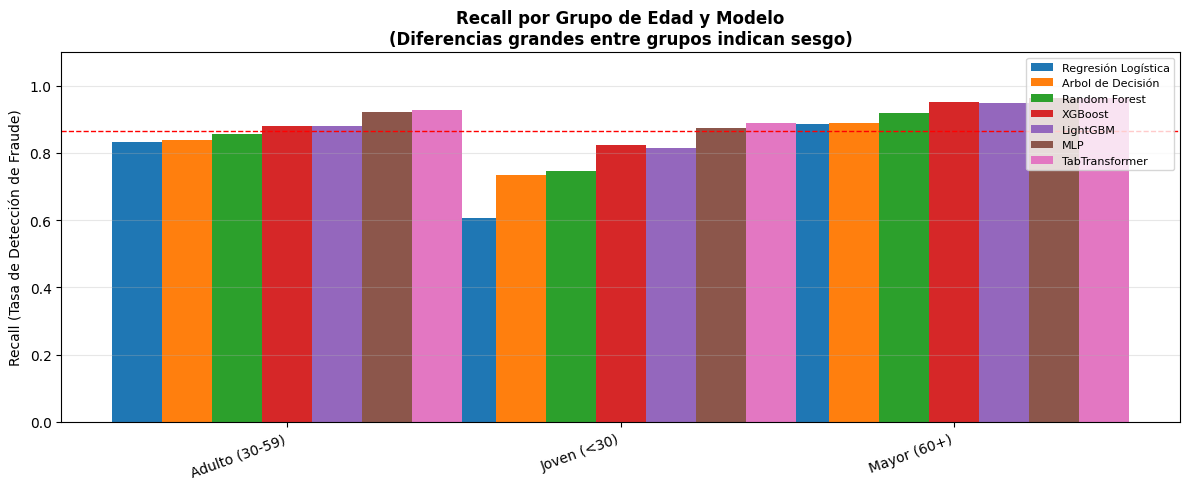

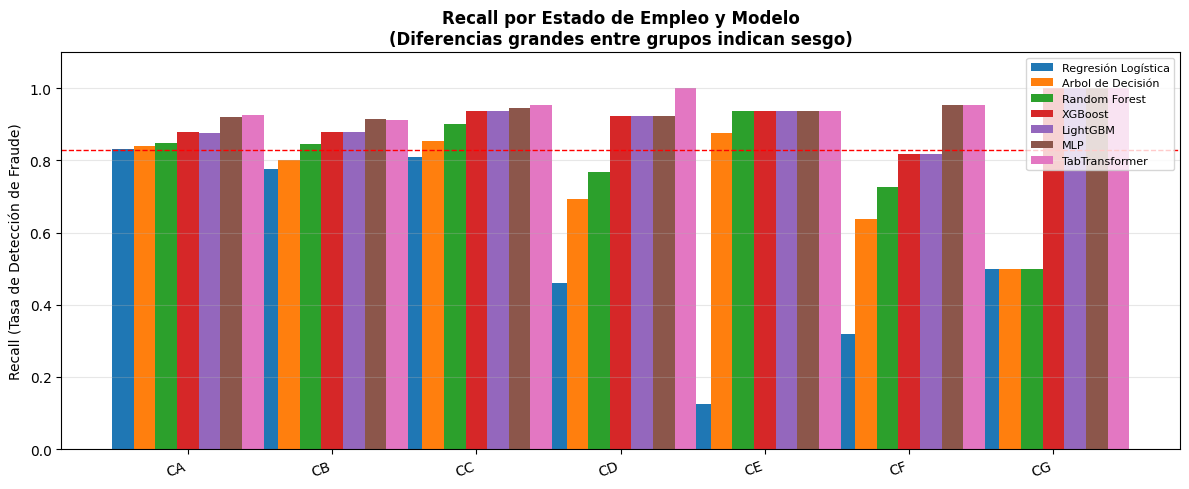

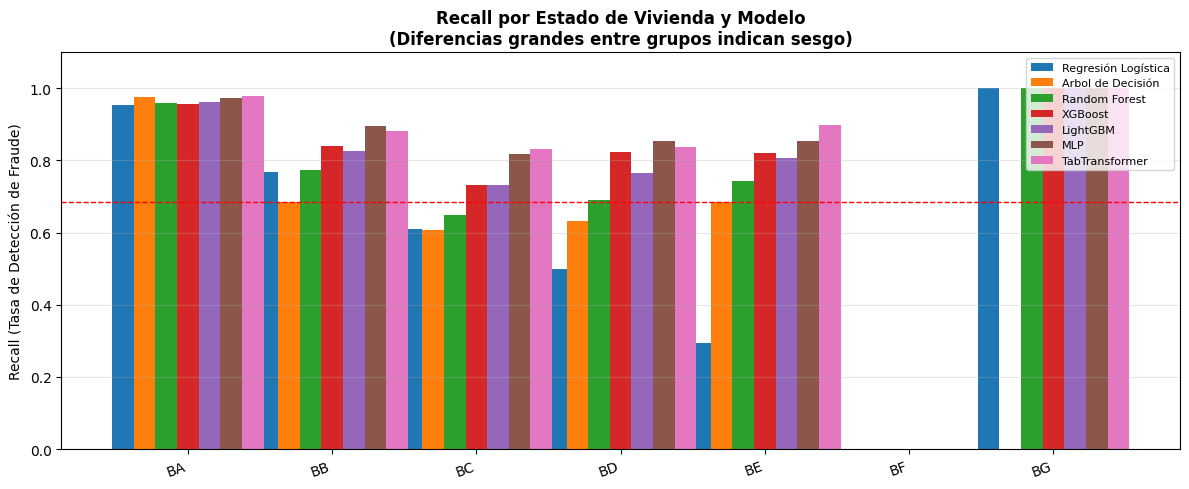

In [96]:
def graficar_recall_por_grupo(df_sesgo, variable, titulo):
    modelos_unicos = df_sesgo['Modelo'].unique()
    grupos_unicos  = df_sesgo['Grupo'].unique()

    fig, ax = plt.subplots(figsize=(12, 5))

    x      = np.arange(len(grupos_unicos))
    ancho  = 0.15   # ancho de cada barra
    offset = 0

    for i, modelo in enumerate(modelos_unicos):
        df_mod = df_sesgo[df_sesgo['Modelo'] == modelo]
        recalls = [
            df_mod[df_mod['Grupo'] == g]['Recall'].values[0]
            if len(df_mod[df_mod['Grupo'] == g]) > 0 else 0
            for g in grupos_unicos
        ]
        ax.bar(x + offset, recalls, width=ancho, label=modelo)
        offset += ancho

    ax.set_xticks(x + ancho * (len(modelos_unicos) - 1) / 2)
    ax.set_xticklabels(grupos_unicos, rotation=20, ha='right')
    ax.set_ylabel("Recall (Tasa de Detección de Fraude)")
    ax.set_ylim(0, 1.1)
    ax.set_title(f"Recall por {titulo} y Modelo\n"
                 f"(Diferencias grandes entre grupos indican sesgo)",
                 fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.axhline(y=df_sesgo['Recall'].mean(), color='red',
               linestyle='--', linewidth=1, label='Promedio global')
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

# Graficando las diferentes tasas de recall por grupo para cada variable demográfica y modelo, lo que permite visualizar si hay sesgo en la capacidad del modelo para detectar fraudes en diferentes grupos demográficos. Diferencias significativas en el recall entre grupos pueden indicar que el modelo tiene un desempeño desigual, lo que es un indicio de sesgo en las predicciones.
graficar_recall_por_grupo(df_sesgo_edad,     'edad',     'Grupo de Edad')
graficar_recall_por_grupo(df_sesgo_empleo,   'empleo',   'Estado de Empleo')
graficar_recall_por_grupo(df_sesgo_vivienda, 'vivienda', 'Estado de Vivienda')

Gráfico de Falsos positivos por grupo. La tasa FP mide cuantas falsas alarmas se genera en el modelo por grupo. Si el grupo tiene una tasa FP demasiado elevada, el modelo es sospechoso injustamente.

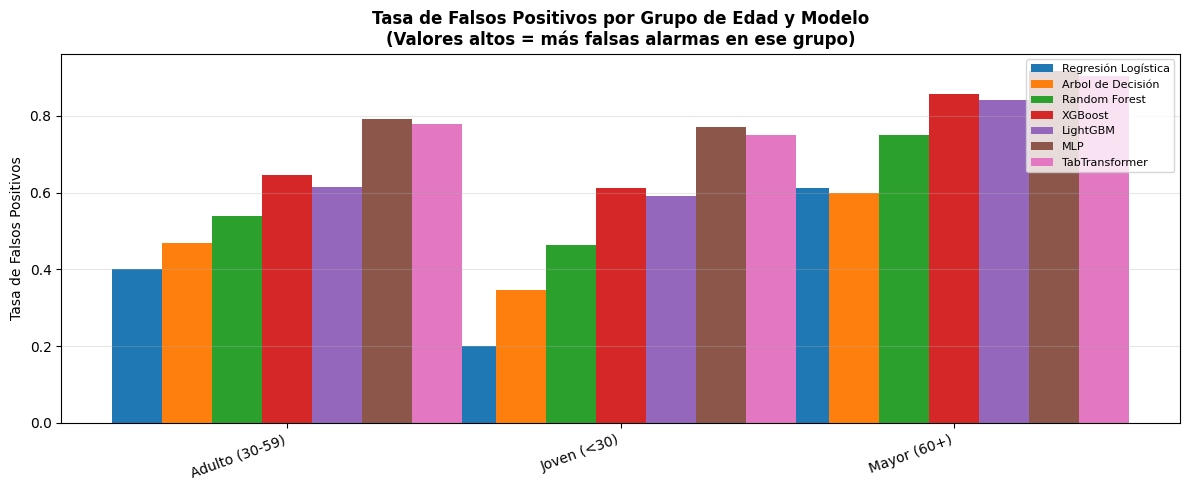

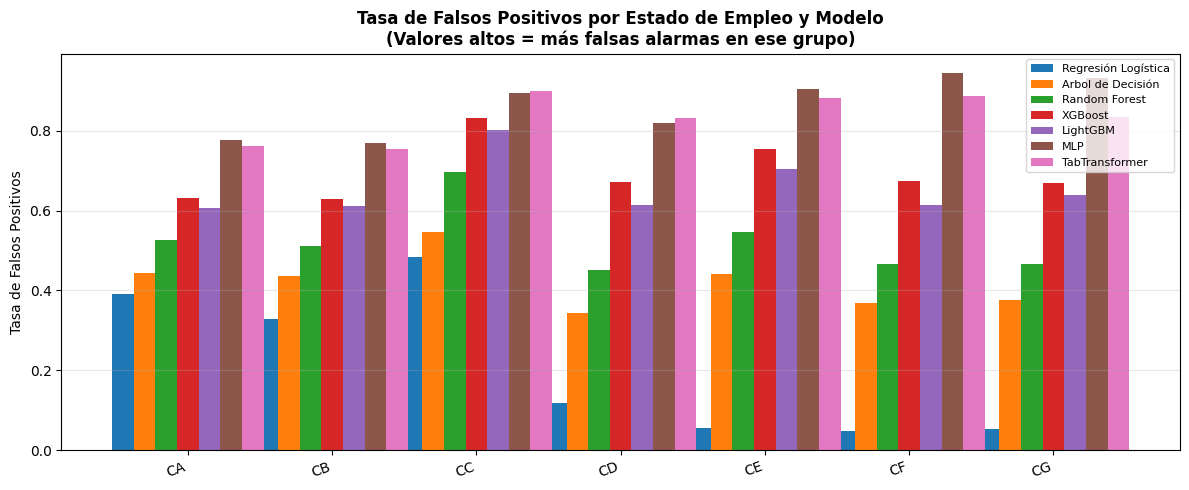

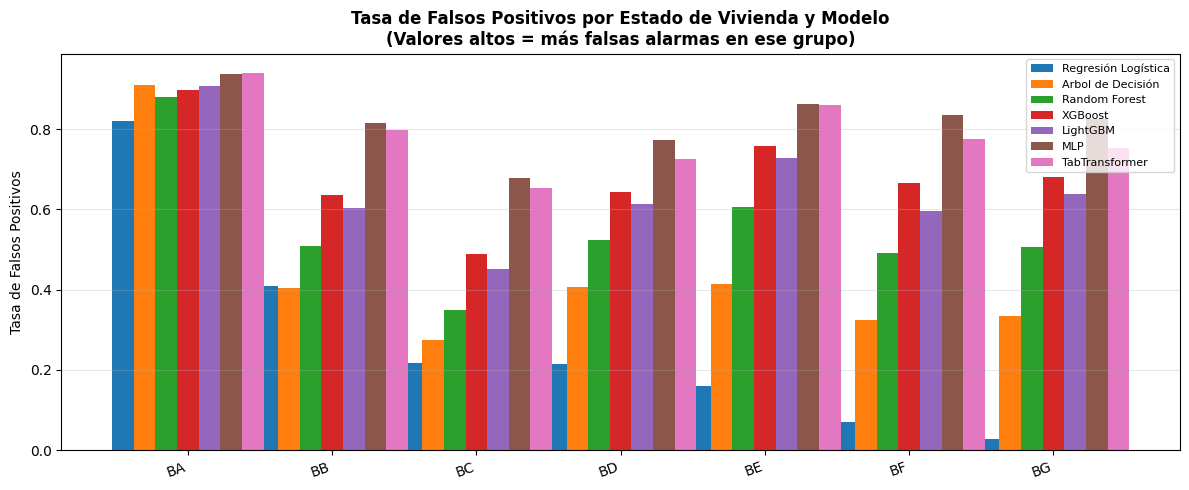

In [97]:
def graficar_fp_por_grupo(df_sesgo, variable, titulo):
    modelos_unicos = df_sesgo['Modelo'].unique()
    grupos_unicos  = df_sesgo['Grupo'].unique()

    fig, ax = plt.subplots(figsize=(12, 5))

    x      = np.arange(len(grupos_unicos))
    ancho  = 0.15
    offset = 0

    for modelo in modelos_unicos:
        df_mod  = df_sesgo[df_sesgo['Modelo'] == modelo]
        tasas_fp = [
            df_mod[df_mod['Grupo'] == g]['Tasa FP'].values[0]
            if len(df_mod[df_mod['Grupo'] == g]) > 0 else 0
            for g in grupos_unicos
        ]
        ax.bar(x + offset, tasas_fp, width=ancho, label=modelo)
        offset += ancho

    ax.set_xticks(x + ancho * (len(modelos_unicos) - 1) / 2)
    ax.set_xticklabels(grupos_unicos, rotation=20, ha='right')
    ax.set_ylabel("Tasa de Falsos Positivos")
    ax.set_title(f"Tasa de Falsos Positivos por {titulo} y Modelo\n"
                 f"(Valores altos = más falsas alarmas en ese grupo)",
                 fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'sesgo_fp_{variable}.png', dpi=150, bbox_inches='tight')
    plt.show()


graficar_fp_por_grupo(df_sesgo_edad,     'edad',     'Grupo de Edad')
graficar_fp_por_grupo(df_sesgo_empleo,   'empleo',   'Estado de Empleo')
graficar_fp_por_grupo(df_sesgo_vivienda, 'vivienda', 'Estado de Vivienda')

Métricas formales de equidad. Se calcula dos métricas formales en fairness.

1. Igualdad de oportundiades.  Diferencia entre el recall y mínimo entre grupos. Si la diferencia es menor que 0.1 entonces es equidad aceptable, si es mayor que 0.1, entonces es sesgo significativo.

2. Paridad demográfica. Diferencia entre el % de predicciones de fraude en los grupos. Si la diferencia es menor a 0.05, es equidad aceptable, caso contrario hay sesgo significativo.

In [99]:
print("\n" + "="*75)
print("MÉTRICAS FORMALES DE EQUIDAD")
print("="*75)

resultados_equidad = []

# Loop en los 7 modelos
todos_modelos = list(modelos_entrenados.keys()) + list(modelos_dl.keys())

for nombre_mod in todos_modelos:

    for var_demo, nombre_demo, df_sesgo in [
        ('grupo_edad',        'Edad',     df_sesgo_edad),
        ('employment_status', 'Empleo',   df_sesgo_empleo),
        ('housing_status',    'Vivienda', df_sesgo_vivienda)
    ]:
        df_mod = df_sesgo[df_sesgo['Modelo'] == nombre_mod].dropna(subset=['Recall'])

        if len(df_mod) < 2:
            continue

        # Igualdad de Oportunidades: diferencia entre Recall máximo y mínimo
        recall_max   = df_mod['Recall'].max()
        recall_min   = df_mod['Recall'].min()
        dif_recall   = round(recall_max - recall_min, 4)

        # Paridad Demográfica: diferencia entre % predicción fraude máximo y mínimo
        paridad_max  = df_mod['Paridad demográfica'].max()
        paridad_min  = df_mod['Paridad demográfica'].min()
        dif_paridad  = round(paridad_max - paridad_min, 4)

        resultados_equidad.append({
            'Modelo':               nombre_mod,
            'Variable':             nombre_demo,
            'Recall máx':          round(recall_max, 4),
            'Recall mín':          round(recall_min, 4),
            'Δ Recall (Igualad Op.)': dif_recall,
            'Δ Paridad Demogr.':   dif_paridad,
            'Sesgo en Recall':     'Sí' if dif_recall > 0.10 else 'No',
            'Sesgo en Paridad':    'Sí' if dif_paridad > 5.0  else 'No'
        })

df_equidad = pd.DataFrame(resultados_equidad)
print(df_equidad.to_string(index=False))


MÉTRICAS FORMALES DE EQUIDAD
             Modelo Variable  Recall máx  Recall mín  Δ Recall (Igualad Op.)  Δ Paridad Demogr. Sesgo en Recall Sesgo en Paridad
Regresión Logística     Edad      0.8850      0.6061                  0.2789              41.89              Sí               Sí
Regresión Logística   Empleo      0.8312      0.1250                  0.7062              44.22              Sí               Sí
Regresión Logística Vivienda      1.0000      0.0000                  1.0000              78.12              Sí               Sí
  Arbol de Decisión     Edad      0.8897      0.7346                  0.1551              26.22              Sí               Sí
  Arbol de Decisión   Empleo      0.8750      0.5000                  0.3750              20.82              Sí               Sí
  Arbol de Decisión Vivienda      0.9748      0.0000                  0.9748              63.51              Sí               Sí
      Random Forest     Edad      0.9178      0.7458               

Heatmap de recall por grupo y modelo. Visualizamos un resumen donde cada celda es un recall de un modelo con un grupo.
- Color rojo: recall bajo, indica que el modelo falla en ese grupo
- Color azul: el modelo detecta bien el fraude

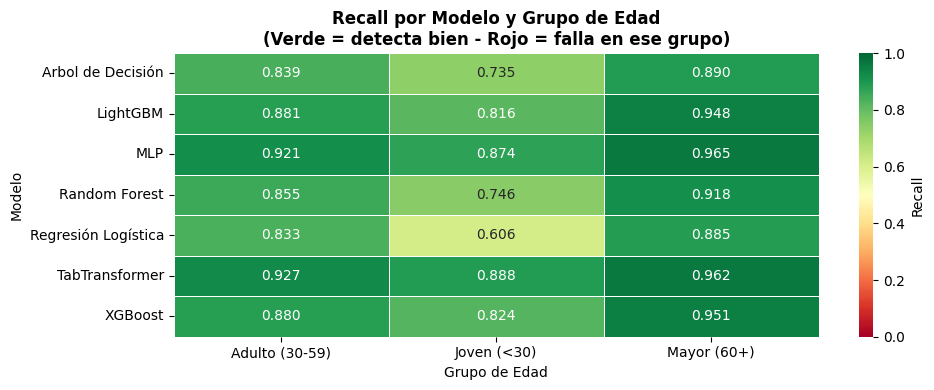

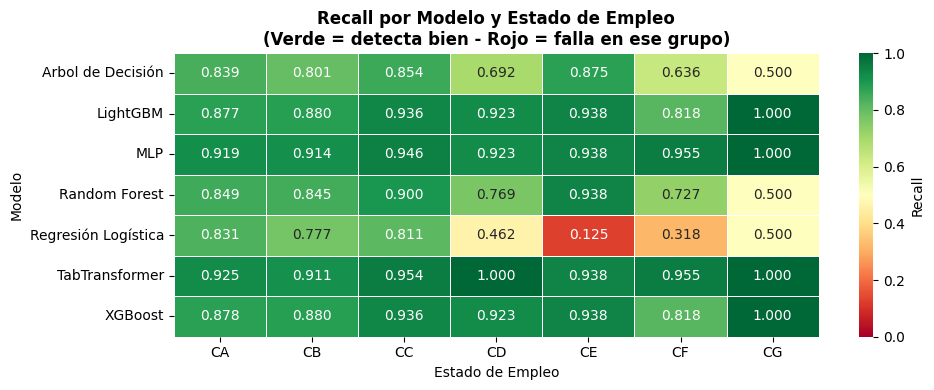

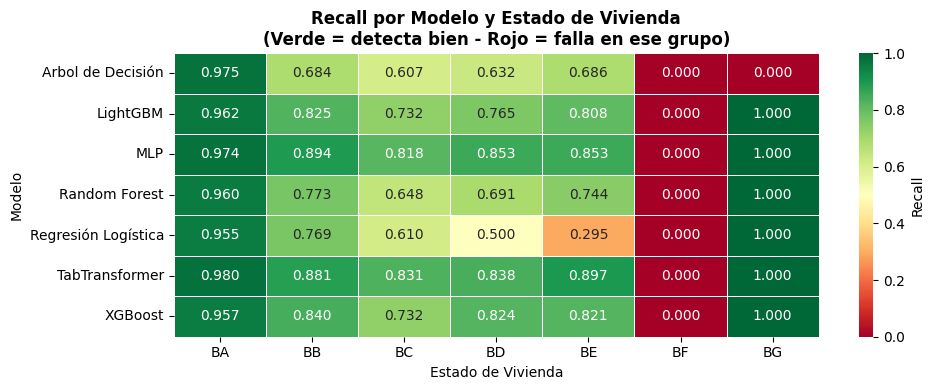

In [100]:
for df_sesgo, variable, titulo in [
    (df_sesgo_edad,     'edad',     'Grupo de Edad'),
    (df_sesgo_empleo,   'empleo',   'Estado de Empleo'),
    (df_sesgo_vivienda, 'vivienda', 'Estado de Vivienda')
]:
    pivot = df_sesgo.pivot_table(
        index='Modelo', columns='Grupo', values='Recall'
    )

    plt.figure(figsize=(10, 4))
    sns.heatmap(
        pivot,
        annot=True,        # muestra el valor numérico en cada celda
        fmt='.3f',         # formato de 3 decimales
        cmap='RdYlGn',     # rojo = bajo, amarillo = medio, verde = alto
        vmin=0, vmax=1,
        linewidths=0.5,
        cbar_kws={'label': 'Recall'}
    )
    plt.title(f"Recall por Modelo y {titulo}\n"
              f"(Verde = detecta bien - Rojo = falla en ese grupo)",
              fontweight='bold')
    plt.ylabel("Modelo")
    plt.xlabel(titulo)
    plt.tight_layout()
    plt.show()

In [104]:
# =============================================================================
# TABLA RESUMEN EJECUTIVO DE EQUIDAD
# Cruza rendimiento global (PR-AUC) con equidad por modelo
# =============================================================================

resumen_ejecutivo = []

todos_modelos = list(modelos_entrenados.keys()) + list(modelos_dl.keys())

for nombre_mod in todos_modelos:
    # PR-AUC del modelo
    pr_auc = df_completo[df_completo['Modelo'] == nombre_mod]['PR-AUC'].values
    pr_auc = pr_auc[0] if len(pr_auc) > 0 else np.nan

    # Variables con sesgo significativo (de la tabla df_equidad)
    df_mod_eq = df_equidad[df_equidad['Modelo'] == nombre_mod]
    n_sesgo_recall  = (df_mod_eq['Sesgo en Recall']  == 'Sí').sum()
    n_sesgo_paridad = (df_mod_eq['Sesgo en Paridad'] == 'Sí').sum()
    total_vars = len(df_mod_eq)

    # Recall mínimo entre todos los grupos de las 3 variables
    recall_mins = []
    for df_sesgo in [df_sesgo_edad, df_sesgo_empleo, df_sesgo_vivienda]:
        r = df_sesgo[df_sesgo['Modelo'] == nombre_mod]['Recall'].dropna()
        if len(r) > 0:
            recall_mins.append(r.min())
    recall_min_global = min(recall_mins) if recall_mins else np.nan

    resumen_ejecutivo.append({
        'Modelo': nombre_mod,
        'PR-AUC': round(pr_auc, 4),
        'Vars. con sesgo Recall':  f"{n_sesgo_recall}/{total_vars}",
        'Vars. con sesgo Paridad': f"{n_sesgo_paridad}/{total_vars}",
        'Recall mín. global': round(recall_min_global, 4)
    })

df_resumen_eq = pd.DataFrame(resumen_ejecutivo)
df_resumen_eq = df_resumen_eq.sort_values('PR-AUC', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("RESUMEN EJECUTIVO — RENDIMIENTO vs EQUIDAD")
print("="*80)
print(df_resumen_eq.to_string(index=False))
print("\nLectura:")
print("  - Mejor modelo en rendimiento: primera fila")
print("  - 'Vars. con sesgo' = nº de las 3 variables demográficas con sesgo significativo")
print("  - 'Recall mín. global' = peor rendimiento del modelo en cualquier subgrupo")


RESUMEN EJECUTIVO — RENDIMIENTO vs EQUIDAD
             Modelo  PR-AUC Vars. con sesgo Recall Vars. con sesgo Paridad  Recall mín. global
Regresión Logística  0.0647                    3/3                     3/3                 0.0
      Random Forest  0.0478                    3/3                     3/3                 0.0
           LightGBM  0.0421                    3/3                     3/3                 0.0
            XGBoost  0.0322                    3/3                     3/3                 0.0
  Arbol de Decisión  0.0151                    3/3                     3/3                 0.0
     TabTransformer  0.0151                    1/3                     3/3                 0.0
                MLP  0.0139                    1/3                     3/3                 0.0

Lectura:
  - Mejor modelo en rendimiento: primera fila
  - 'Vars. con sesgo' = nº de las 3 variables demográficas con sesgo significativo
  - 'Recall mín. global' = peor rendimiento del modelo en